# Pipeline unificado de Canastas Básicas Alimentarias

Este notebook primero unifica las CBA y después carga la composición nutricional del INCAP. Las clases y reglas viven en `src/canasta_inteligente`; aquí solo se orquesta e inspecciona el proceso.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from canasta_inteligente.application.cba_pipeline import (
    build_cba_catalog,
    enrich_catalog_with_incap,
)

## 1. Unificar las CBA

In [2]:
catalog = build_cba_catalog(PROJECT_ROOT / 'data' / 'raw' / 'ine' / 'cba_historicos')
len(catalog)

102

In [3]:
catalog.items

[Food(id='arroz', name='ARROZ', category='CEREALES', aliases={'Arroz', 'ARROZ'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026F9B546510>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=()),
 Food(id='avena_de_toda_clase', name='AVENA DE TODA CLASE', category='CEREALES', aliases={'AVENA DE TODA CLASE', 'Avena de toda clase'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026F9B5CF4D0>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=()),
 Food(id='pan_frances', name='PAN FRANCÉS', category='CEREALES', aliases={'PAN FRANCÉS', 'Pan francés'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026F9B5CF750>, 'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC5A5D0>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBCF31D0>}, nutrition=None, nutrition

In [4]:
summary = {
    region: sum(len(food.price_timelines.get(region, ())) for food in catalog)
    for region in ('general', 'rural', 'urbana')
}
summary['general_derivados'] = sum(
    point.derived
    for food in catalog
    for point in food.price_timelines.get('general', ())
)
summary

{'general': 3978, 'rural': 1680, 'urbana': 1848, 'general_derivados': 1428}

Los puntos generales de 2017–2023 son observaciones originales. Desde 2024 se crea un punto general derivado solo si el alimento tiene observaciones rural y urbana para el mismo año y mes.

In [5]:
food_example = next(food for food in catalog if len(food.price_timelines.get('general', ())) > 75)
food_example.name, {region: len(timeline) for region, timeline in food_example.price_timelines.items()}

('PAN FRANCÉS', {'general': 103, 'rural': 28, 'urbana': 28})

# Revision manual de alimentos 

In [6]:
from canasta_inteligente.domain.food import Food

catalog_iterable = iter(catalog)
print(len(catalog))

102


## Arroz

In [7]:
food = next(catalog_iterable)
print(food.id)

arroz


In [8]:
food = catalog.get('arroz')
food.years_by_region()

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023],
 'rural': [],
 'urbana': []}

Resalta que no haya encontrado registros de arroz en años recientes. 

### Busqueda de informacion complementaria

In [9]:
for _food in catalog:
    if _food.id.startswith('arroz'):
        print(_food)

Food(id='arroz', name='ARROZ', category='CEREALES', aliases={'Arroz', 'ARROZ'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026F9B546510>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())
Food(id='arroz_corriente', name='Arroz corriente', category=None, aliases={'Arroz corriente'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC5A1B0>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBCC9BB0>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBD13EF0>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())
Food(id='arroz_precocido', name='Arroz precocido', category=None, aliases={'Arroz precocido'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC47E30>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBCF

Posibles candidatos: Arroz Corriente y Arroz precocido

In [10]:
for _food in catalog:
    if _food.id.startswith('arroz'):
        print(_food)
        print("===============")
        for region, ptf in _food.price_timelines.items(): 
            print(f"Region: {region}")
            print(ptf.avg_daily_grams())


Food(id='arroz', name='ARROZ', category='CEREALES', aliases={'Arroz', 'ARROZ'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026F9B546510>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())
Region: general
34.58001397624034
Food(id='arroz_corriente', name='Arroz corriente', category=None, aliases={'Arroz corriente'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC5A1B0>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBCC9BB0>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBD13EF0>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())
Region: rural
17.044065862103597
Region: urbana
18.53221808122289
Region: general
17.78814197166326
Food(id='arroz_precocido', name='Arroz precocido', category=None, aliases={'Arroz precocido'}, price_timelines={'rural': <canasta_inteligente.domain.p

Representa una mayor presencia en la CBA 2024-2026 el arroz corriente que el arroz precocido, aunque aun alejado de lo que representa el arroz en años anteriores respecto a la cantidad de gramos en sus respectivas canstas. 

#### Arroz - Explorarcion de datos

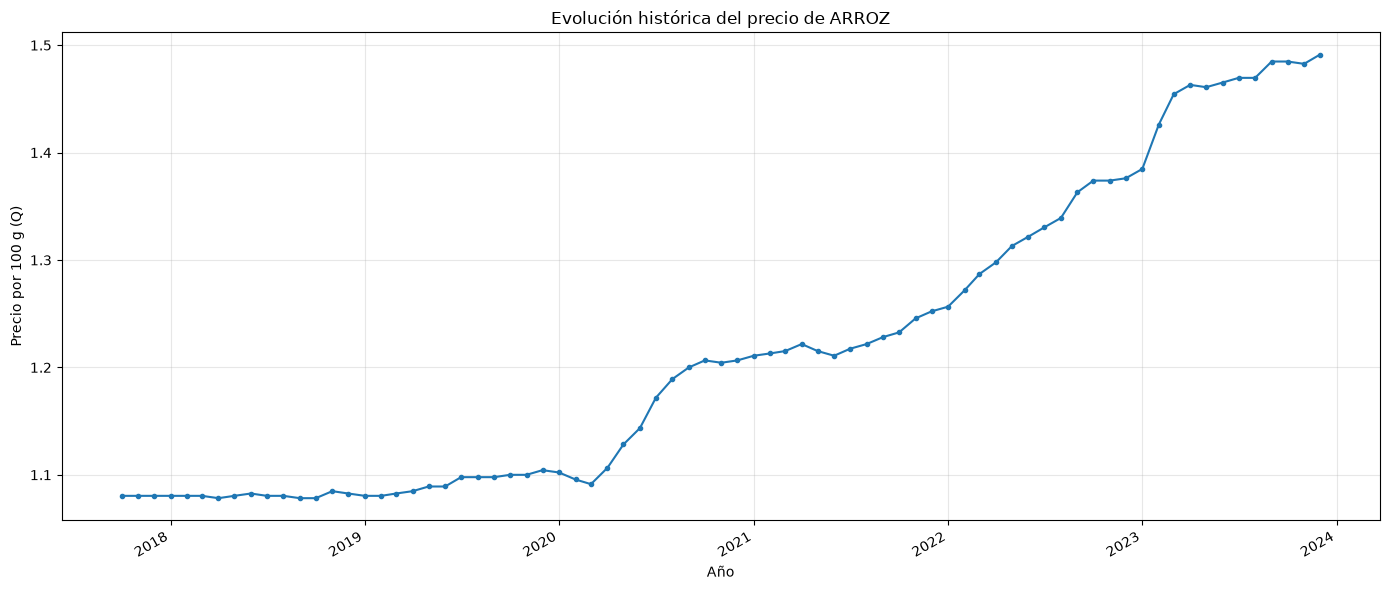

In [11]:
fig, ax = food.plot_timeline('general')

Tendencia general de crecimiento 

In [12]:
food_timeline_summary = food.price_summary("general")

labels = {
    "first": "Primer precio registrado",
    "latest": "Último precio registrado",
    "lowest": "Precio más bajo",
    "highest": "Precio más alto",
}

print(f"Resumen de {food.name} — región general")
print("=" * 50)

for key, label in labels.items():
    point = food_timeline_summary[key]

    if point is None:
        print(f"{label}: sin información")
        continue

    print(
        f"{label}: "
        f"Q{point.price_per_100g:.2f} por 100 g "
        f"({point.month:02d}/{point.year})"
    )

Resumen de ARROZ — región general
Primer precio registrado: Q1.08 por 100 g (10/2017)
Último precio registrado: Q1.49 por 100 g (12/2023)
Precio más bajo: Q1.08 por 100 g (04/2018)
Precio más alto: Q1.49 por 100 g (12/2023)


#### Arroz corriente - Explorarcion de datos

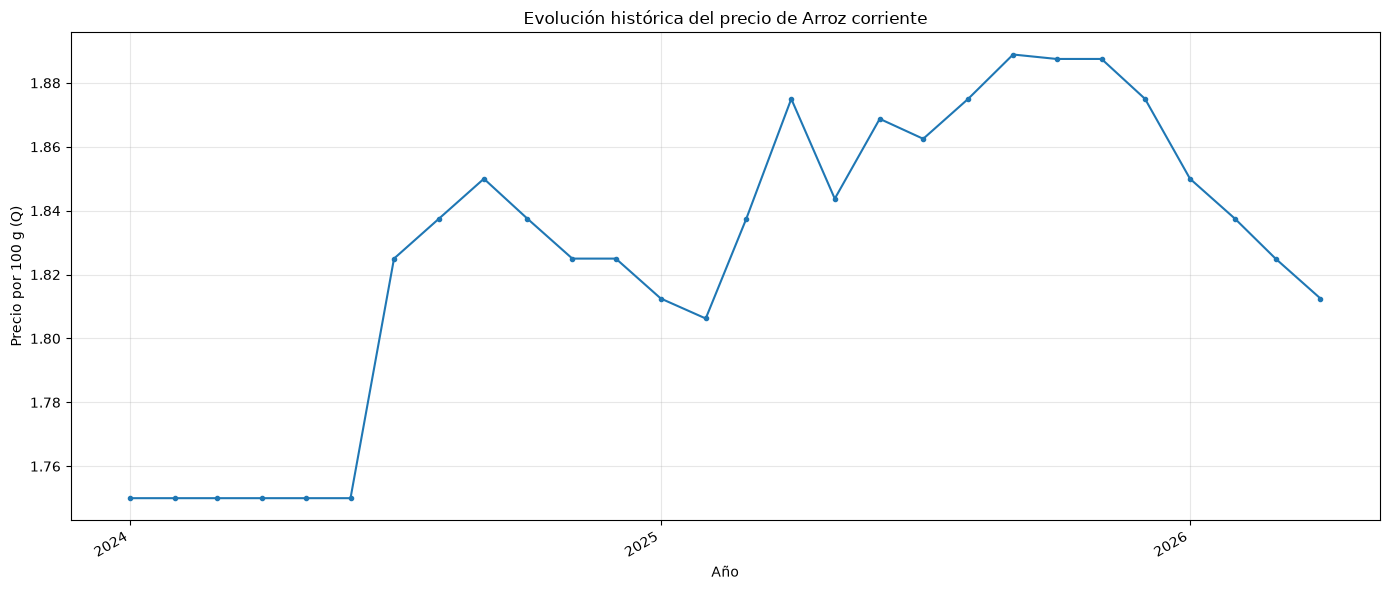

In [13]:
fig, ax = catalog.get('arroz_corriente').plot_timeline('urbana')

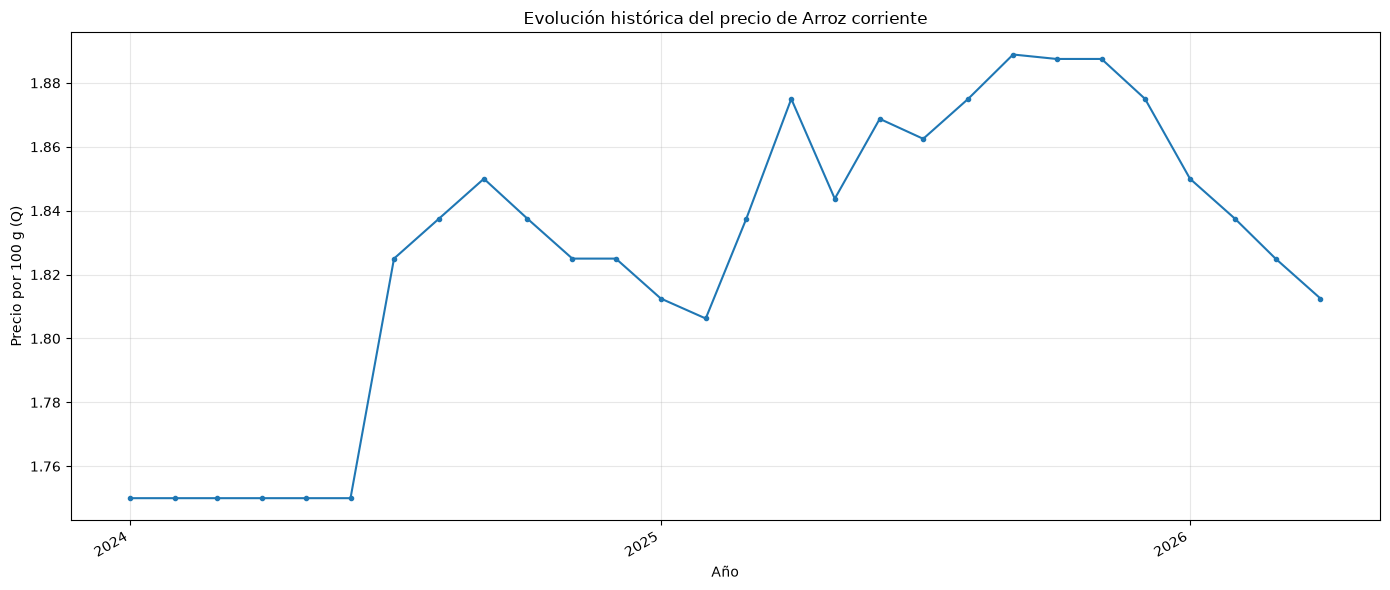

In [14]:
fig, ax = catalog.get('arroz_corriente').plot_timeline('rural')

Los precios se mantienen en ambas regiones asi que usamos la general para resumir la comparacion

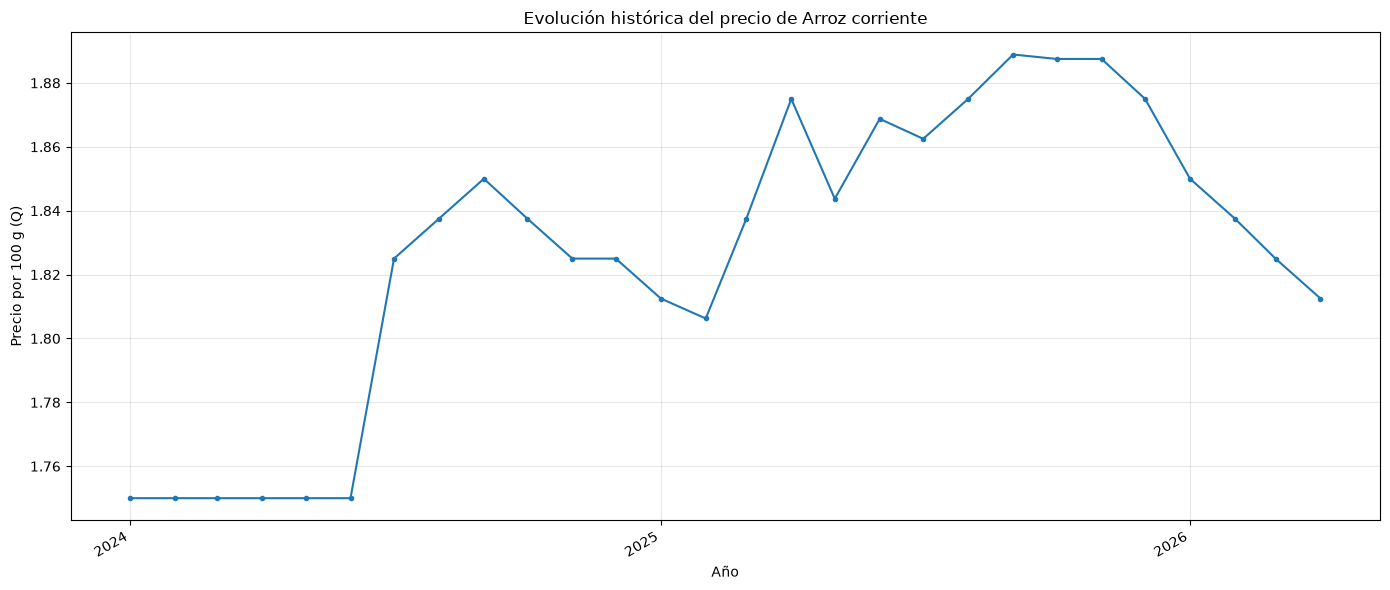

In [15]:
fig, ax = catalog.get('arroz_corriente').plot_timeline('general')

Si comparamos el primer punto del ultimo, podemos decir que si hubo un aumento en el precio, pero sin una tendencia clara, muy fluctante en el periodo. 

In [16]:
target_food = catalog.get('arroz_corriente')
food_timeline_summary = target_food.price_summary("general")

labels = {
    "first": "Primer precio registrado",
    "latest": "Último precio registrado",
    "lowest": "Precio más bajo",
    "highest": "Precio más alto",
}

print(f"Resumen de {target_food.name} — región general")
print("=" * 50)

for key, label in labels.items():
    point = food_timeline_summary[key]

    if point is None:
        print(f"{label}: sin información")
        continue

    print(
        f"{label}: "
        f"Q{point.price_per_100g:.2f} por 100 g "
        f"({point.month:02d}/{point.year})"
    )

Resumen de Arroz corriente — región general
Primer precio registrado: Q1.75 por 100 g (01/2024)
Último precio registrado: Q1.81 por 100 g (04/2026)
Precio más bajo: Q1.75 por 100 g (02/2024)
Precio más alto: Q1.89 por 100 g (09/2025)


#### Arroz Precocido - Explorarcion de datos

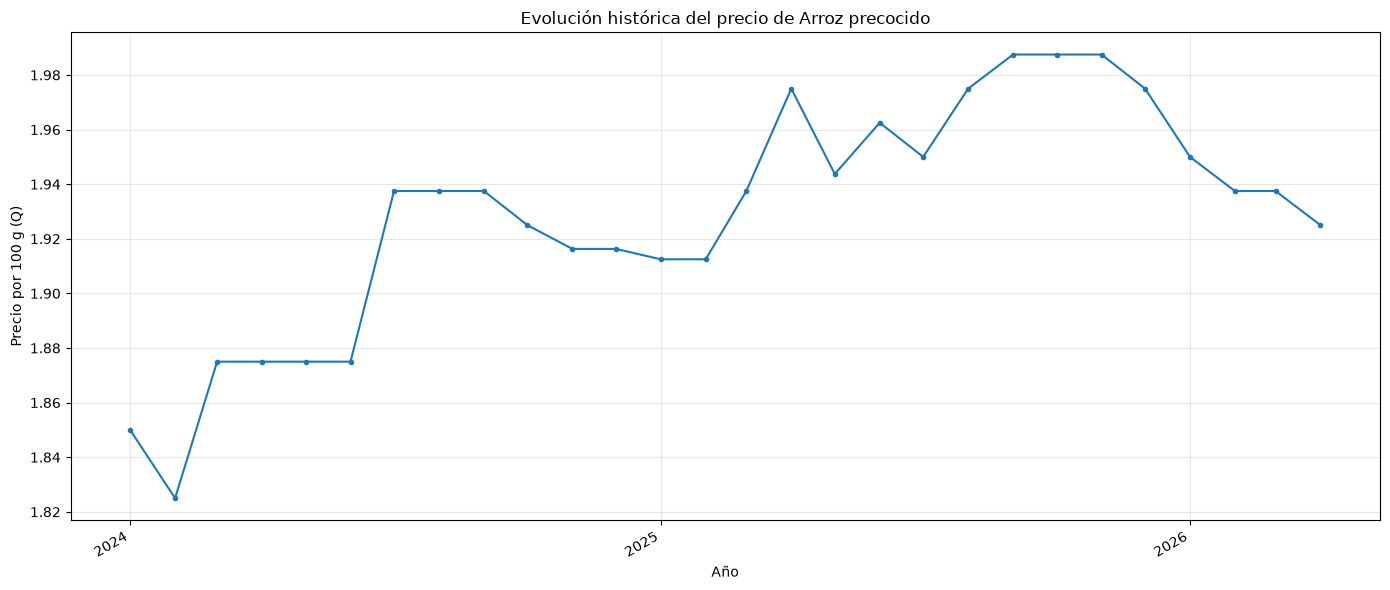

In [17]:
fig, ax = catalog.get('arroz_precocido').plot_timeline('urbana')

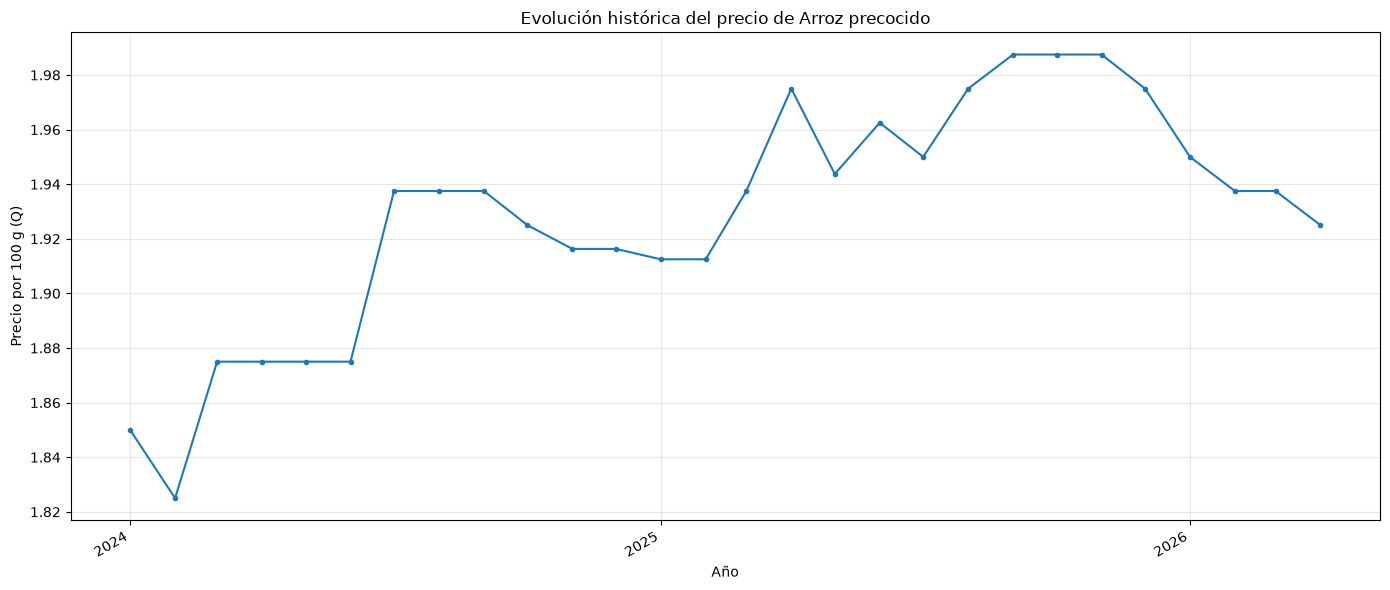

In [18]:
fig, ax = catalog.get('arroz_precocido').plot_timeline('rural')

Los precios se mantienen en ambas regiones asi que usamos la general para resumir la comparacion

Si comparamos el primer punto del ultimo, podemos decir que si hubo un aumento en el precio, pero sin una tendencia clara, muy fluctante en el periodo. 

In [19]:
target_food = catalog.get('arroz_precocido')
food_timeline_summary = target_food.price_summary("general")

labels = {
    "first": "Primer precio registrado",
    "latest": "Último precio registrado",
    "lowest": "Precio más bajo",
    "highest": "Precio más alto",
}

print(f"Resumen de {target_food.name} — región general")
print("=" * 50)

for key, label in labels.items():
    point = food_timeline_summary[key]

    if point is None:
        print(f"{label}: sin información")
        continue

    print(
        f"{label}: "
        f"Q{point.price_per_100g:.2f} por 100 g "
        f"({point.month:02d}/{point.year})"
    )

Resumen de Arroz precocido — región general
Primer precio registrado: Q1.85 por 100 g (01/2024)
Último precio registrado: Q1.92 por 100 g (04/2026)
Precio más bajo: Q1.82 por 100 g (02/2024)
Precio más alto: Q1.99 por 100 g (11/2025)


#### Conclusion

Dado que, en primer lugar el nombre `arroz corriente` sugiere ser lo mismo que `arroz`; en segunda lugar, en tanto al precio, tanto el precocido como el corriente, tienen una continuidad lógica, sin embargo precio inicial del corriente es mas cercano que el del precocido

Por estos motivos, se procede a mergear datos de cba `arroz corriente` y `arroz`. Y `arroz precocido` queda separado e independiente. 

In [ ]:
catalog.merge_foods('arroz', 'arroz_corriente')
# mergeado hasta el final para no afectar el iterable

## Avena de toda clase


In [21]:
food = next(catalog_iterable)
print(food.id)

avena_de_toda_clase


In [22]:
food =catalog.get('avena_de_toda_clase')
food.years_by_region()

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023],
 'rural': [],
 'urbana': []}

No tiene datos de 2024 a 2026

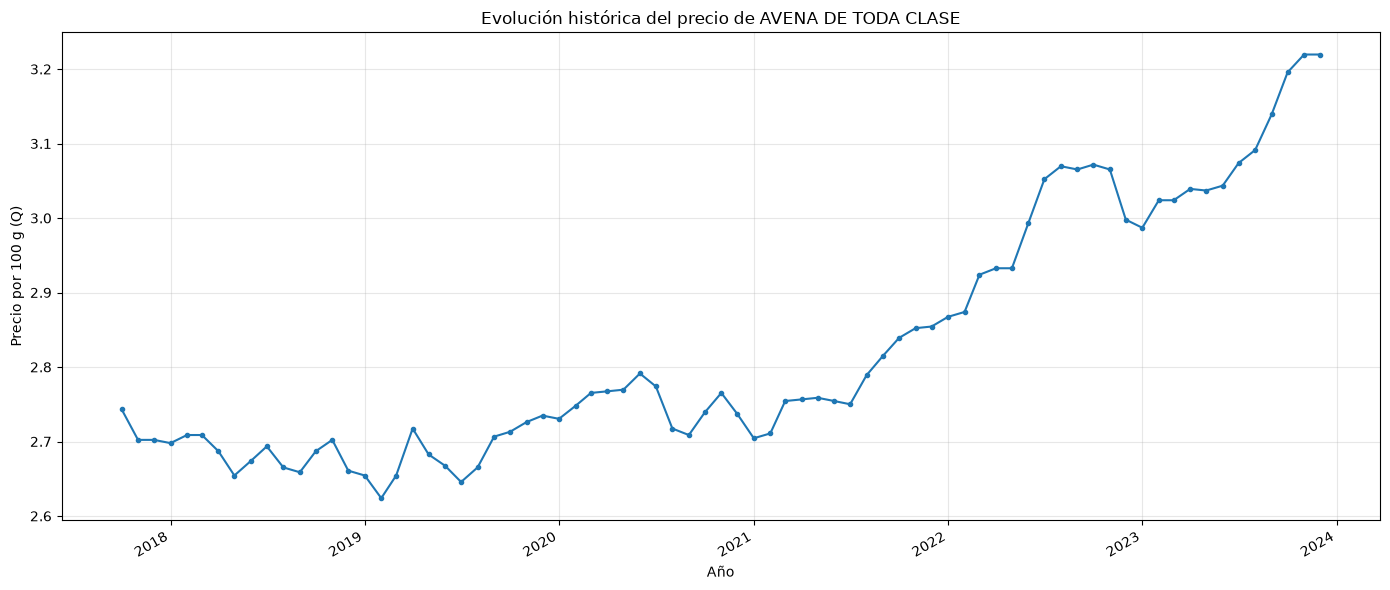

In [23]:
fig, ax = food.plot_timeline('general')

In [24]:
for food in catalog:
    if food.id.startswith('avena'):
        print(food)
        print("===============")
        for region, ptf in food.price_timelines.items(): 
            print(f"Region: {region}")
            print(ptf.avg_daily_grams())

Food(id='avena_de_toda_clase', name='AVENA DE TODA CLASE', category='CEREALES', aliases={'AVENA DE TODA CLASE', 'Avena de toda clase'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026F9B5CF4D0>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())
Region: general
10.479385045422797
Food(id='avena_mosh', name='Avena/mosh', category=None, aliases={'Avena/mosh'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC5A150>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())
Region: rural
2.4828176204512586


Por nombre, el candidato a mergear es Avena/Mosh. Aunque unicamente tenga presencia en el area rural 

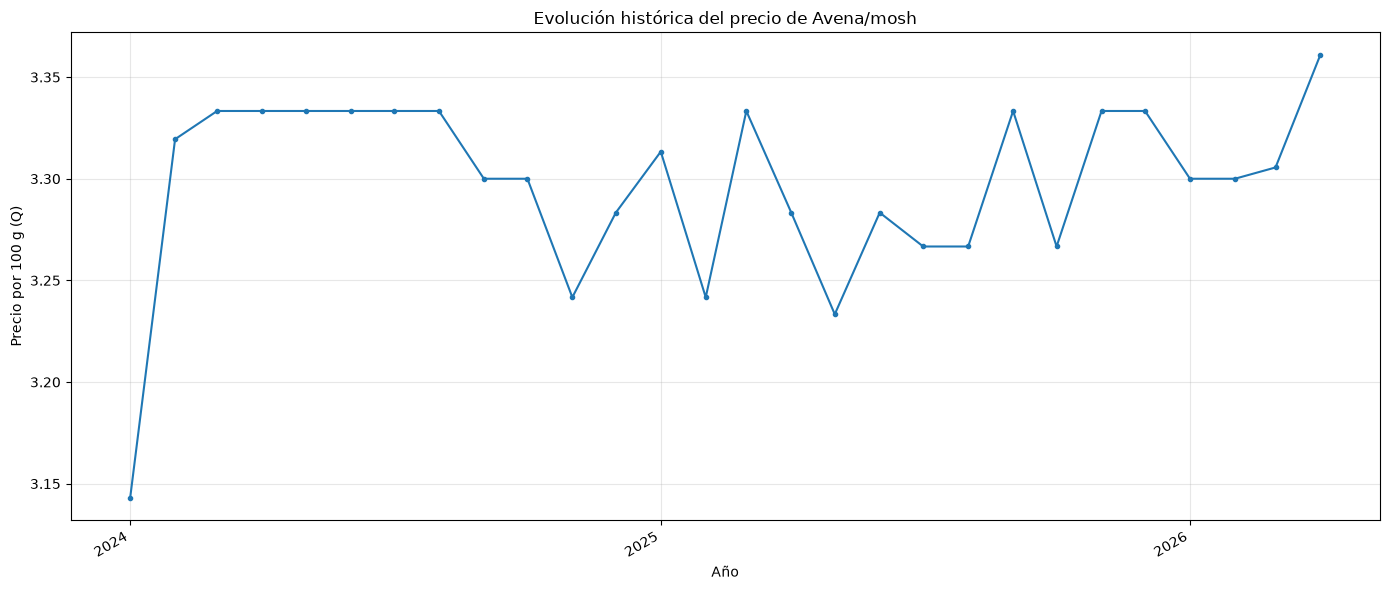

In [25]:
fig, ax = catalog.get('avena_mosh').plot_timeline('rural')

In [26]:
labels = {
    'first': 'Primer precio registrado',
    'latest': 'Último precio registrado',
    'lowest': 'Precio más bajo',
    'highest': 'Precio más alto',
}

for _food, region in [('avena_de_toda_clase', 'general'), ('avena_mosh', 'rural')]:
    target_food = catalog.get(_food)
    print(f'Resumen de {target_food.name} — región {region}')
    print('=' * 50)
    for key, label in labels.items():
        point = target_food.price_summary(region)[key]
        if point is None:
            print(f'{label}: sin información')
            continue
        print(f'{label}: Q{point.price_per_100g:.2f} por 100 g ({point.month:02d}/{point.year})')
    print()

Resumen de AVENA DE TODA CLASE — región general
Primer precio registrado: Q2.74 por 100 g (10/2017)
Último precio registrado: Q3.22 por 100 g (12/2023)
Precio más bajo: Q2.62 por 100 g (02/2019)
Precio más alto: Q3.22 por 100 g (11/2023)

Resumen de Avena/mosh — región rural
Primer precio registrado: Q3.14 por 100 g (01/2024)
Último precio registrado: Q3.36 por 100 g (04/2026)
Precio más bajo: Q3.14 por 100 g (01/2024)
Precio más alto: Q3.36 por 100 g (04/2026)



#### Conclusión

La similitud del nombre y la continuidad observada en los precios respaldan la unificación de `Avena/mosh` con `Avena de toda clase`. 

## Pan Frances

In [27]:
food = next(catalog_iterable)
print(food.id)

pan_frances


In [28]:
food = catalog.get('pan_frances')

In [29]:
print(food.id)
print(food.years_by_region())

pan_frances
{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


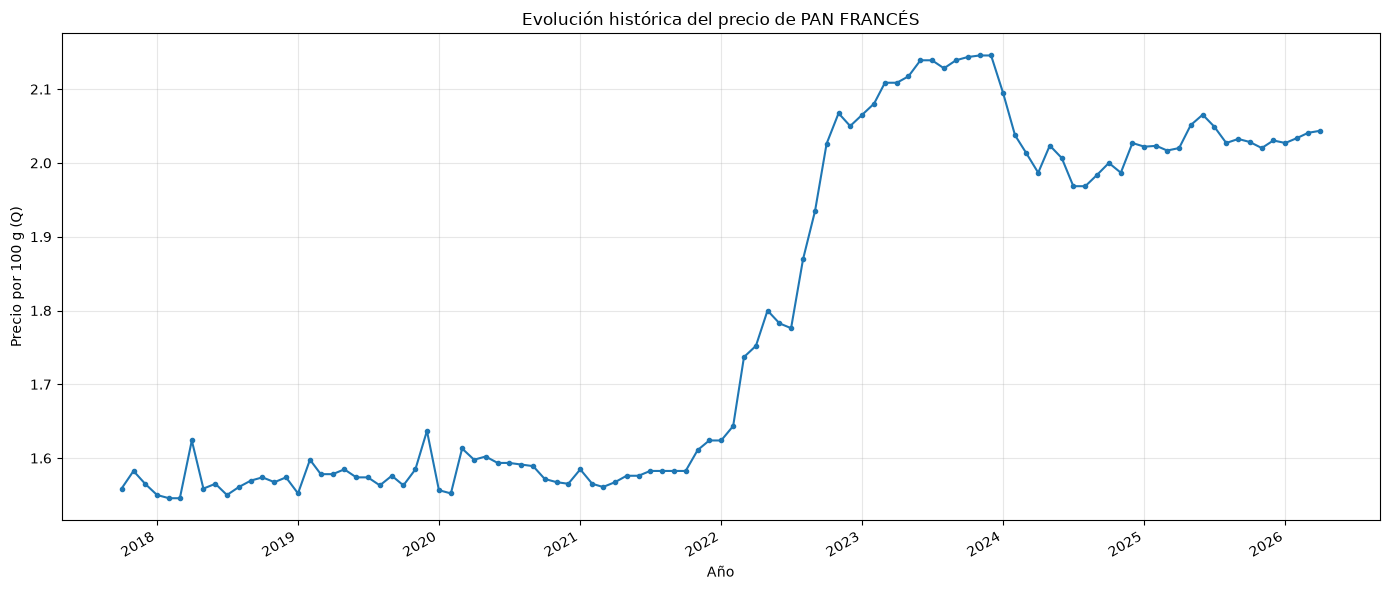

In [30]:
fig, ax = food.plot_timeline('general')

No es requerida ninguna accion adicional 

## Pan Dulce

In [31]:
food = next(catalog_iterable)
print(food.id)

pan_dulce


In [32]:
food = catalog.get('pan_dulce')
print()

pan_dulce
{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


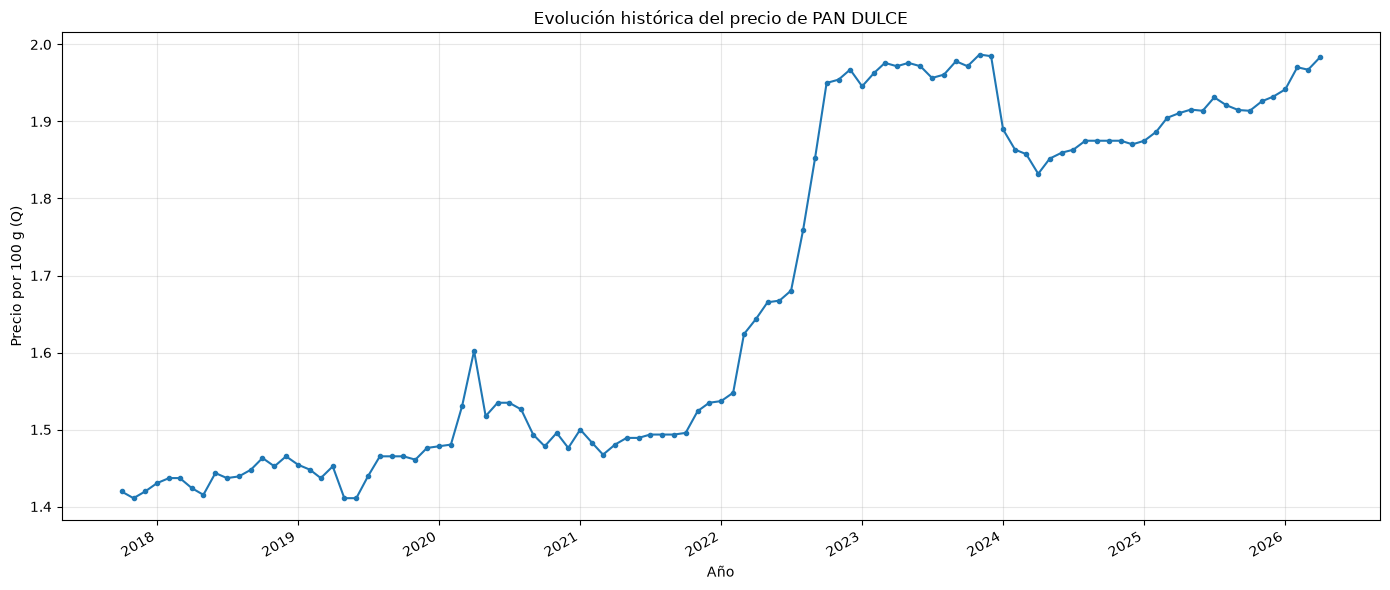

In [33]:
print(food.id)
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

No es requerida ninguna accion adicional 

## Fideos

In [34]:
food = catalog.get('fideos')
print(food.id)

fideos


{'general': [2017, 2018, 2019, 2020], 'rural': [], 'urbana': []}


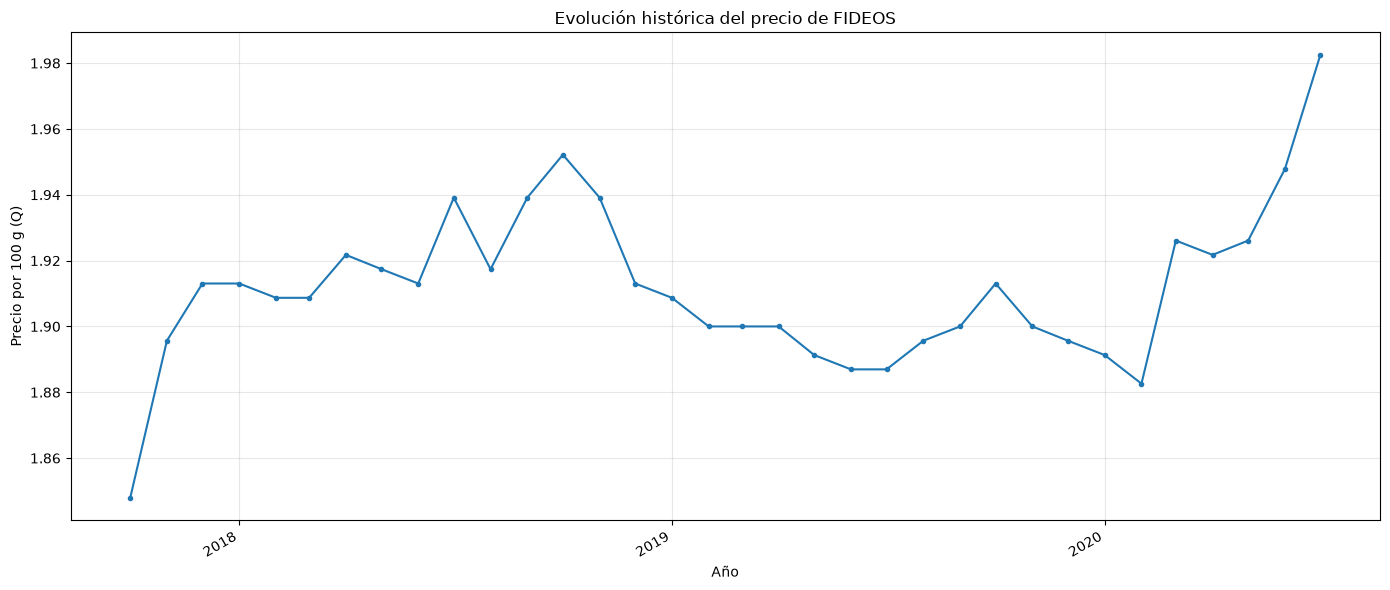

In [35]:
food = catalog.get('fideos')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [36]:
labels = {
    'first': 'Primer precio registrado',
    'latest': 'Último precio registrado',
    'lowest': 'Precio más bajo',
    'highest': 'Precio más alto',
}
region = 'general'
print(f'Resumen de {food.name} — región {region}')
print('=' * 50)
for key, label in labels.items():
    point = food.price_summary(region)[key]
    if point is None:
        print(f'{label}: sin información')
        continue
    print(f'{label}: Q{point.price_per_100g:.2f} por 100 g ({point.month:02d}/{point.year})')
print()

Resumen de FIDEOS — región general
Primer precio registrado: Q1.85 por 100 g (10/2017)
Último precio registrado: Q1.98 por 100 g (07/2020)
Precio más bajo: Q1.85 por 100 g (10/2017)
Precio más alto: Q1.98 por 100 g (07/2020)



La serie original de `FIDEOS` termina en julio de 2020. Es necesario buscar candidatos que permitan completar el periodo posterior.

In [37]:
candidates = [
    catalog.get('fideos_en_todas_sus_formas_excepto_macarrones_y_espagueti'),
]

for candidate in candidates:
    print(candidate.name)
    print(candidate.years_by_region())
    for region, timeline in candidate.price_timelines.items():
        print(f'Consumo diario promedio ({region}): {timeline.avg_daily_grams():.2f} g')
    print()

labels = {
    'first': 'Primer precio registrado',
    'latest': 'Último precio registrado',
    'lowest': 'Precio más bajo',
    'highest': 'Precio más alto',
}


Fideos en todas sus formas (Excepto macarrones y espagueti)
{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}
Consumo diario promedio (rural): 6.63 g
Consumo diario promedio (urbana): 5.86 g
Consumo diario promedio (general): 6.24 g



Resumen de Fideos en todas sus formas (Excepto macarrones y espagueti) — región rural
Primer precio registrado: Q2.25 por 100 g (01/2024)
Último precio registrado: Q2.10 por 100 g (04/2026)
Precio más bajo: Q2.09 por 100 g (02/2024)
Precio más alto: Q2.25 por 100 g (01/2024)

Resumen de Fideos en todas sus formas (Excepto macarrones y espagueti) — región urbana
Primer precio registrado: Q2.25 por 100 g (01/2024)
Último precio registrado: Q2.10 por 100 g (04/2026)
Precio más bajo: Q2.09 por 100 g (02/2024)
Precio más alto: Q2.25 por 100 g (01/2024)

Resumen de Fideos en todas sus formas (Excepto macarrones y espagueti) — región general
Primer precio registrado: Q2.25 por 100 g (01/2024)
Último precio registrado: Q2.10 por 100 g (04/2026)
Precio más bajo: Q2.09 por 100 g (02/2024)
Precio más alto: Q2.25 por 100 g (01/2024)



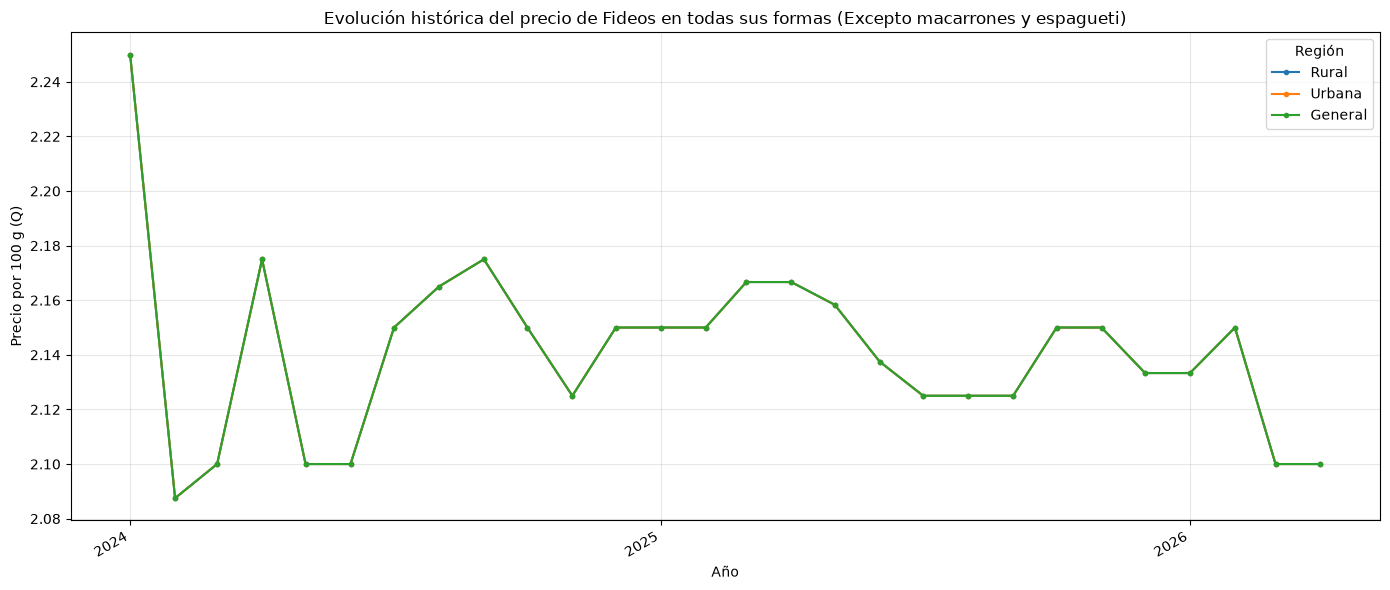

In [38]:
for _food in candidates:
    fig, ax = _food.plot_timeline()
    for _region in ('rural', 'urbana', 'general'):
        print(f'Resumen de {_food.name} — región {_region}')
        print('=' * 50)
        for key, label in labels.items():
            point = _food.price_summary(_region)[key]
            if point is None:
                print(f'{label}: sin información')
                continue
            print(f'{label}: Q{point.price_per_100g:.2f} por 100 g ({point.month:02d}/{point.year})')
        print()

`Fideos en todas sus formas (excepto macarrones y espagueti)` cubre desde enero de 2024. Su primer precio general es Q2.25 por 100 g, cercano al último precio de 2023, pero todavía debemos cubrir agosto de 2020 a diciembre de 2023.

PASTAS ALIMENTICIAS
{'general': [2020], 'rural': [], 'urbana': []}


Resumen de PASTAS ALIMENTICIAS — región rural
Primer precio registrado: sin información
Último precio registrado: sin información
Precio más bajo: sin información
Precio más alto: sin información

Resumen de PASTAS ALIMENTICIAS — región urbana
Primer precio registrado: sin información
Último precio registrado: sin información
Precio más bajo: sin información
Precio más alto: sin información

Resumen de PASTAS ALIMENTICIAS — región general
Primer precio registrado: Q2.00 por 100 g (08/2020)
Último precio registrado: Q2.00 por 100 g (08/2020)
Precio más bajo: Q2.00 por 100 g (08/2020)
Precio más alto: Q2.00 por 100 g (08/2020)

PASTAS DE TODOS LOS TIPOS
{'general': [2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}
Resumen de PASTAS DE TODOS LOS TIPOS — región rural
Primer precio registrado: sin información
Último precio registrado: sin información
Precio más bajo: sin información
Precio más alto: sin información

Resumen de PASTAS DE TODOS LOS TIPOS — región urbana
Primer precio regis

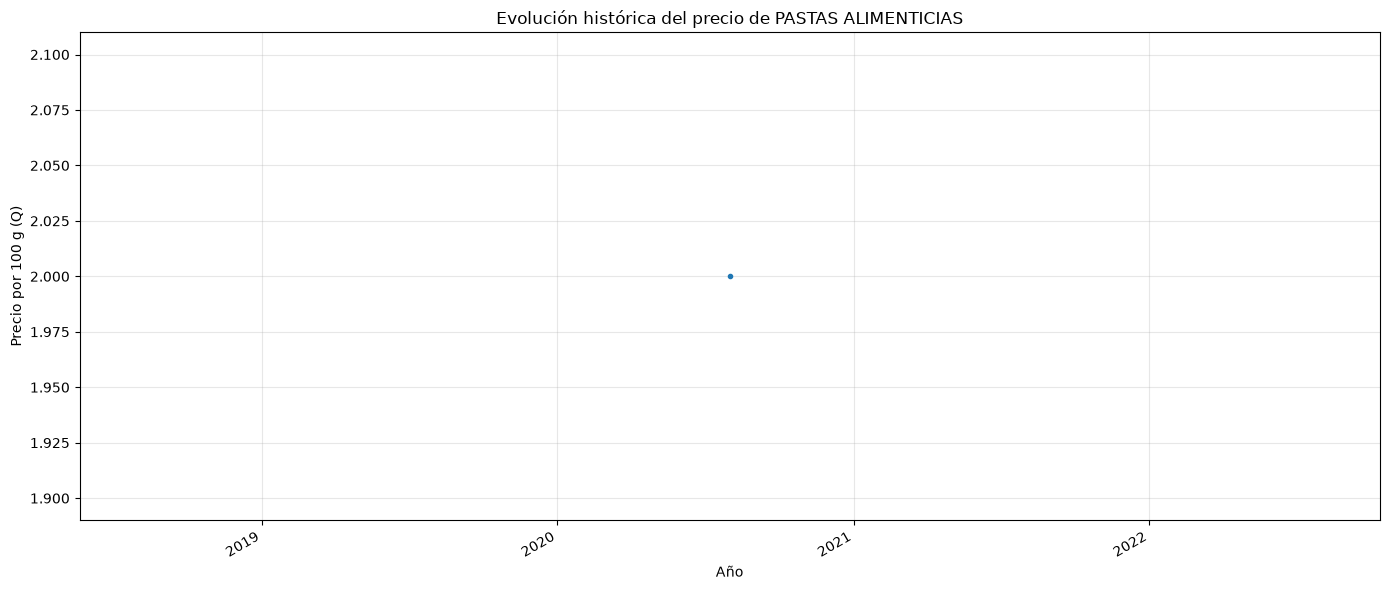

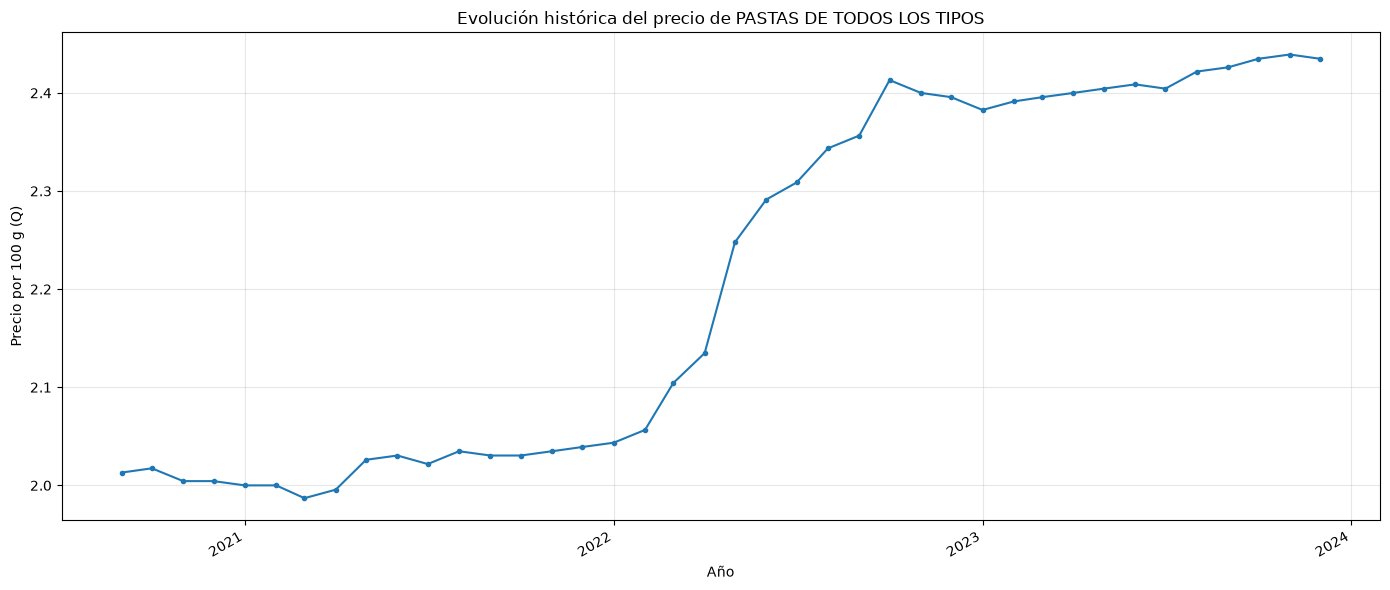

In [39]:
other_candidates = [
    catalog.get('pastas_alimenticias'),
    catalog.get('pastas_de_todos_los_tipos'),
]
for _food in other_candidates:
    print(_food.name)
    print(_food.years_by_region())
    fig, ax = _food.plot_timeline('general')
    for _region in ('rural', 'urbana', 'general'):
        print(f'Resumen de {_food.name} — región {_region}')
        print('=' * 50)
        for key, label in labels.items():
            point = _food.price_summary(_region)[key]
            if point is None:
                print(f'{label}: sin información')
                continue
            print(f'{label}: Q{point.price_per_100g:.2f} por 100 g ({point.month:02d}/{point.year})')
        print()

candidates += other_candidates

#### Conclusión

Los candidatos forman una serie temporal continua y sus precios de enlace son coherentes: `FIDEOS` termina en julio de 2020 con Q1.98 por 100 g; `PASTAS ALIMENTICIAS` aporta agosto de 2020 con Q2.00; `PASTAS DE TODOS LOS TIPOS` comienza en septiembre de 2020 con Q2.01 y llega a diciembre de 2023 con Q2.43; finalmente, `Fideos en todas sus formas (excepto macarrones y espagueti)` comienza en enero de 2024 con Q2.25.

Por nombre, cobertura temporal y continuidad de precios, se unifican los tres candidatos con `FIDEOS`. Los macarrones y el espagueti quedan excluidos porque el propio nombre del candidato regional los distingue.

## Tortillas de Maiz

In [40]:
food = catalog.get('tortillas_de_maiz')
food

Food(id='tortillas_de_maiz', name='TORTILLAS DE MAÍZ', category='CEREALES', aliases={'Tortillas de maíz', 'TORTILLAS DE MAÍZ'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026F9B62F890>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


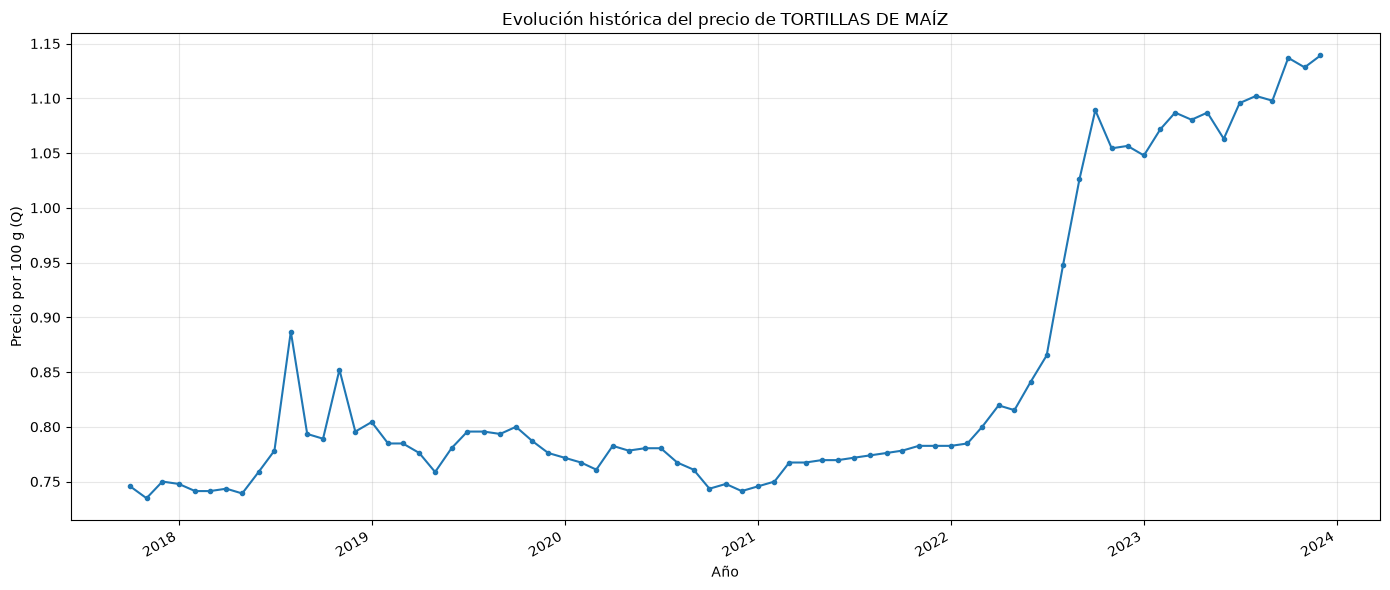

In [41]:
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [42]:
for food in catalog:
    if food.id.startswith('tortilla') and food.id != 'tortillas_de_maiz':
        print(food)
        print("===============")
        for region, ptf in food.price_timelines.items(): 
            print(f"Region: {region}")
            print(ptf.avg_daily_grams())

Food(id='tortillas_frescas', name='Tortillas frescas', category=None, aliases={'Tortillas frescas'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC5A3F0>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBCC9A90>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBD134D0>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())
Region: rural
305.8934378575231
Region: urbana
267.424457457515
Region: general
286.65894765751904


{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


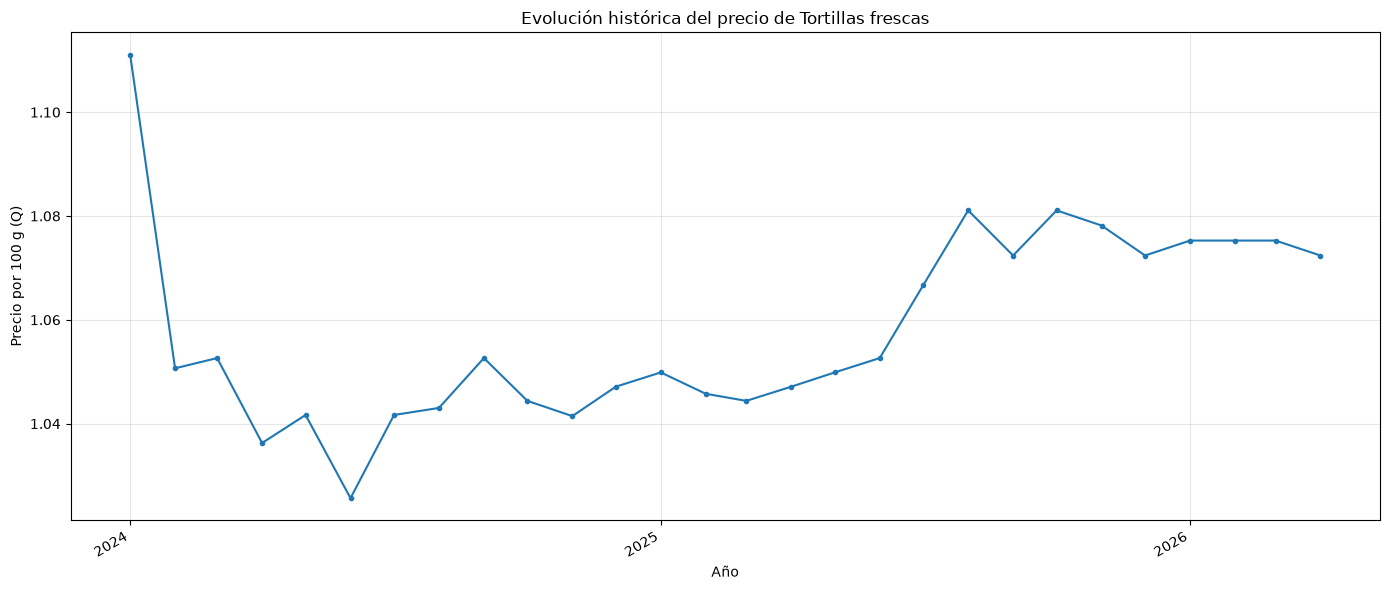

In [43]:
print(catalog.get('tortillas_frescas').years_by_region())
fig, ax = catalog.get('tortillas_frescas').plot_timeline('general')

Continuidad de precio corresponde.

## Carne de res sin hueso

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


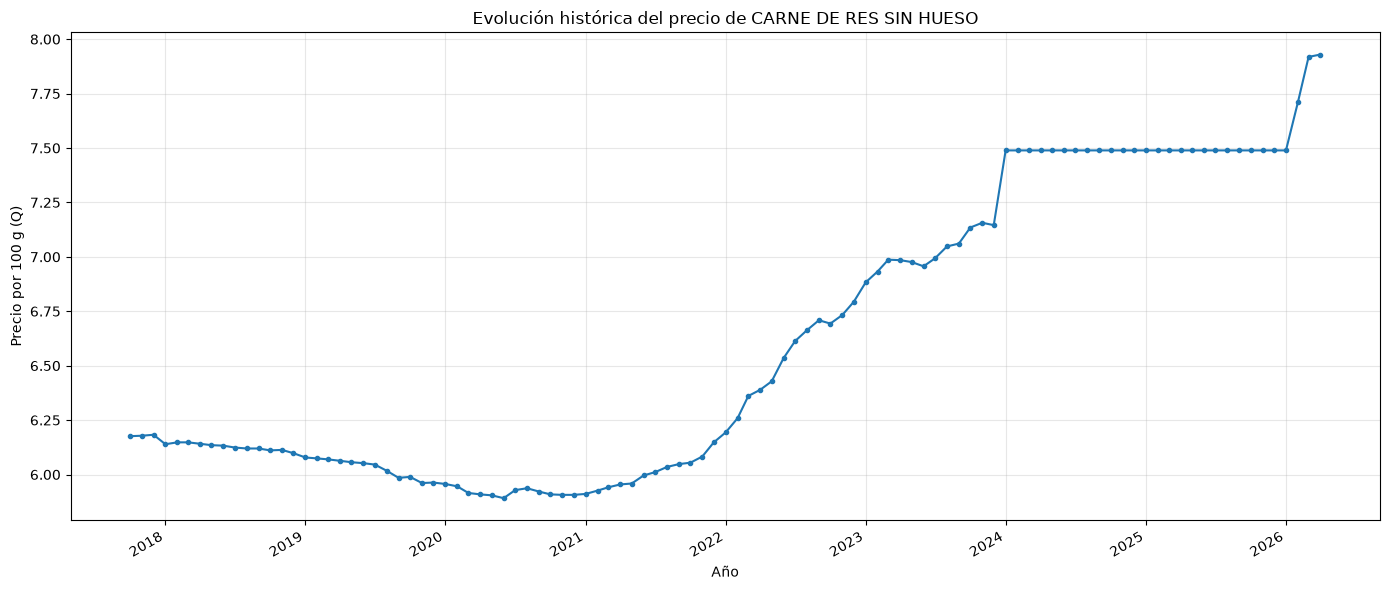

In [44]:
food = catalog.get('carne_de_res_sin_hueso')
food
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

Periodo completo, sin cambios requeridos. 

## Carne de res con hueso

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


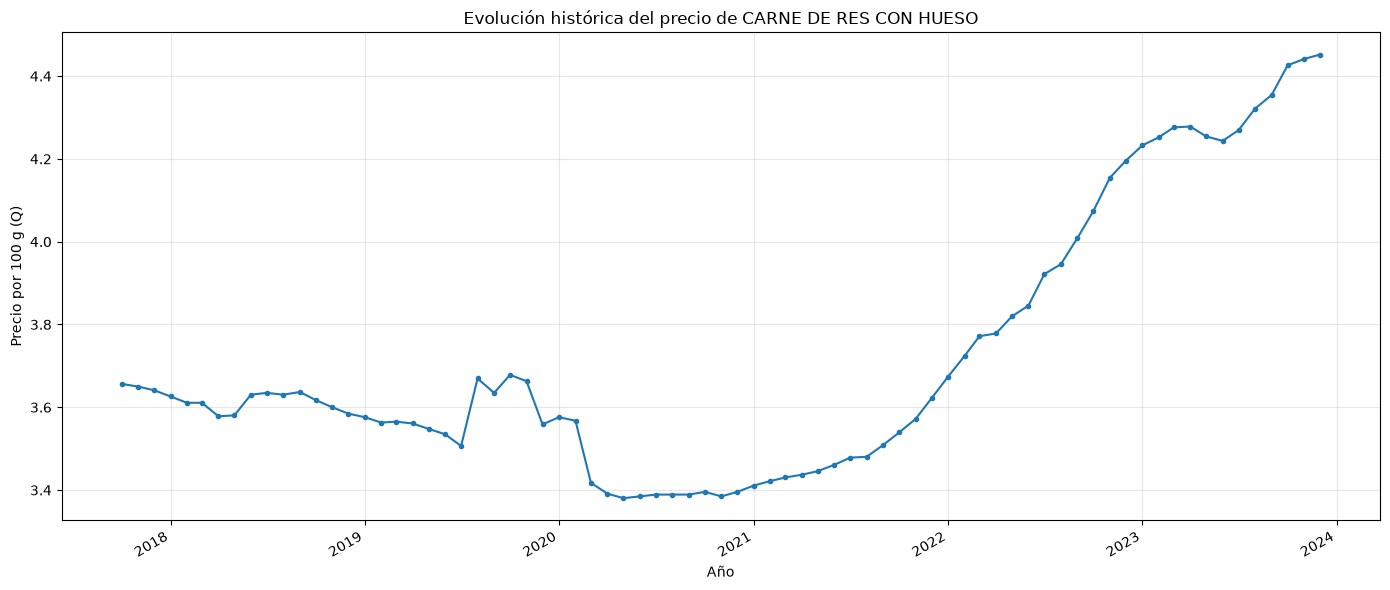

In [45]:
food = catalog.get('carne_de_res_con_hueso')
food
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [46]:
candidates = [_food for _food in catalog if 'res' in _food.id and 'con' in _food.id and 'carne' in _food.id and 'hueso' in _food.id   ]
candidates.pop(0) # ELIMINAMOS el que ya esta incluido 
candidates

[Food(id='carne_de_res_con_hueso_para_cocido', name='Carne de res con hueso para cocido', category=None, aliases={'Carne de res con hueso para cocido'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC5A2D0>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBCC9C10>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBD12AB0>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=()),
 Food(id='carne_de_res_para_asar_con_y_sin_hueso', name='Carne de res para asar (con y sin hueso)', category=None, aliases={'Carne de res para asar (con y sin hueso)'}, price_timelines={'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBCC9CD0>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())]

{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


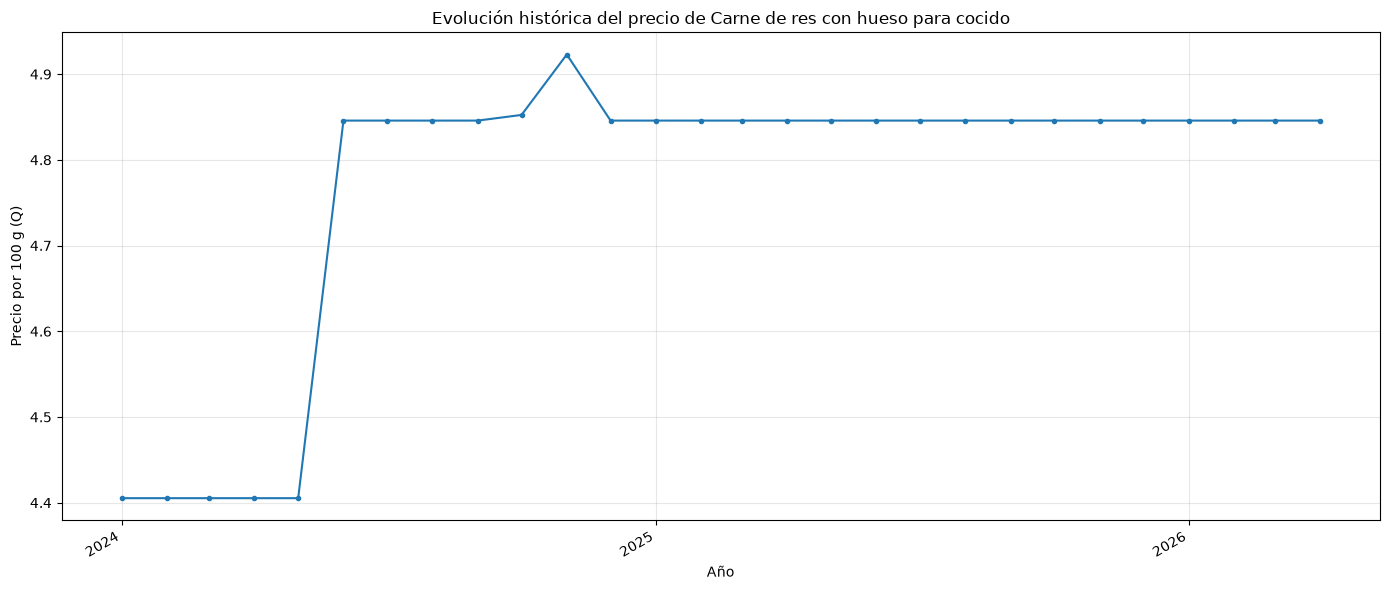

In [47]:
_candidate_2 = catalog.get('carne_de_res_con_hueso_para_cocido')
print(_candidate_2.years_by_region())
fig, ax = _candidate_2.plot_timeline('general')

{'general': [], 'rural': [], 'urbana': [2024, 2025, 2026]}


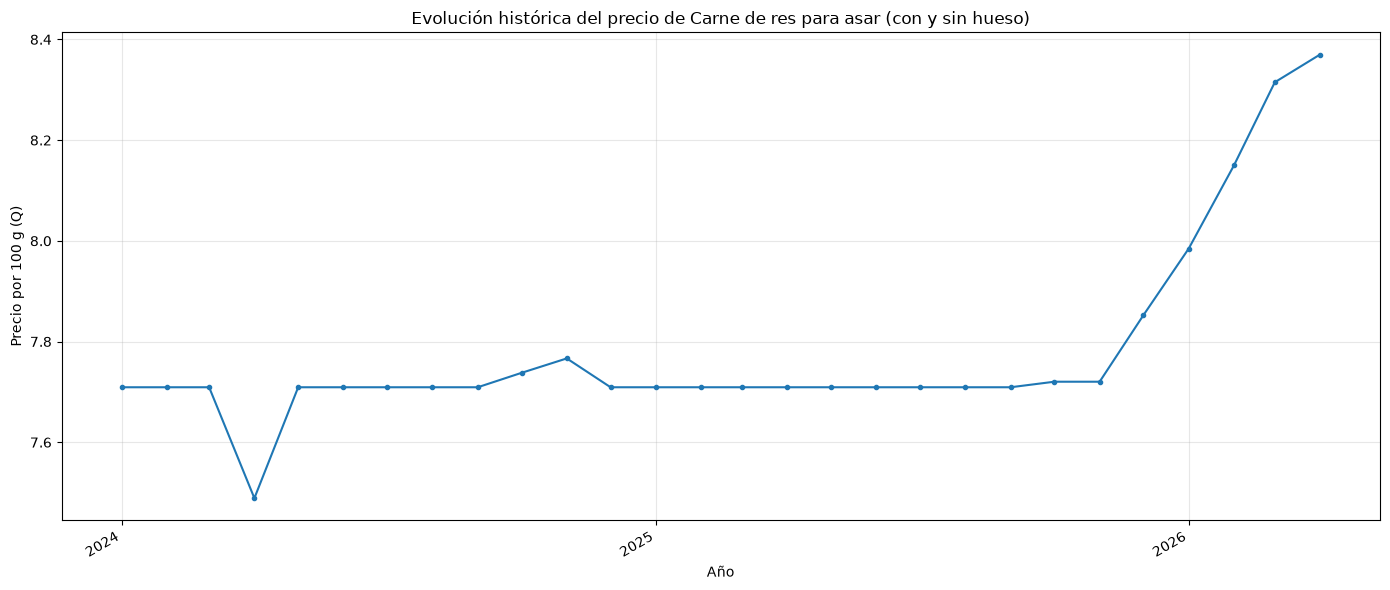

In [48]:
_candidate_2 = catalog.get('carne_de_res_para_asar_con_y_sin_hueso')
print(_candidate_2.years_by_region())
fig, ax = _candidate_2.plot_timeline('urbana')

Por continuidad de precio y por la especificacion de que es **con** hueso, el candidato correctao a mergear es `carne_de_res_con_hueso_para_cocido`

## Carne de cerdo sin hueso

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


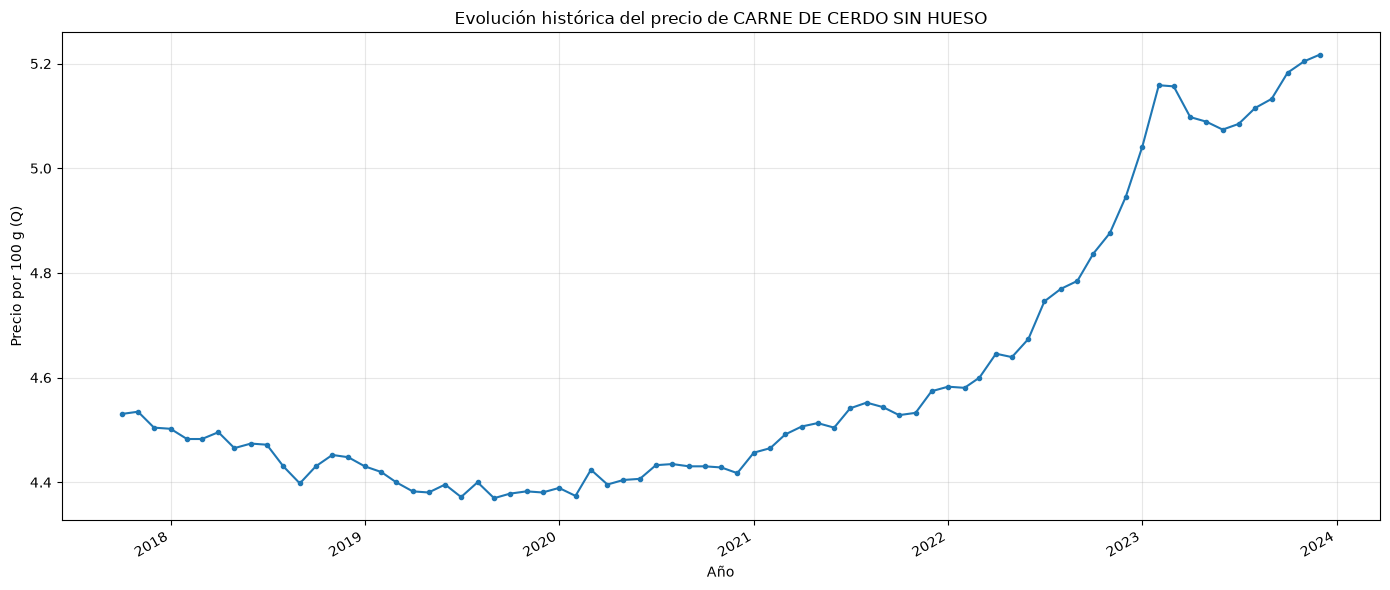

In [49]:
food = catalog.get('carne_de_cerdo_sin_hueso')
food
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [50]:
candidates = [_food for _food in catalog if 'cerdo' in _food.id and 'posta' in _food.id  ]
#candidates.pop(0) # ELIMINAMOS el que ya esta incluido 
candidates

[Food(id='posta_de_cerdo_sin_hueso', name='Posta de cerdo sin hueso', category=None, aliases={'Posta de cerdo sin hueso'}, price_timelines={'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBCCA1B0>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())]

{'general': [], 'rural': [], 'urbana': [2024, 2025, 2026]}


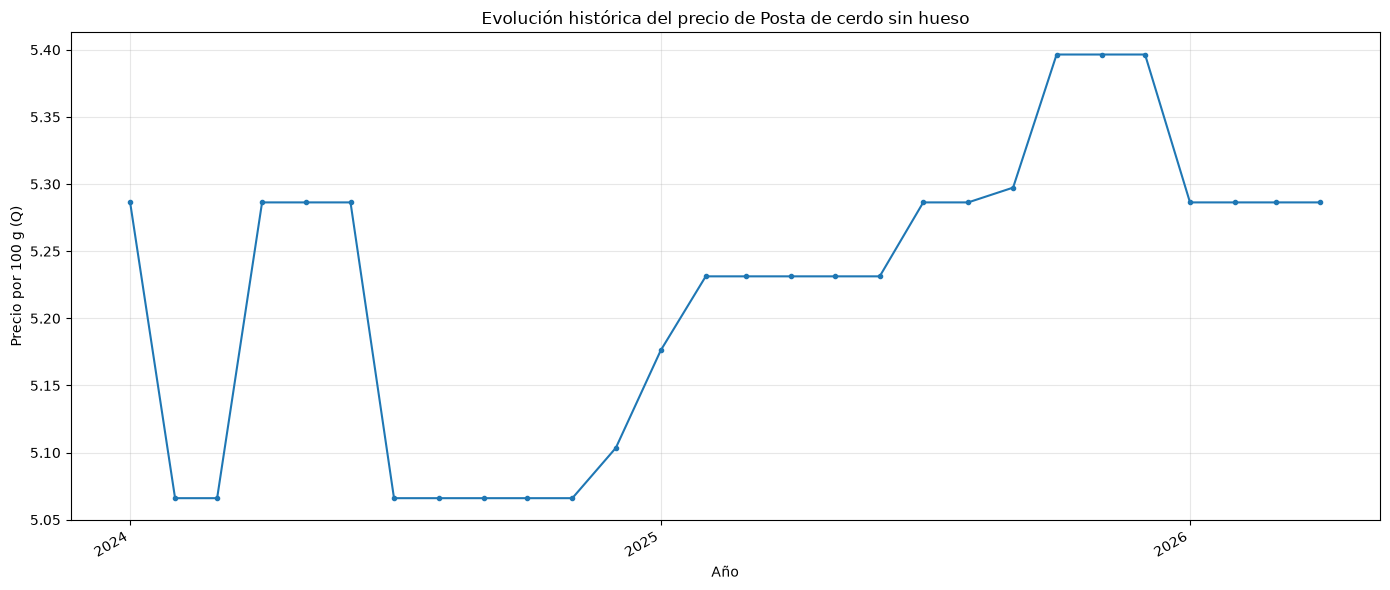

In [51]:
_candidate_2 = catalog.get('posta_de_cerdo_sin_hueso')
food
print(_candidate_2.years_by_region())
fig, ax = _candidate_2.plot_timeline('urbana')

Aunque sin la presencia en el area rural, la `posta_de_cerdo_sin_hueso` sigue una continuidad considerable con los precios de `carne_de_cerdo_sin_hueso`. Conceptualmente la carne no es lo mismo que la posta, segun de que seccion del cerdo que se extraiga pero el precio sigue una continuidad aceptable, por este motivo principal se mergea estos alimento, aclarando que es una cuestion de conveniencia mas no precisan de la misma definicion de un alimento a otro. 

## Carne de pollo o gallina

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


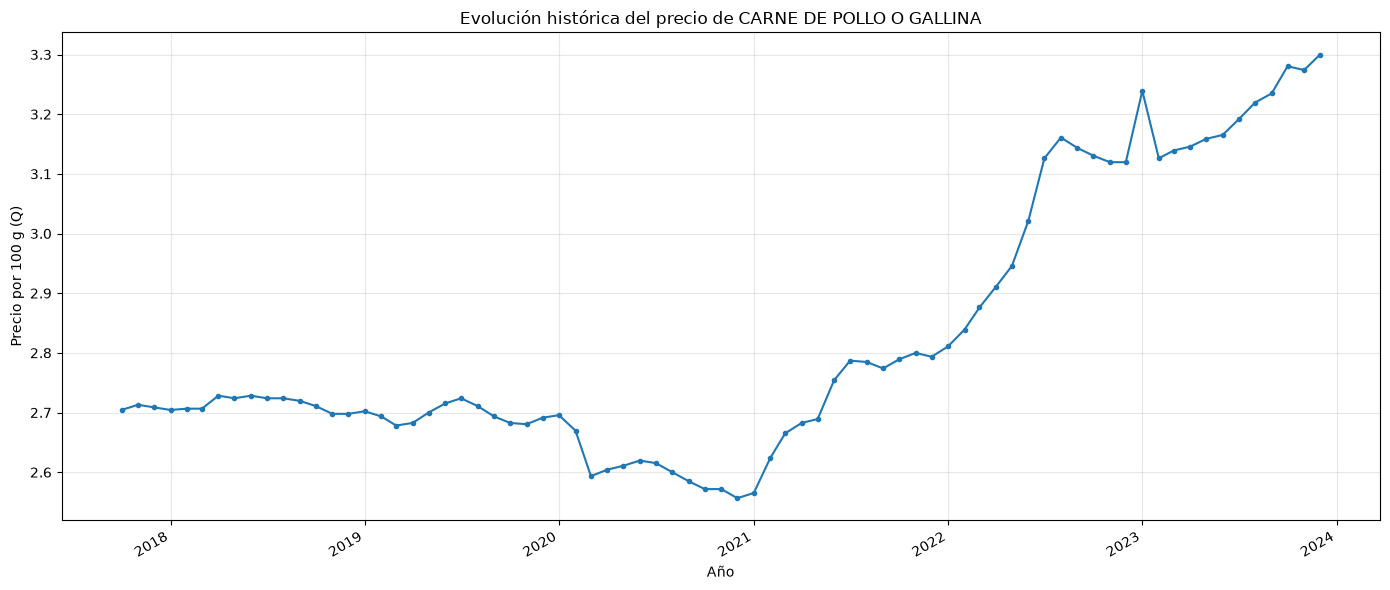

In [52]:
food = catalog.get('carne_de_pollo_o_gallina')
food
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [53]:
candidates = [_food for _food in catalog if 'pollo' in _food.id  or  'gallina' in _food.id and 'repollo' not in _food.id ]
candidates = [_food for _food in candidates if 'carne' in _food.id and 'almuerzo' not in _food.id ]
candidates.pop(0) # ELIMINAMOS el que ya esta incluido 
candidates

[Food(id='carne_de_pollo_blanco', name='Carne de pollo blanco', category=None, aliases={'Carne de pollo blanco'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC5A090>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBCCA0F0>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBD12750>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=()),
 Food(id='carne_de_pollo_amarillo', name='Carne de pollo amarillo', category=None, aliases={'Carne de pollo amarillo'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC5A570>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBCC9F70>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBD123F0>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())]

{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


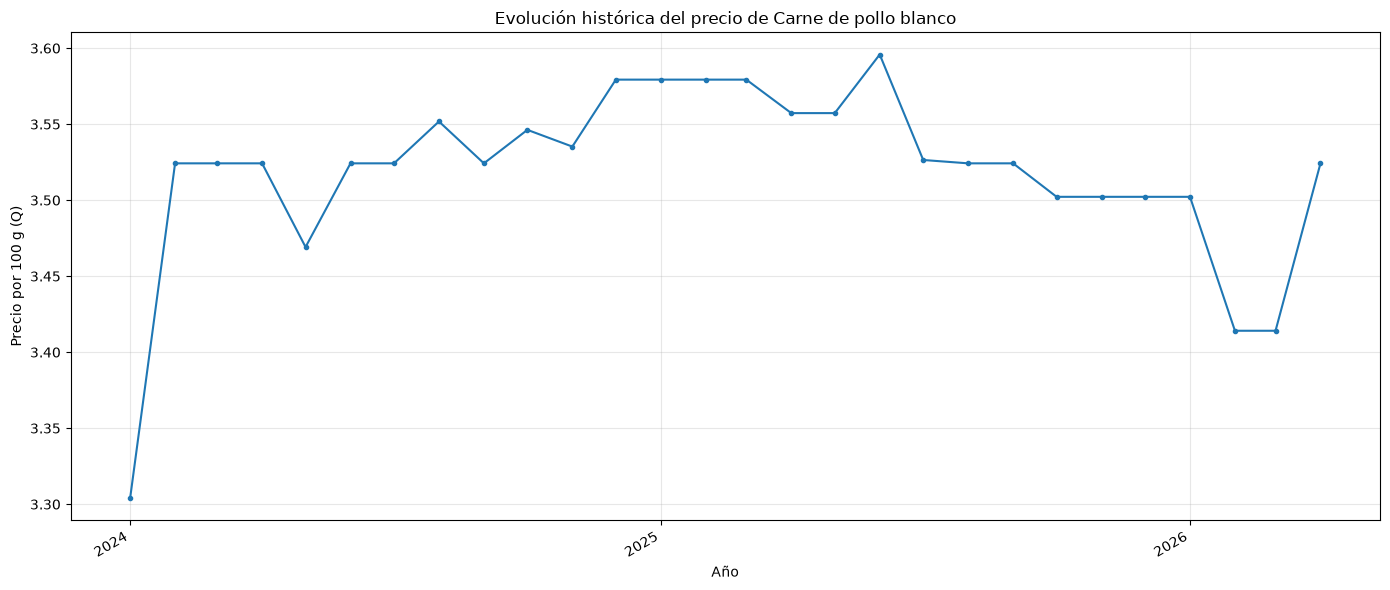

In [54]:
_candidate_2 = catalog.get('carne_de_pollo_blanco')
print(_candidate_2.years_by_region())
fig, ax = _candidate_2.plot_timeline('urbana')

{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


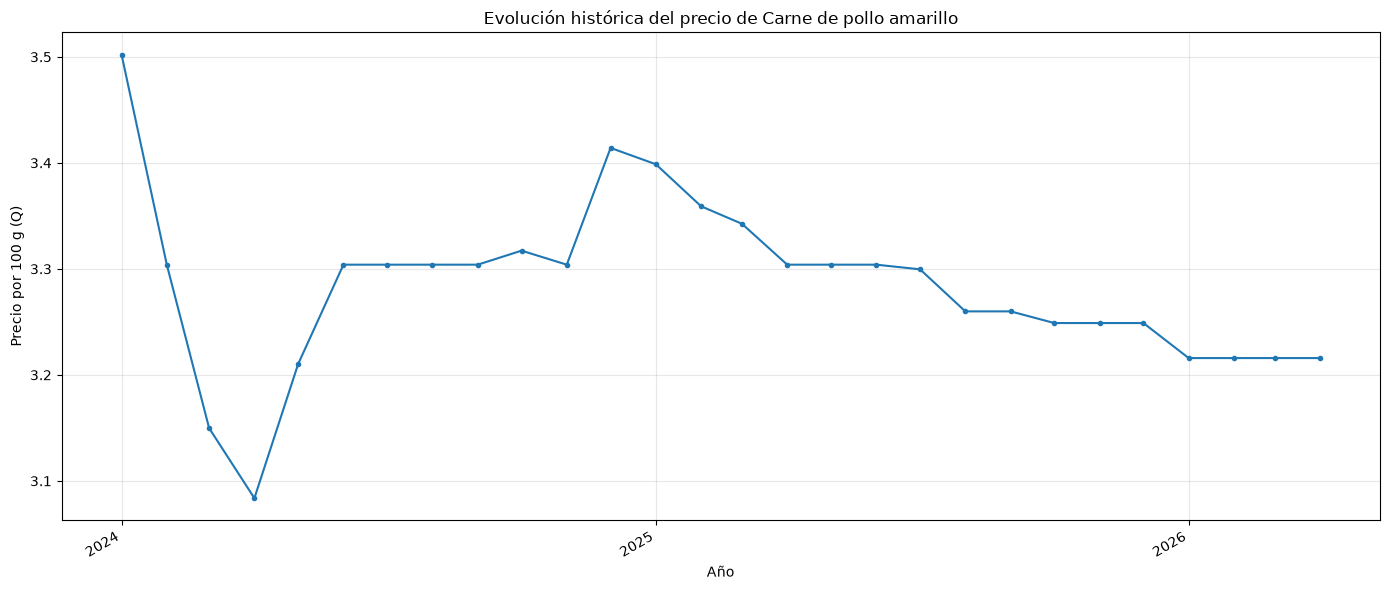

In [55]:
_candidate_2 = catalog.get('carne_de_pollo_amarillo')
print(_candidate_2.years_by_region())
fig, ax = _candidate_2.plot_timeline('urbana')

Por tendencia y mejor continuidad con el precio el alimento que da mejor continuidad a `carne_de_pollo_o_gallina` es `carne_de_pollo_blanco`. 

## Embutidos

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


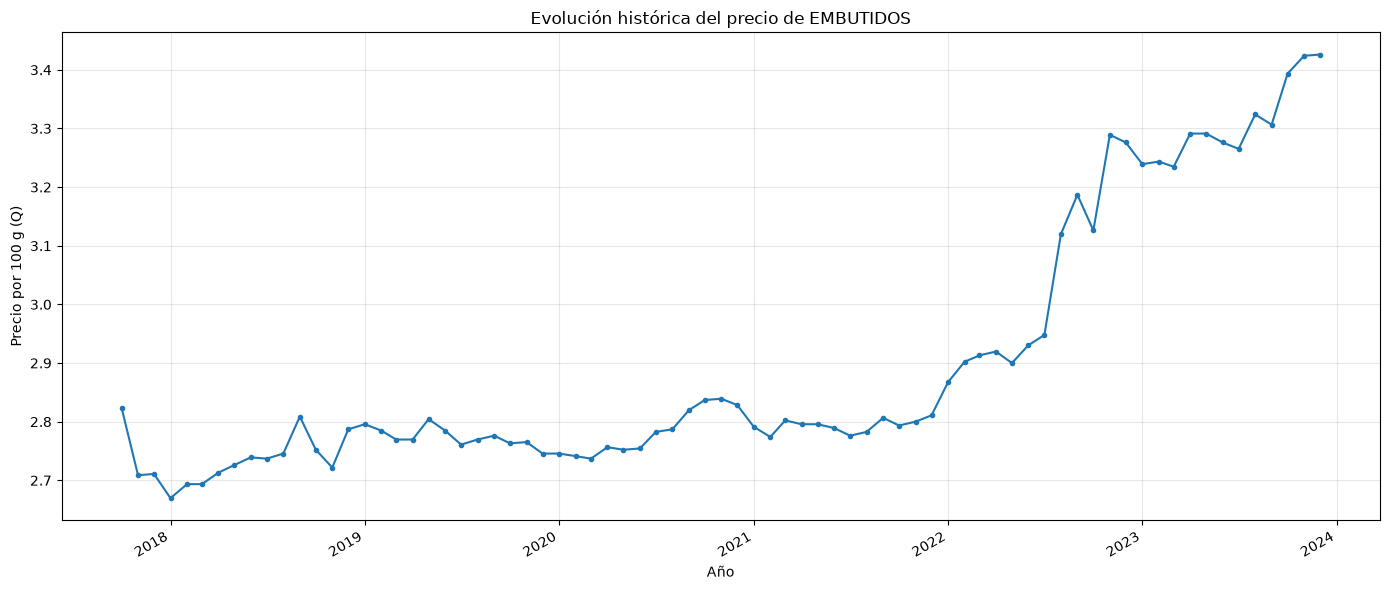

In [56]:
food = catalog.get('embutidos')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [57]:
candidates = [_food for _food in catalog if 'salchicha' in _food.id  or  'jamon' in _food.id  or  'longaniza' in _food.id  or 'chorizo' in _food.id ]
candidates

[Food(id='salchichas_y_productos_similares_de_carne', name='Salchichas y productos similares de carne', category=None, aliases={'Salchichas y productos similares de carne'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC5A390>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBCCA150>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBD12090>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=()),
 Food(id='longanizas_y_chorizos_de_todo_tipo', name='Longanizas y chorizos (de todo tipo)', category=None, aliases={'Longanizas y chorizos (de todo tipo)'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC5A750>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBCCA270>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBD11D30>}, nutrition=None, nutr

{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


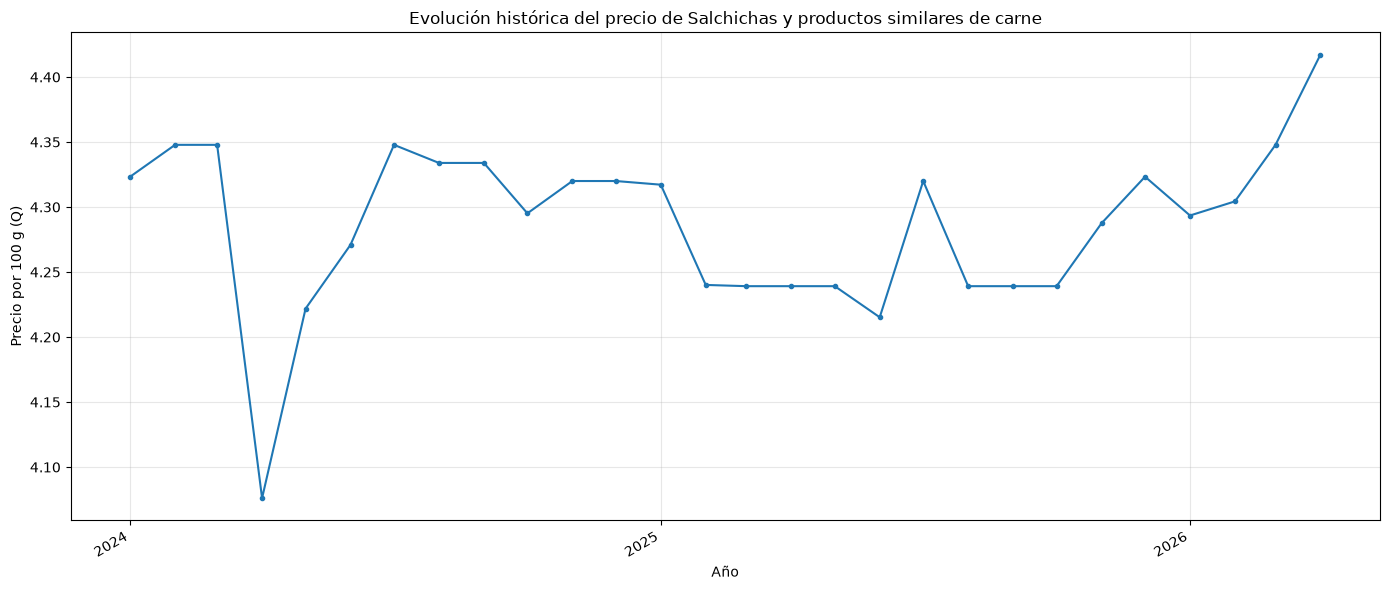

In [58]:
_candidate_2 = catalog.get('salchichas_y_productos_similares_de_carne')
print(_candidate_2.years_by_region())
fig, ax = _candidate_2.plot_timeline('general')

{'general': [], 'rural': [], 'urbana': [2024, 2025, 2026]}


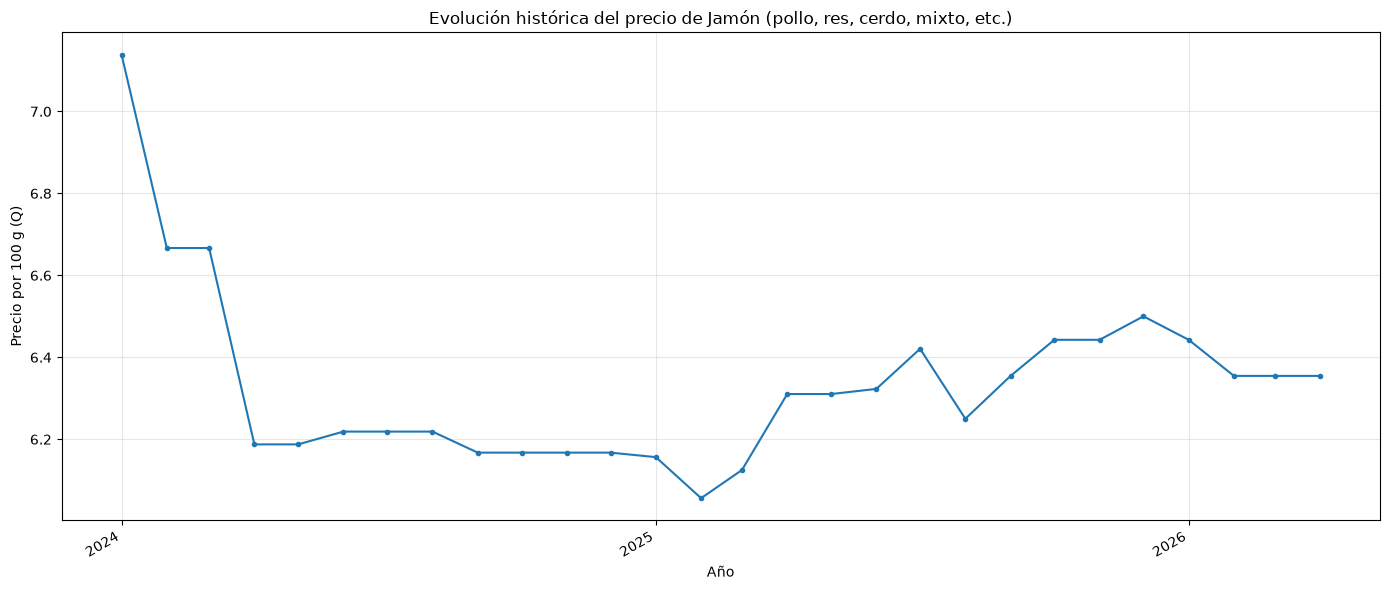

In [59]:
_candidate_2 = catalog.get('jamon_pollo_res_cerdo_mixto_etc')
print(_candidate_2.years_by_region())
fig, ax = _candidate_2.plot_timeline('urbana')

{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


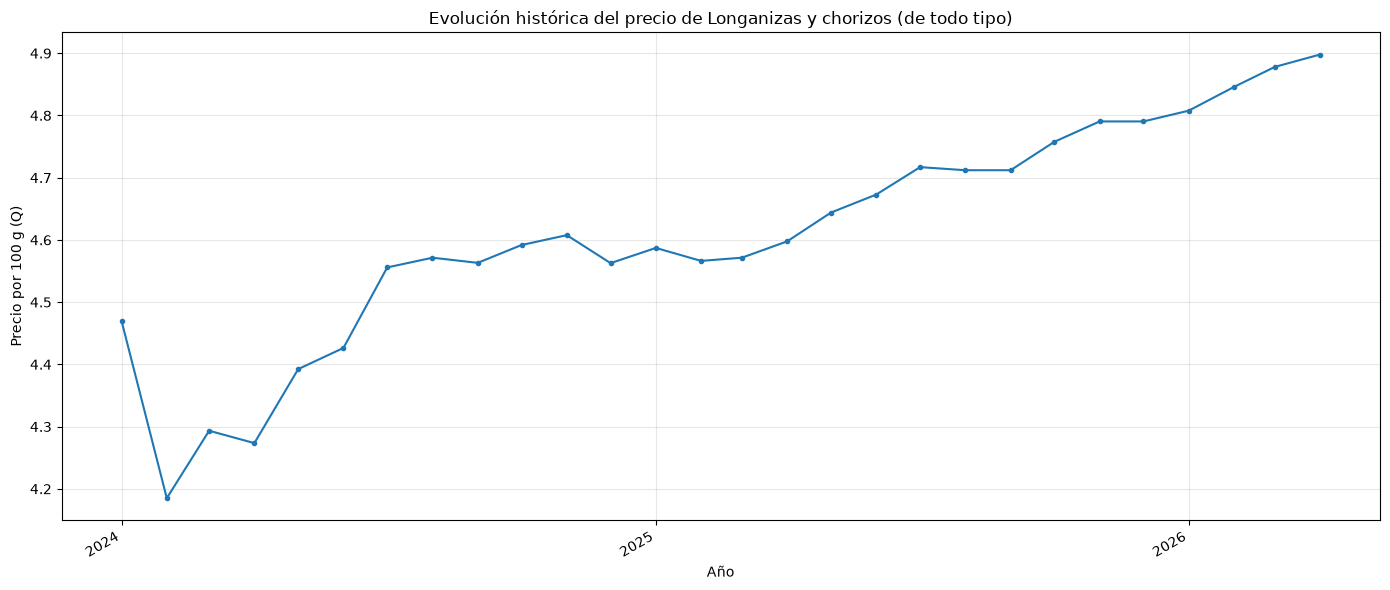

In [60]:
_candidate_2 = catalog.get('longanizas_y_chorizos_de_todo_tipo')
print(_candidate_2.years_by_region())
fig, ax = _candidate_2.plot_timeline('general')

No parece haber una continuidad suficiente de alguno de los embutidos como para dar continuidad. En su lugar se conservan los alimentos por separado. 

Por aclaracion de los informes de CBA 2017 a 2023 (Nota 1 de la tabla Costo mensual de la cansta basica alimentaria -CBA-), indica que por embutidos se refiere unicamente a salchicha, por este motivo explicito se mergea `salchichas_y_productos_similares_de_carne` a `embutidos`. 

## Leche en polvo

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [2024, 2025, 2026], 'urbana': []}


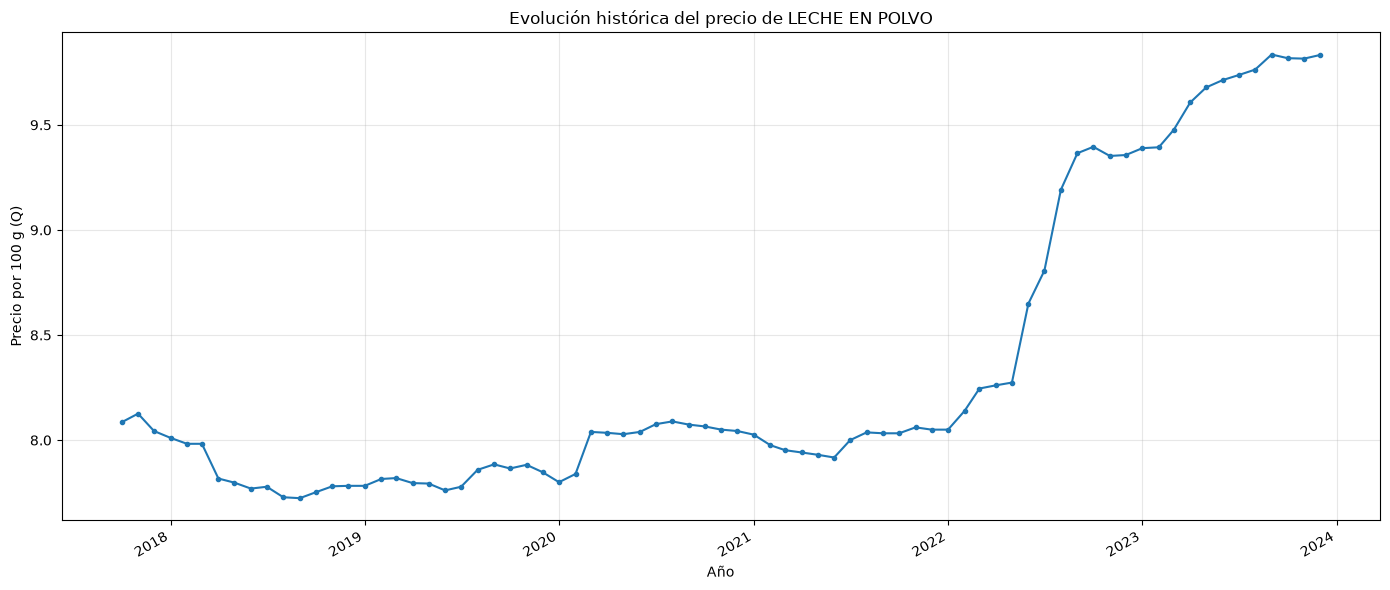

In [61]:
food = catalog.get('leche_en_polvo')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [62]:
candidates = [_food for _food in catalog if 'leche' in _food.id ]
candidates

[Food(id='leche_en_polvo', name='LECHE EN POLVO', category='LÁCTEOS', aliases={'Leche en polvo', 'LECHE EN POLVO'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026F9B5767B0>, 'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC5A330>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=()),
 Food(id='leche_liquida', name='LECHE LIQUIDA', category='LÁCTEOS', aliases={'Leche líquida', 'LECHE LÍQUIDA', 'LECHE LIQUIDA'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026F9B647230>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=()),
 Food(id='leche_entera_liquida_industrializada', name='Leche entera líquida industrializada', category=None, aliases={'Leche entera líquida industrializada'}, price_timelines={'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBCCA3F0>}, nutrition=None, nutrition_match_sco

No parece haber un equivalente de esta leche en CBAs a partir de 2024

## Leche liquida

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


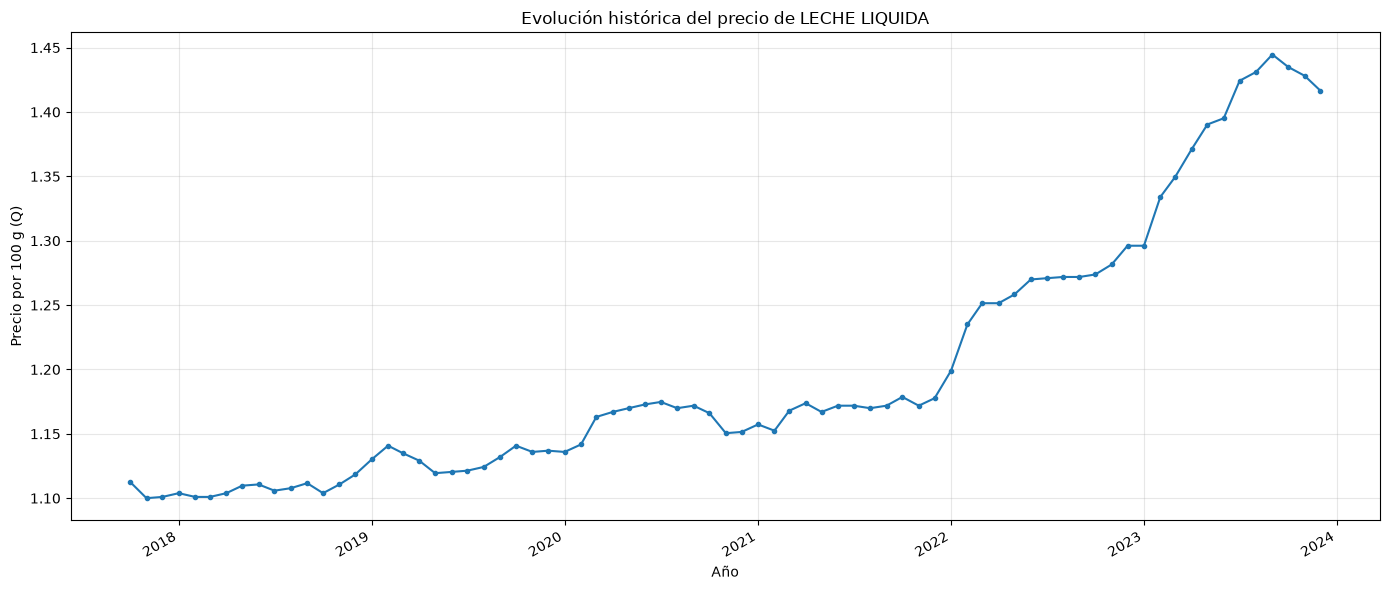

In [63]:
food = catalog.get('leche_liquida')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [64]:
candidates = [_food for _food in catalog if 'leche' in _food.id  and 'liquida' in _food.id ]
candidates.pop(0)
candidates

[Food(id='leche_entera_liquida_industrializada', name='Leche entera líquida industrializada', category=None, aliases={'Leche entera líquida industrializada'}, price_timelines={'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBCCA3F0>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())]

{'general': [], 'rural': [], 'urbana': [2024, 2025, 2026]}


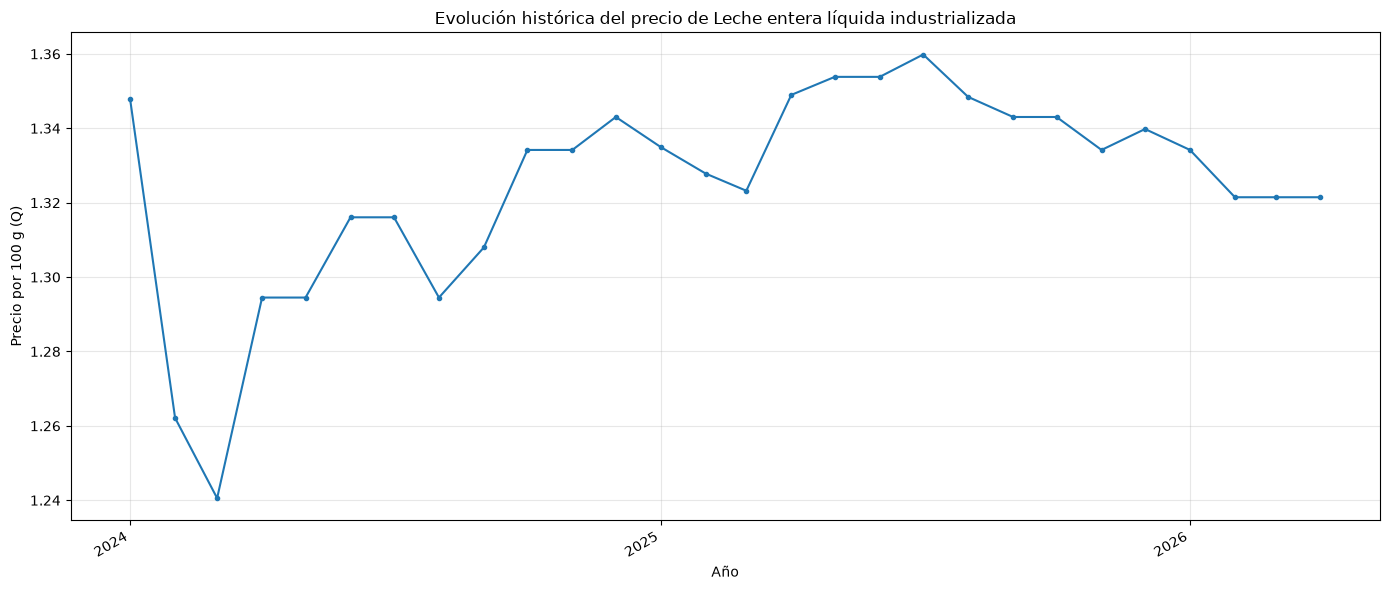

In [65]:
_candidate_1 = catalog.get('leche_entera_liquida_industrializada')
print(_candidate_1.years_by_region())
fig, ax = _candidate_1.plot_timeline('urbana')

Aunque con solo presencia urbana, la tendencia y continuidad de precios tiene un margen aceptable. Por tanto se mergea `leche_entera_liquida_industrializada` a `leche_liquida`. 

## Queso fresco o duro

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


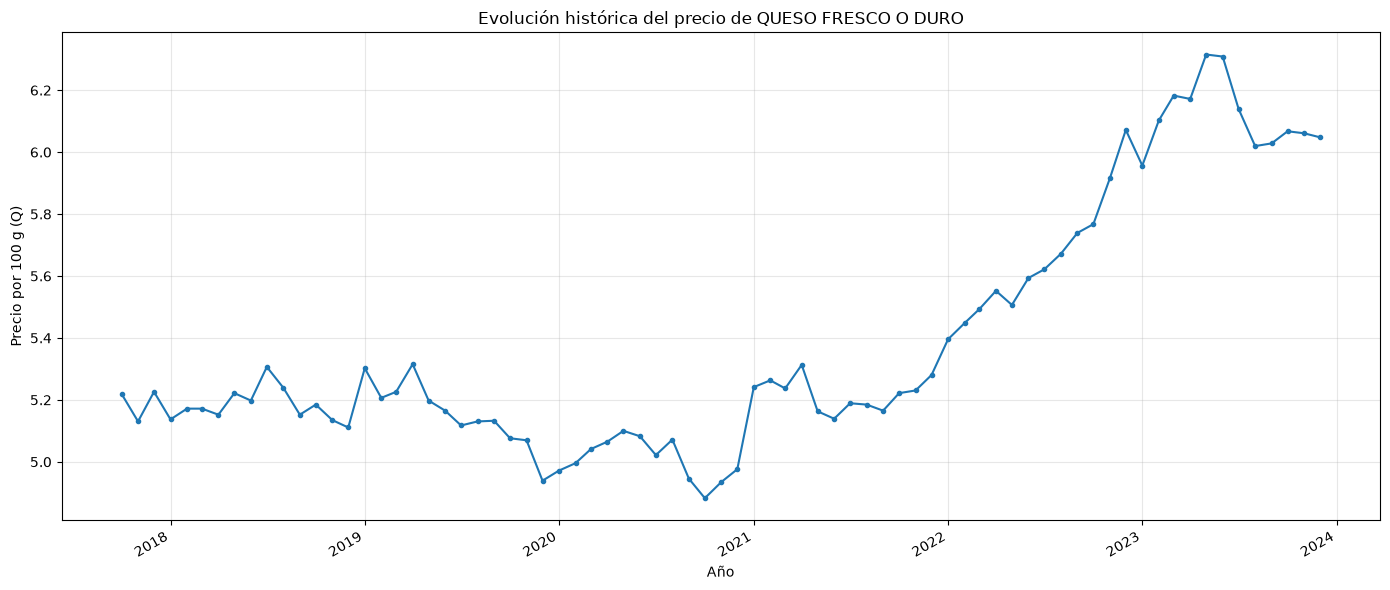

In [66]:
food = catalog.get('queso_fresco_o_duro')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [67]:
candidates = [_food for _food in catalog if 'queso' in _food.id ]
candidates.pop(0)
candidates

[Food(id='queso_fresco_incluye_el_queso_supercremoso', name='Queso fresco (Incluye el queso supercremoso)', category=None, aliases={'Queso fresco (Incluye el queso supercremoso)'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC5A930>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBCCA450>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBD11670>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=()),
 Food(id='salsa_de_tomate_ranchera_queso_etc', name='Salsa de tomate (Ranchera, Queso etc.)', category=None, aliases={'Salsa de tomate (Ranchera, Queso etc.)'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC5B4D0>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBCCAF90>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBB6E8D0>}, nutrition

{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


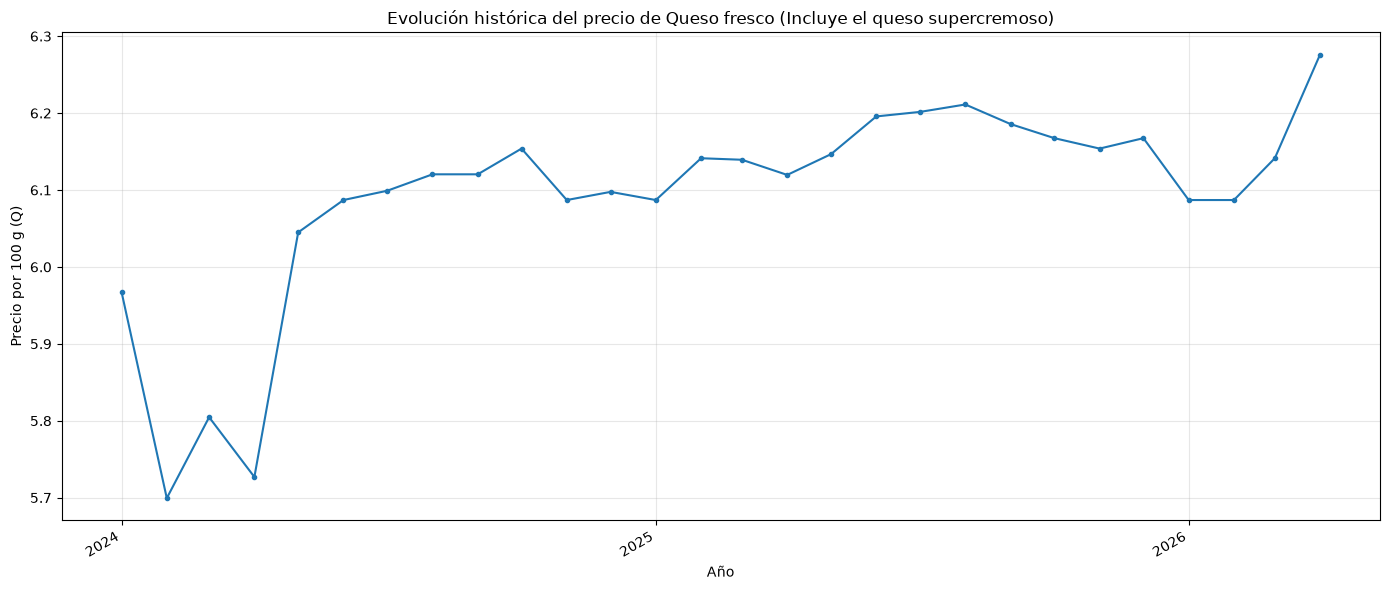

In [68]:
_candidate_1 = catalog.get('queso_fresco_incluye_el_queso_supercremoso')
print(_candidate_1.years_by_region())
fig, ax = _candidate_1.plot_timeline('general')

Se mergea `queso_fresco_incluye_el_queso_supercremoso` a `queso_fresco_o_duro` por continuidad de precio y coincidencia en termino 'queso fresco'

## Crema fresca

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


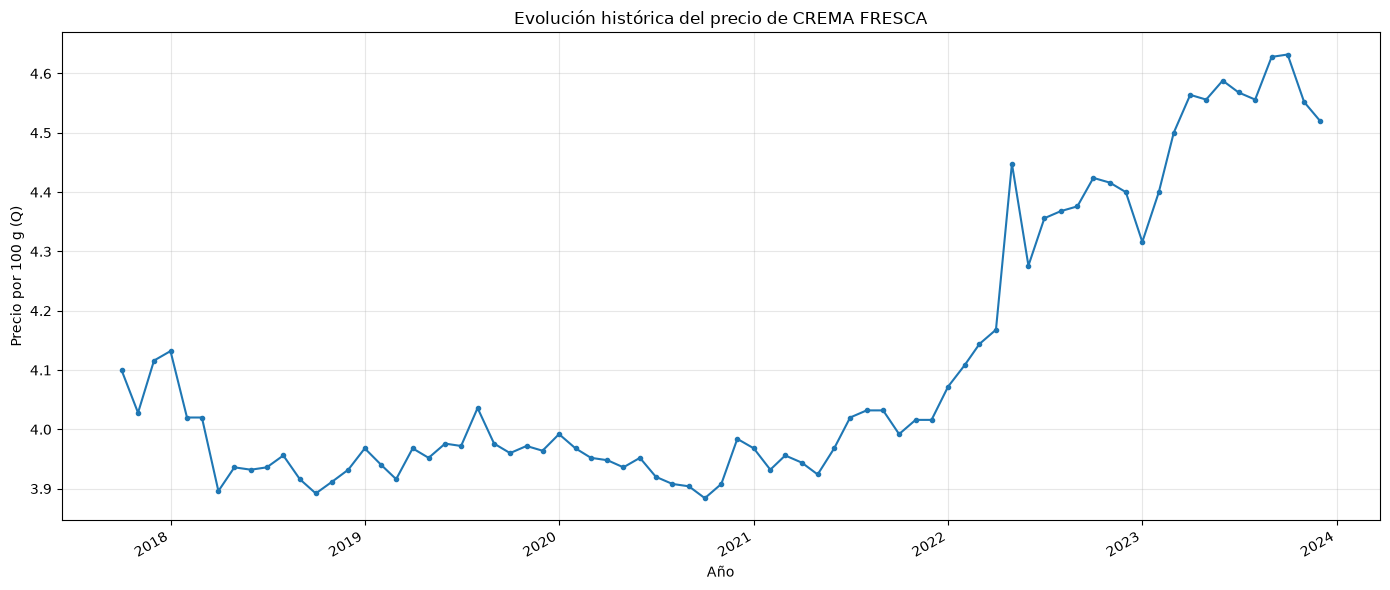

In [69]:
food = catalog.get('crema_fresca')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [70]:
candidates = [_food for _food in catalog if 'crema' in _food.id ]
candidates

[Food(id='crema_fresca', name='CREMA FRESCA', category='LÁCTEOS', aliases={'Crema fresca', 'CREMA FRESCA'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026F9B69C940>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=()),
 Food(id='crema_artesanal', name='Crema artesanal', category=None, aliases={'Crema artesanal'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC5AAB0>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBCCA2D0>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBD119D0>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=()),
 Food(id='crema_industrializada', name='Crema industrializada', category=None, aliases={'Crema industrializada'}, price_timelines={'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBCCA4B0>}, nutrition=None, nutrition_match

{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


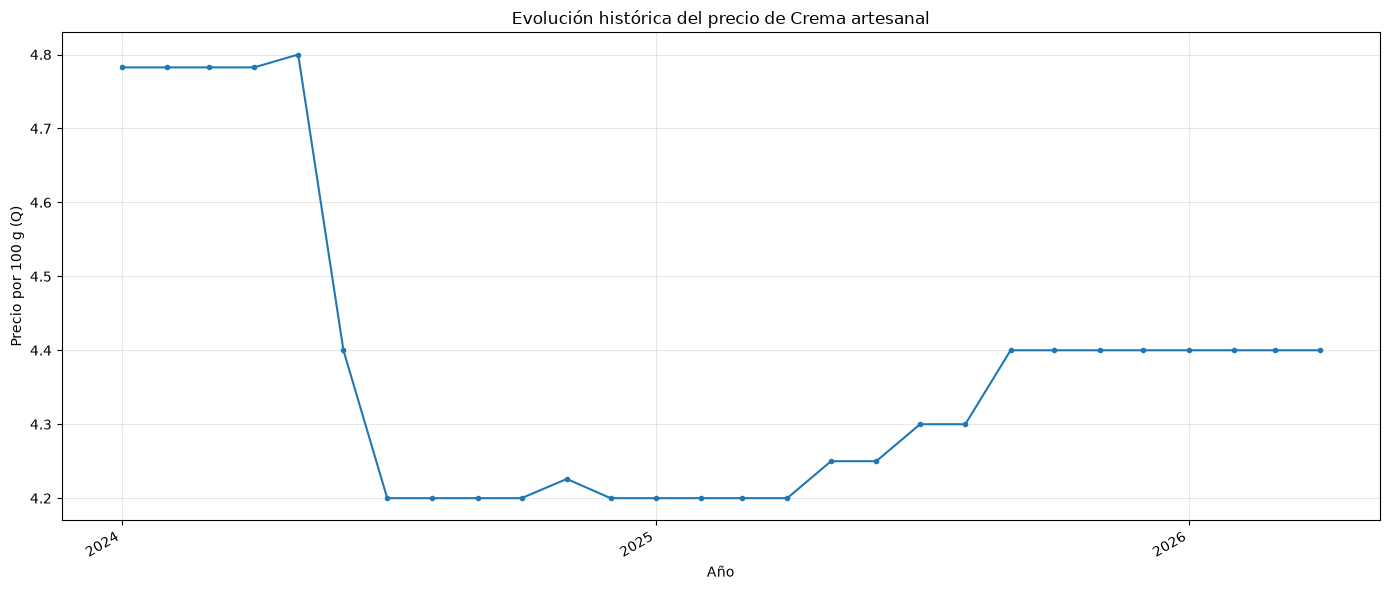

In [71]:
_candidate_1 = catalog.get('crema_artesanal')
print(_candidate_1.years_by_region())
fig, ax = _candidate_1.plot_timeline('general')

{'general': [], 'rural': [], 'urbana': [2024, 2025, 2026]}


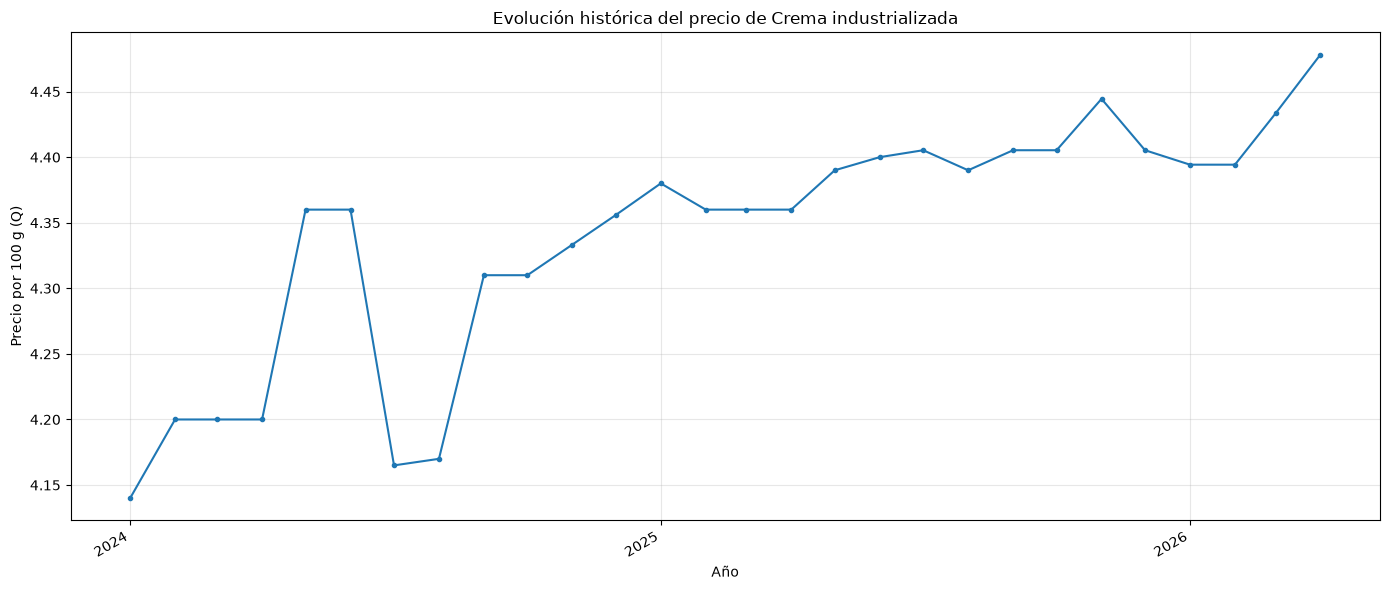

In [72]:
_candidate_1 = catalog.get('crema_industrializada')
print(_candidate_1.years_by_region())
fig, ax = _candidate_1.plot_timeline('urbana')

Dado que la crema artesanal tiene una presencia tanto en la rural como en la urbana y la continuidad de precio difiere menos a la indsutrializada de la crema fresca, se decide mergear `crema_artesanal` a `crema_fresca`

## Huevos de gallina

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


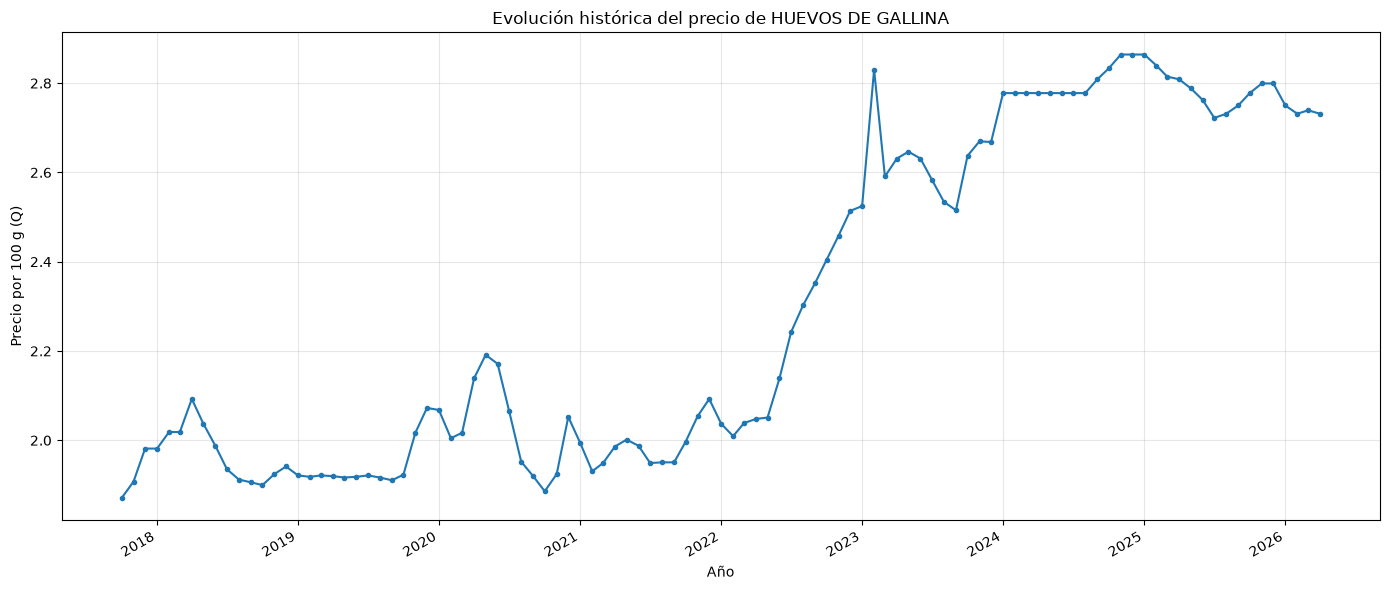

In [73]:
food = catalog.get('huevos_de_gallina')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

Sin cambios requerido por periodo completo. 

## Aceites comesiblte

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


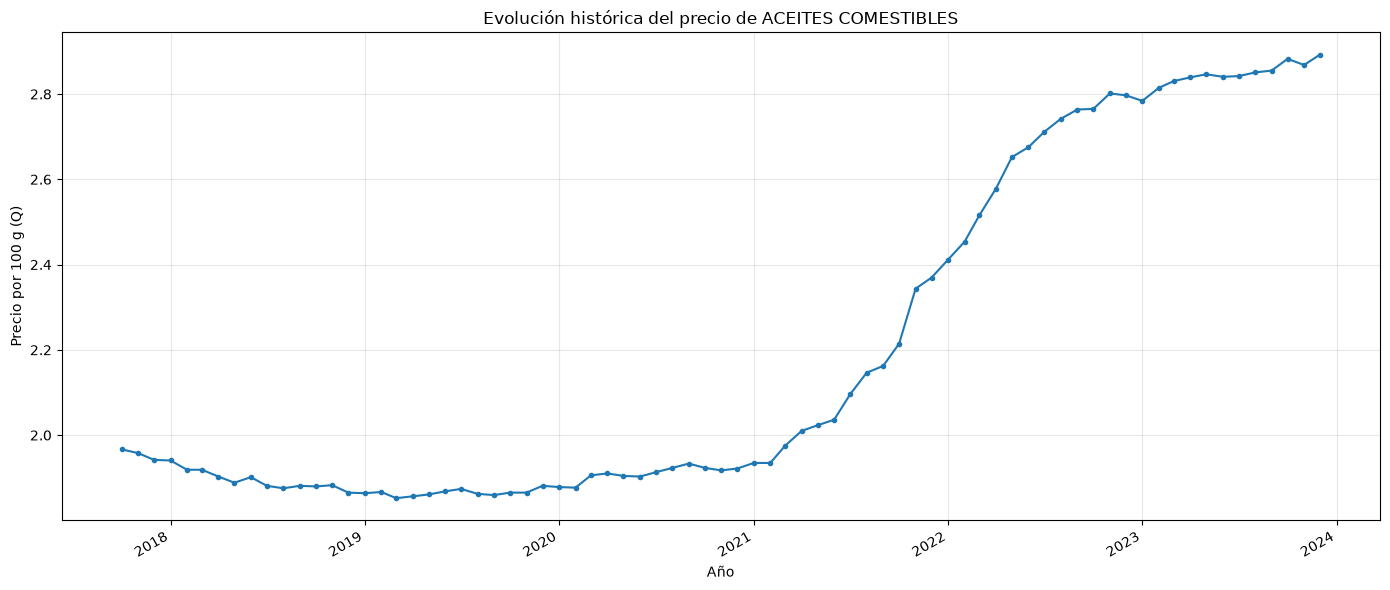

In [74]:
food = catalog.get('aceites_comestibles')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [75]:
candidates = [_food for _food in catalog if 'aceite' in _food.id ]
candidates.pop(0)
candidates

[Food(id='aceite_vegetal_mixtos', name='Aceite vegetal mixtos', category=None, aliases={'Aceite vegetal mixtos'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC5AB10>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBCCA510>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBD11310>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())]

{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


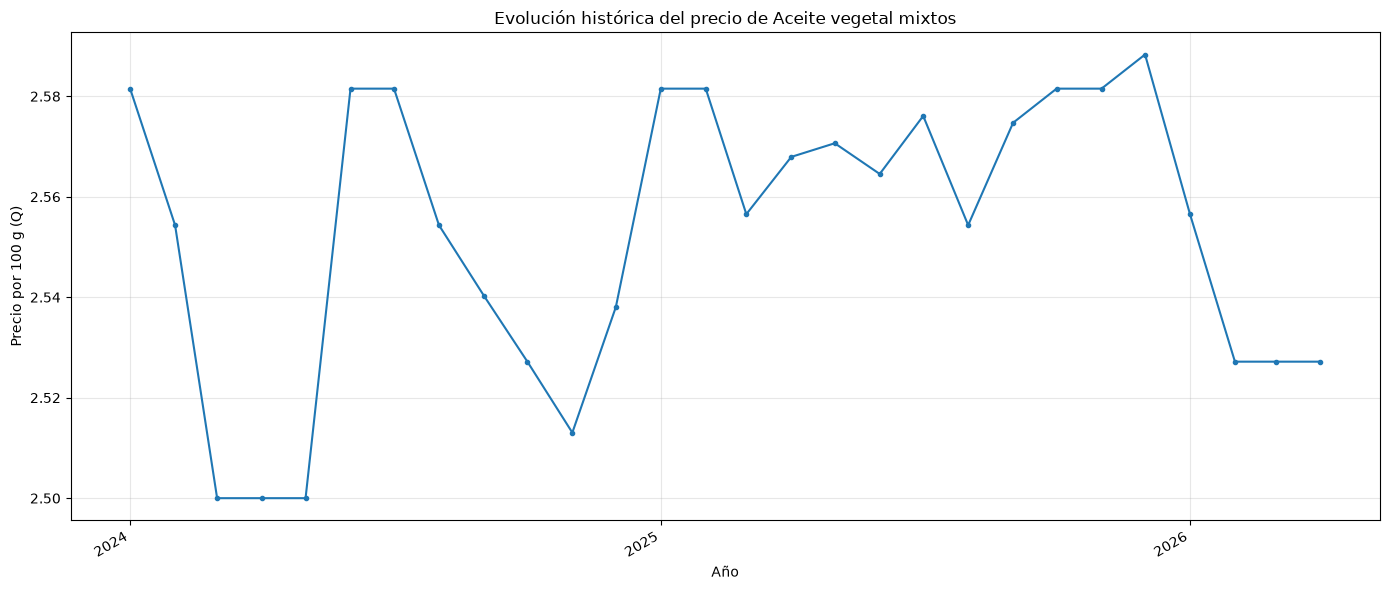

In [76]:
_candidate_1 = catalog.get('aceite_vegetal_mixtos')
print(_candidate_1.years_by_region())
fig, ax = _candidate_1.plot_timeline('general')

El nombre parece corresponder, la continuidad de precios no destaca pero se encuentra en un rango similar, de manera que se mergea `aceite_vegetal_mixtos` a `aceites_comestibles`

## Aguacates

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


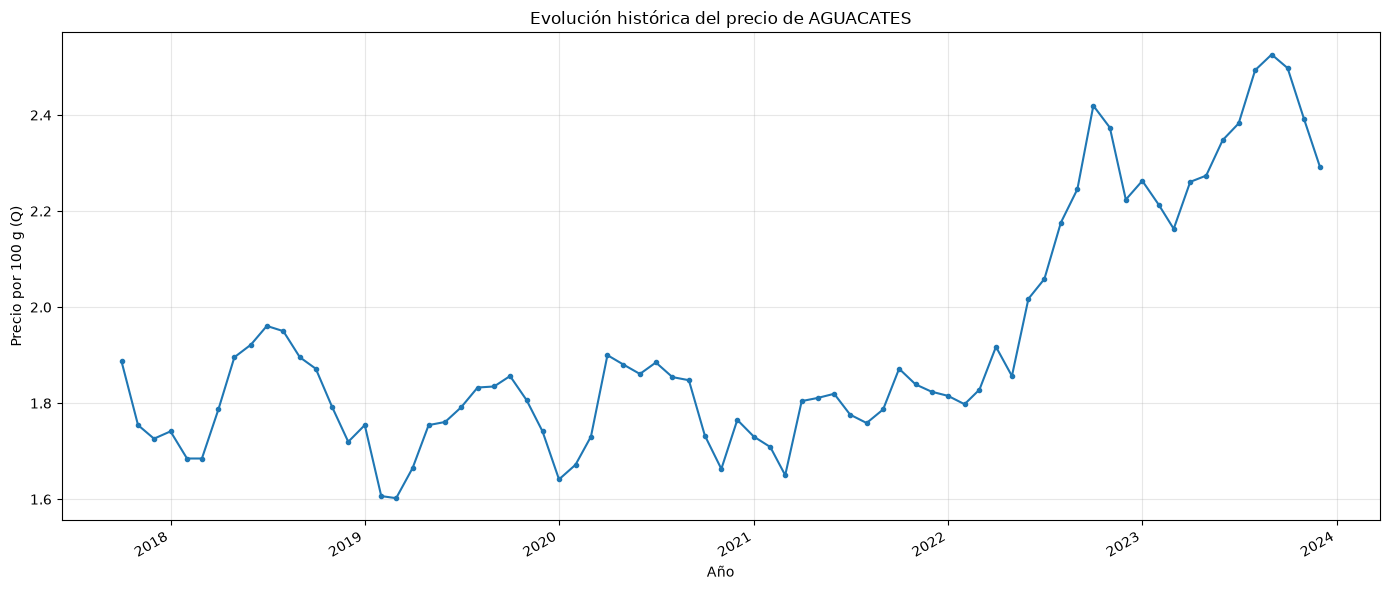

In [77]:
food = catalog.get('aguacates')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [78]:
candidates = [_food for _food in catalog if 'aguacate' in _food.id ]
candidates.pop(0)
candidates

[Food(id='aguacates_frescos', name='Aguacates frescos', category=None, aliases={'Aguacates frescos'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC5AED0>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBCCA570>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBD10C50>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())]

{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


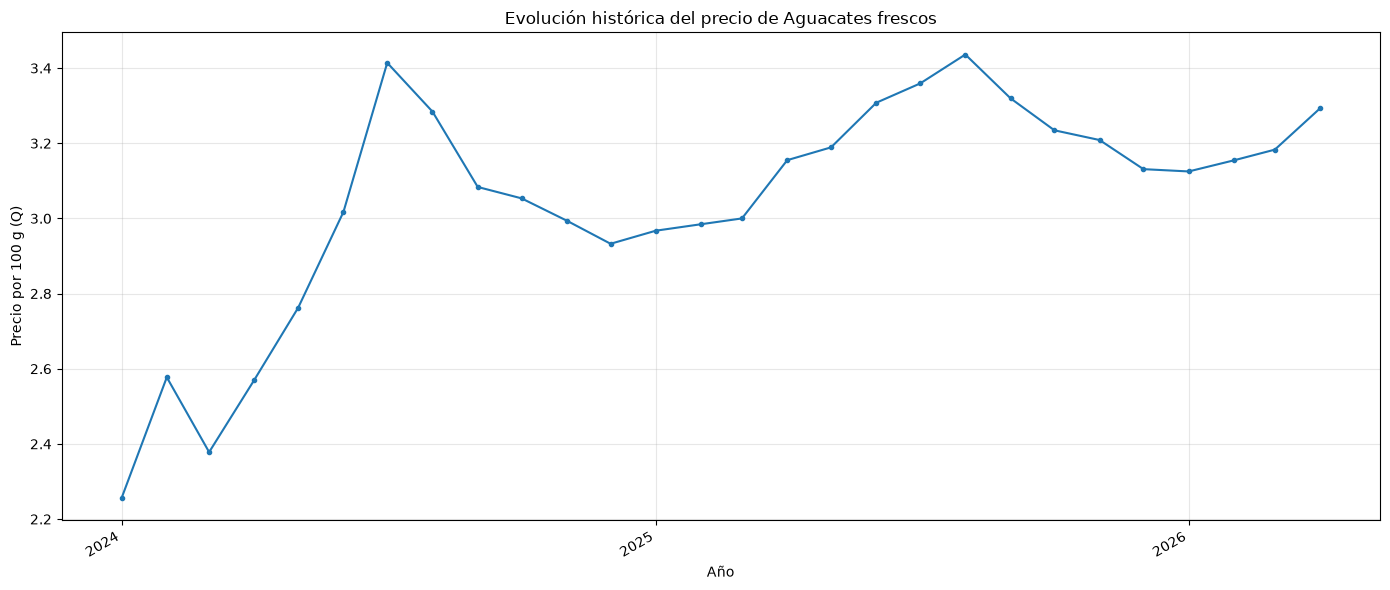

In [79]:
_candidate_1 = catalog.get('aguacates_frescos')
print(_candidate_1.years_by_region())
fig, ax = _candidate_1.plot_timeline('general')

Buena continuidad y rango de precios coherente, el nombre corresponde de igual forma. Se procede a mergear `aguacates_frescos` a `aguacates`. 

## Bananos guineos

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


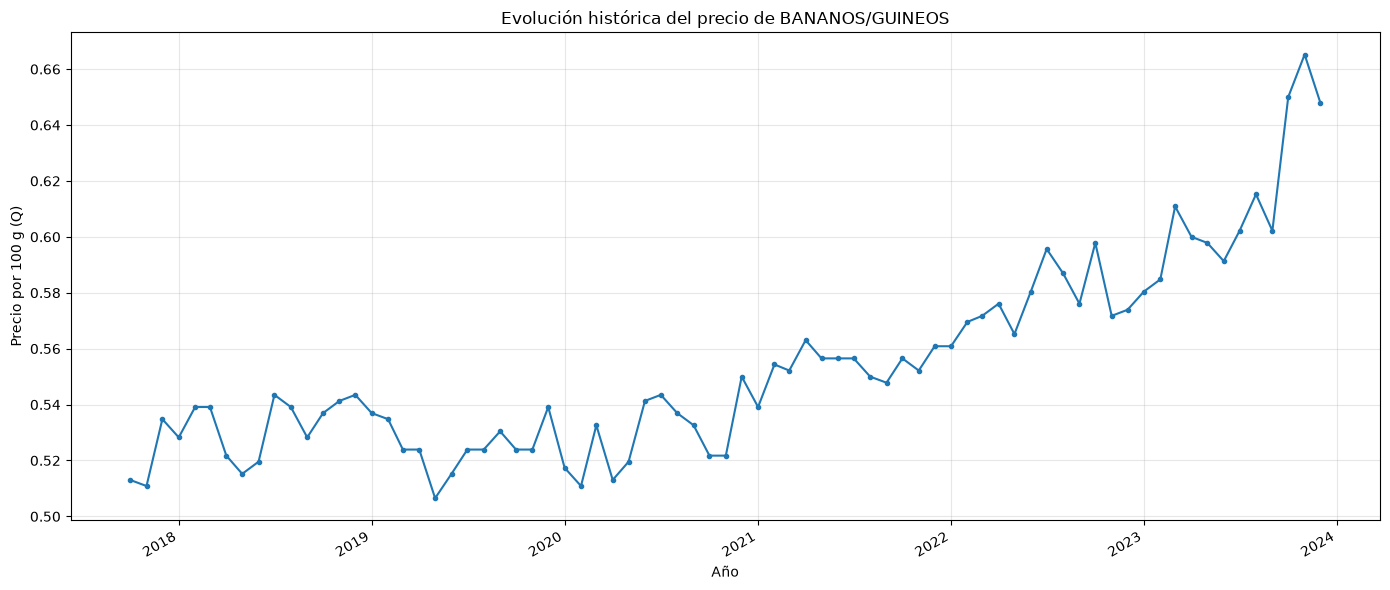

In [80]:
food = catalog.get('bananos_guineos')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [81]:
candidates = [_food for _food in catalog if 'banan' in _food.id or 'guineo' in _food.id]
candidates.pop(0)
candidates

[Food(id='bananos_frescos', name='Bananos frescos', category=None, aliases={'Bananos frescos'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC5AF30>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBCCA390>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBD108F0>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())]

{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


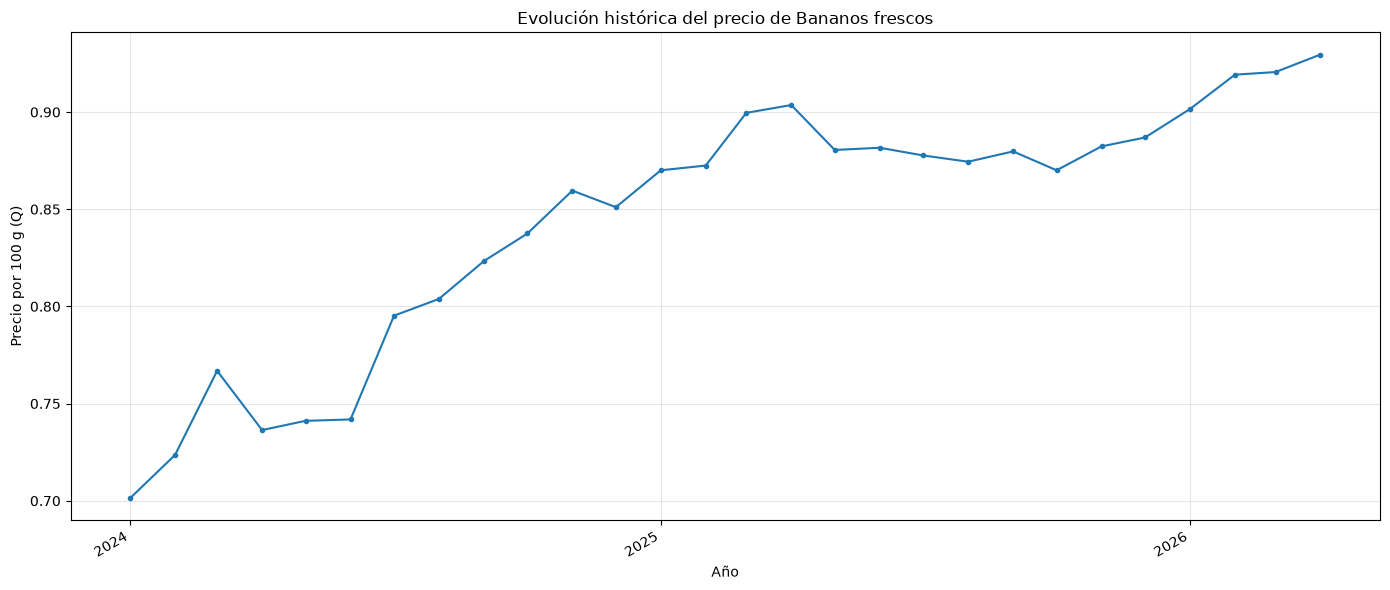

In [82]:
_candidate_1 = catalog.get('bananos_frescos')
print(_candidate_1.years_by_region())
fig, ax = _candidate_1.plot_timeline('general')

Coincide en continuidad de precio y en nombre. Por tanto se mergea `bananos_frescos` a `bananos_guineos`

## Platanos

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


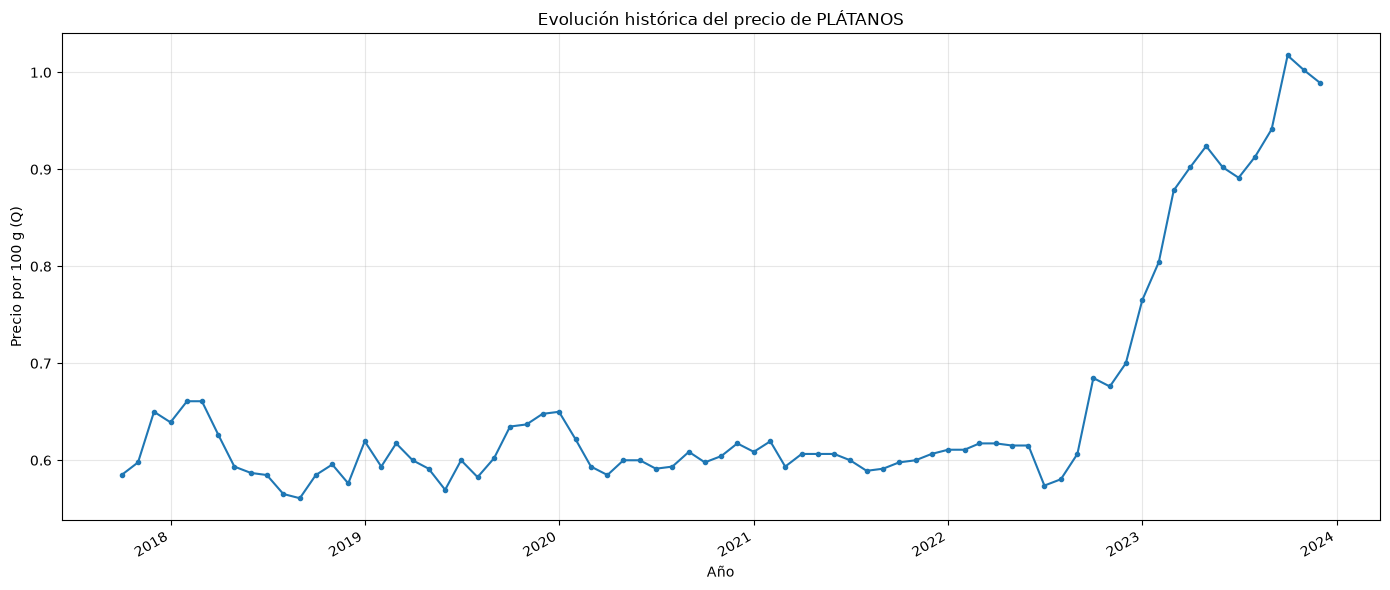

In [83]:
food = catalog.get('platanos')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [84]:
candidates = [_food for _food in catalog if 'platano' in _food.id ]
candidates.pop(0)
candidates

[Food(id='platanos_frescos', name='Plátanos frescos', category=None, aliases={'Plátanos frescos'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC5AF90>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBCCA630>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBD10590>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())]

{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


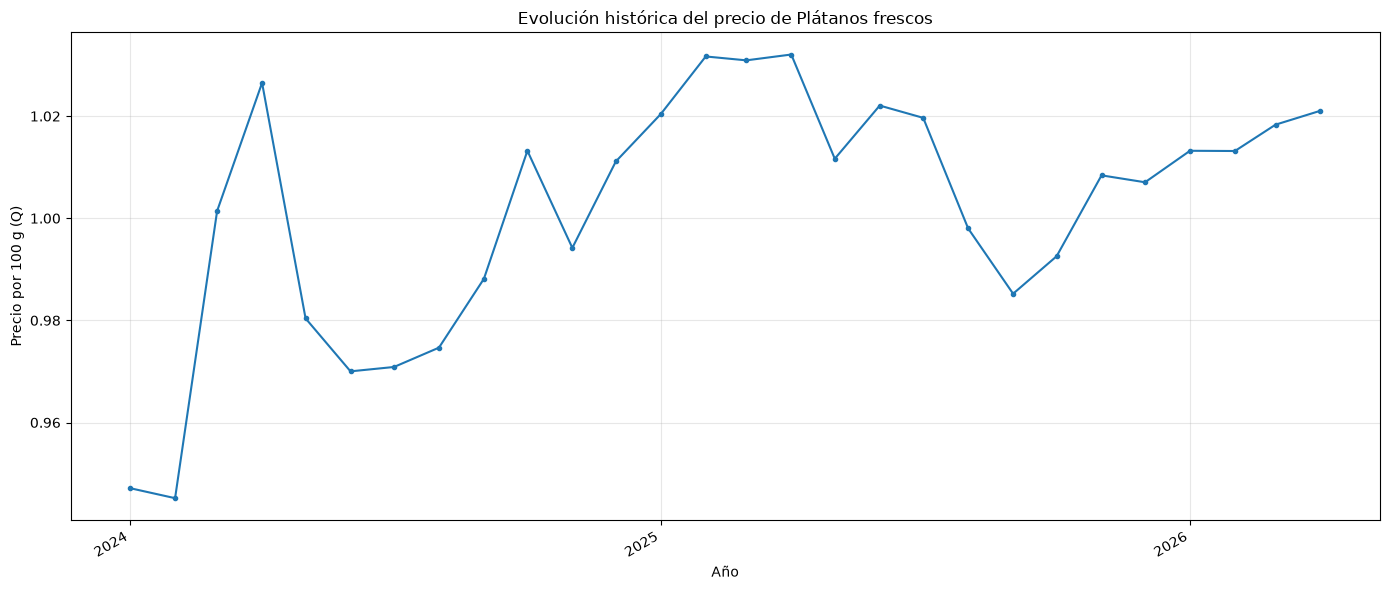

In [85]:
_candidate_1 = catalog.get('platanos_frescos')
print(_candidate_1.years_by_region())
fig, ax = _candidate_1.plot_timeline('general')

Continuidad de precio y nombre corresponden. Por tanto se mergea `platanos_frescos` a `platanos`

## Piñas

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


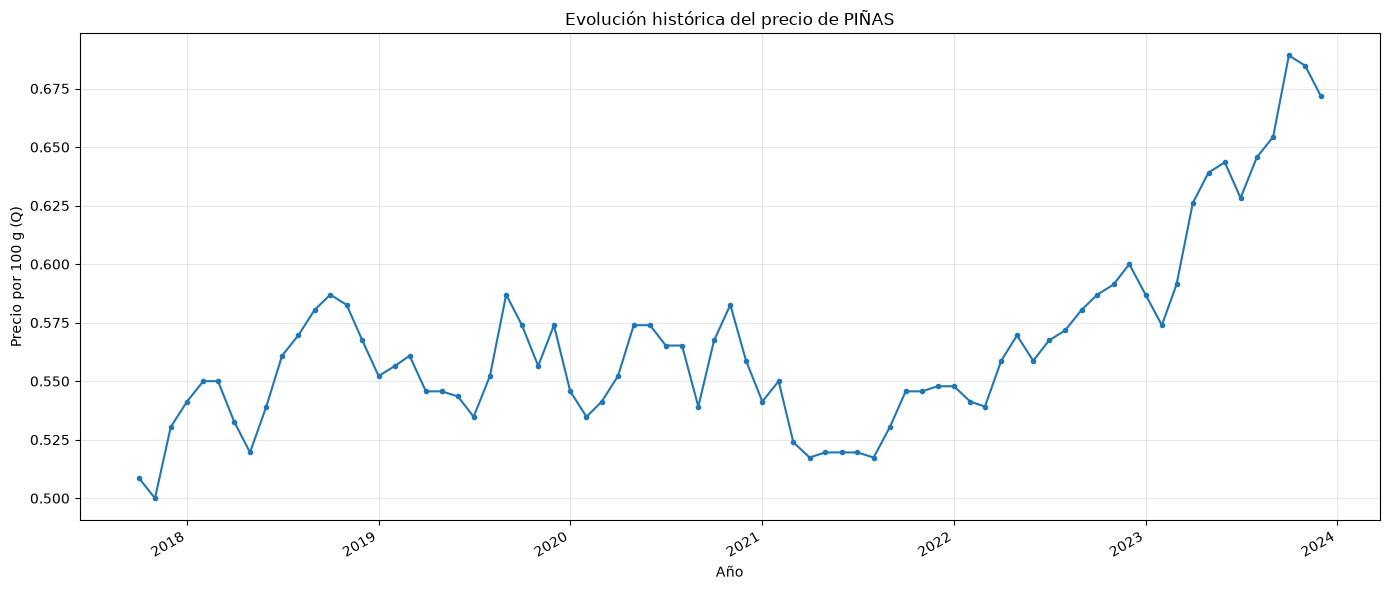

In [86]:
food = catalog.get('pinas')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [87]:
candidates = [_food for _food in catalog if 'piña' in _food.name.lower() ]
#candidates.pop(0)
candidates

[Food(id='pinas', name='PIÑAS', category='FRUTAS', aliases={'Piñas', 'PIÑAS'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026F9B686710>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())]

No hay registros del alimento de 2024 a 2026

## Sandias

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


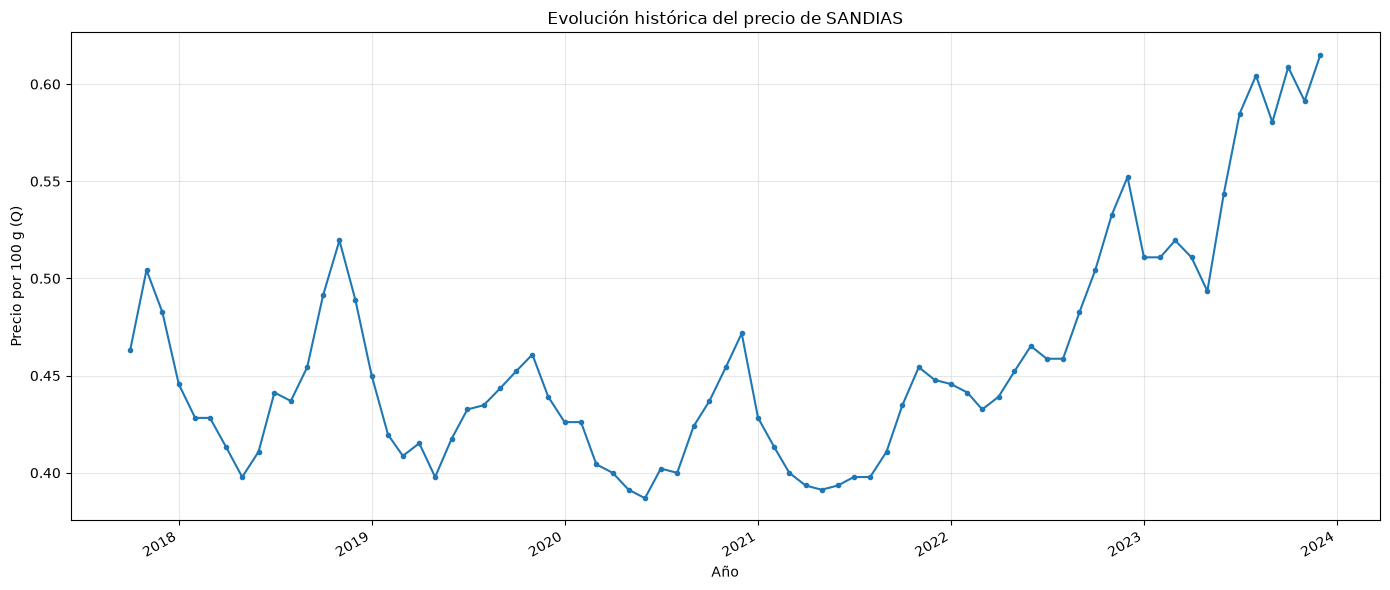

In [88]:
food = catalog.get('sandias')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [89]:
candidates = [_food for _food in catalog if 'sandia' in _food.name.lower() ]
#candidates.pop(0)
candidates

[Food(id='sandias', name='SANDIAS', category='FRUTAS', aliases={'Sandias', 'Sandías', 'SANDIAS', 'SANDÍAS'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026F9B668C20>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())]

No hay registros del alimento de 2024 a 2026

## Tomate

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


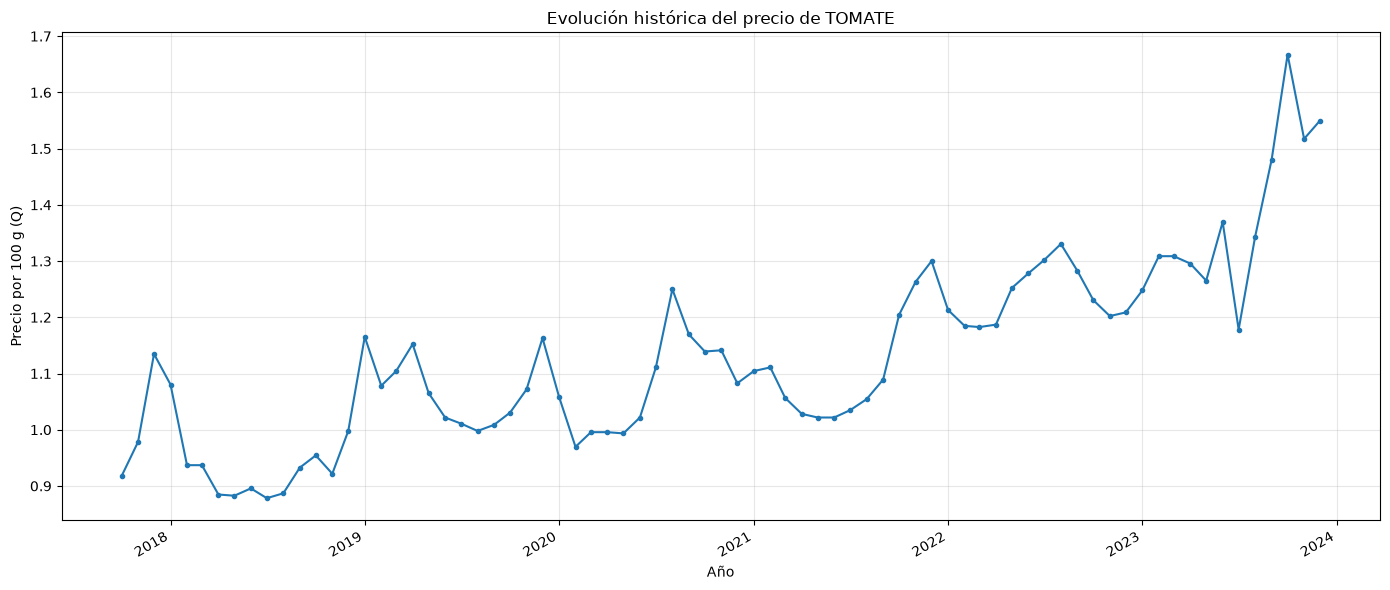

In [90]:
food = catalog.get('tomate')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [91]:
candidates = [_food for _food in catalog if 'tomat' in _food.name.lower() ]
#candidates.pop(0)
candidates

[Food(id='tomate', name='TOMATE', category='VERDURAS/HORTALIZAS', aliases={'Tomate', 'TOMATE'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026F9B6788D0>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=()),
 Food(id='tomate_fresco', name='Tomate fresco', category=None, aliases={'Tomate fresco'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC5A990>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBCCA5D0>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBD10050>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=()),
 Food(id='salsa_de_tomate_ranchera_queso_etc', name='Salsa de tomate (Ranchera, Queso etc.)', category=None, aliases={'Salsa de tomate (Ranchera, Queso etc.)'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC5B4D0>, 'urb

{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


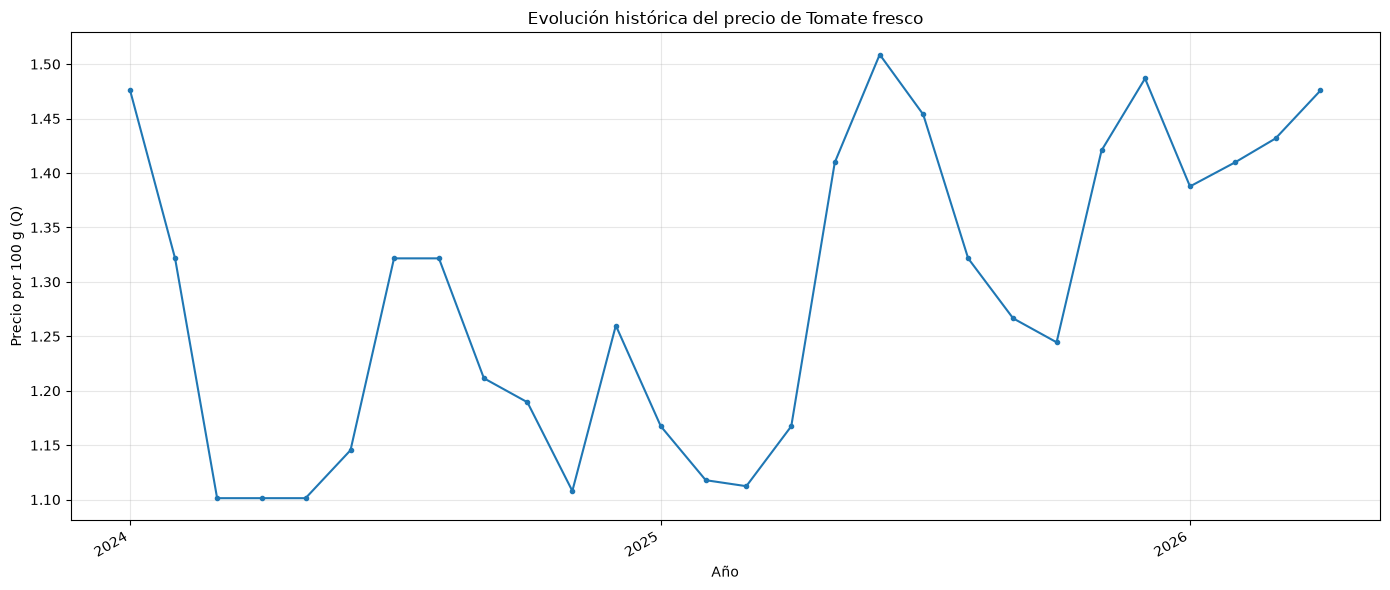

In [92]:
_candidate_1 = catalog.get('tomate_fresco')
print(_candidate_1.years_by_region())
fig, ax = _candidate_1.plot_timeline('general')

Continuidad de precio y nombre corresponden. Por tanto se mergea `tomate_fresco` a `tomate`

## Guisquil

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


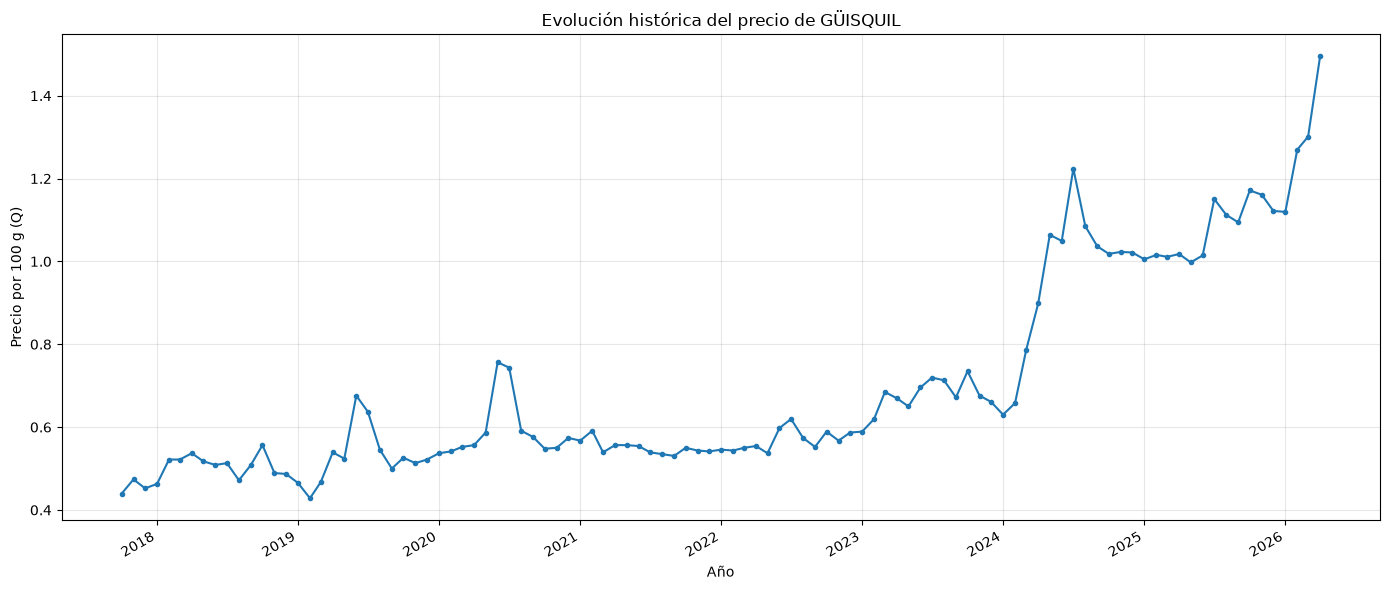

In [93]:
food = catalog.get('guisquil')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

Periodo completo, sin cambios adicionales necesarios

## Cebolla blanca sin tallo

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


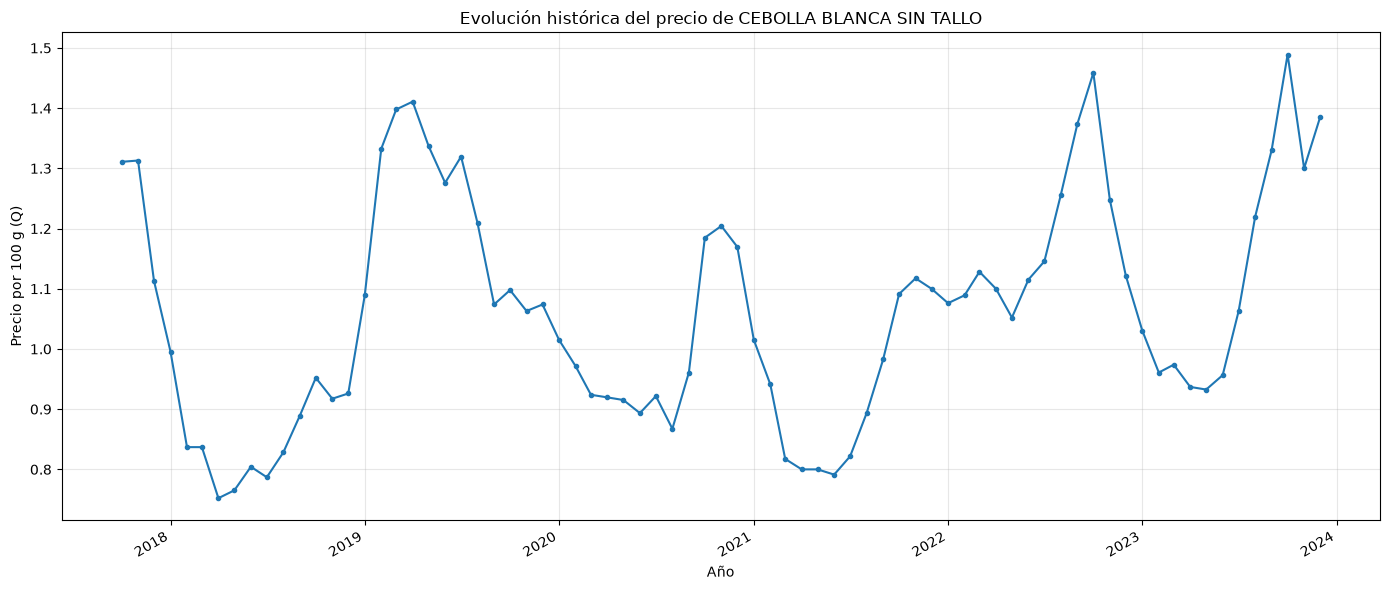

In [94]:
food = catalog.get('cebolla_blanca_sin_tallo')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [95]:
candidates = [_food for _food in catalog if 'cebolla' in _food.name.lower() ]
#candidates.pop(0)
candidates

[Food(id='cebolla_blanca_sin_tallo', name='CEBOLLA BLANCA SIN TALLO', category='VERDURAS/HORTALIZAS', aliases={'CEBOLLA BLANCA SIN TALLO', 'Cebolla blanca sin tallo'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026F9B63BB60>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=()),
 Food(id='cebollas', name='Cebollas', category=None, aliases={'Cebollas'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC5B2F0>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBCCABD0>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBB6EB70>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())]

{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


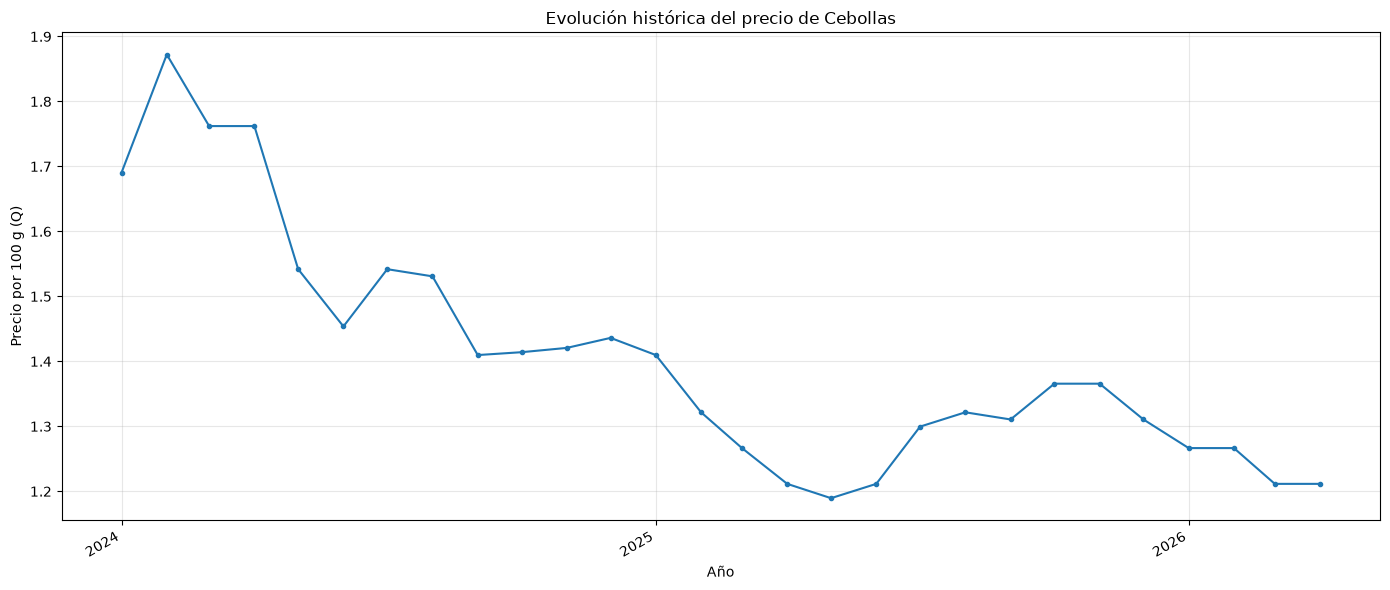

In [96]:
_candidate_1 = catalog.get('cebollas')
print(_candidate_1.years_by_region())
fig, ax = _candidate_1.plot_timeline('general')

Contiuidad coherente, nombre correspodniente y rango de precios simialres entre ambos periosdos. Se proceder a mergear `cebollas` a `cebolla_blanca_sin_tallo`

## Papas

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


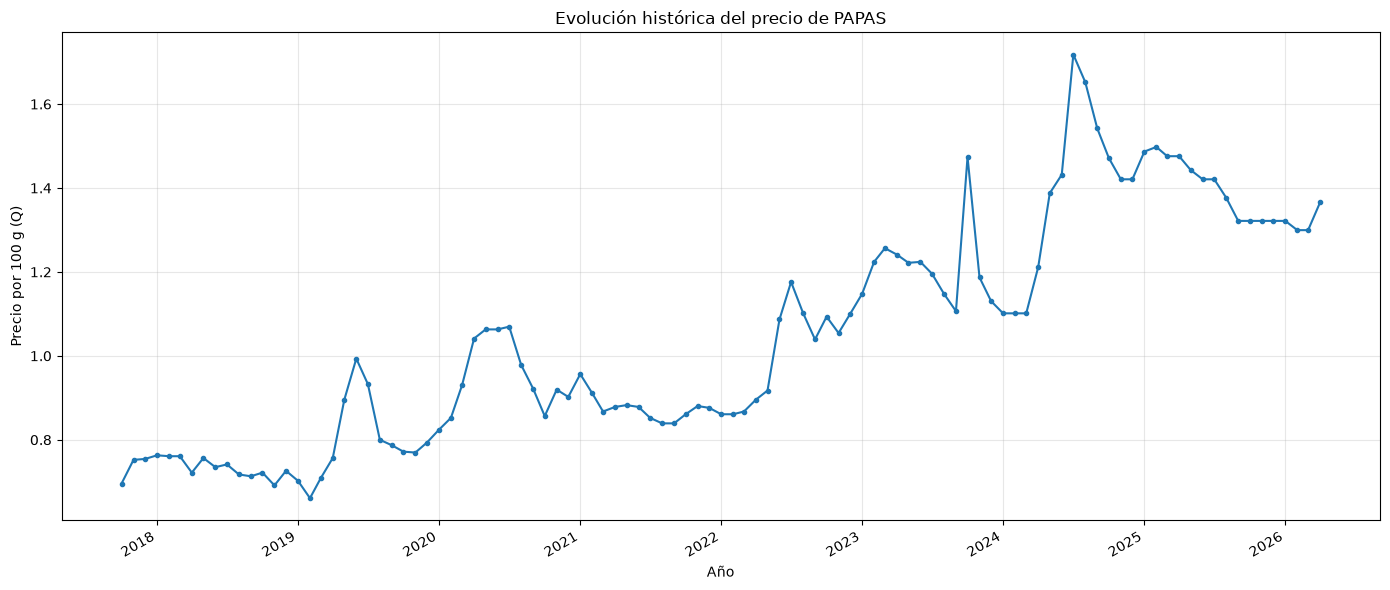

In [97]:
food = catalog.get('papas')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

Periodo completo, sin cambios requeridos

## Hierbas

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


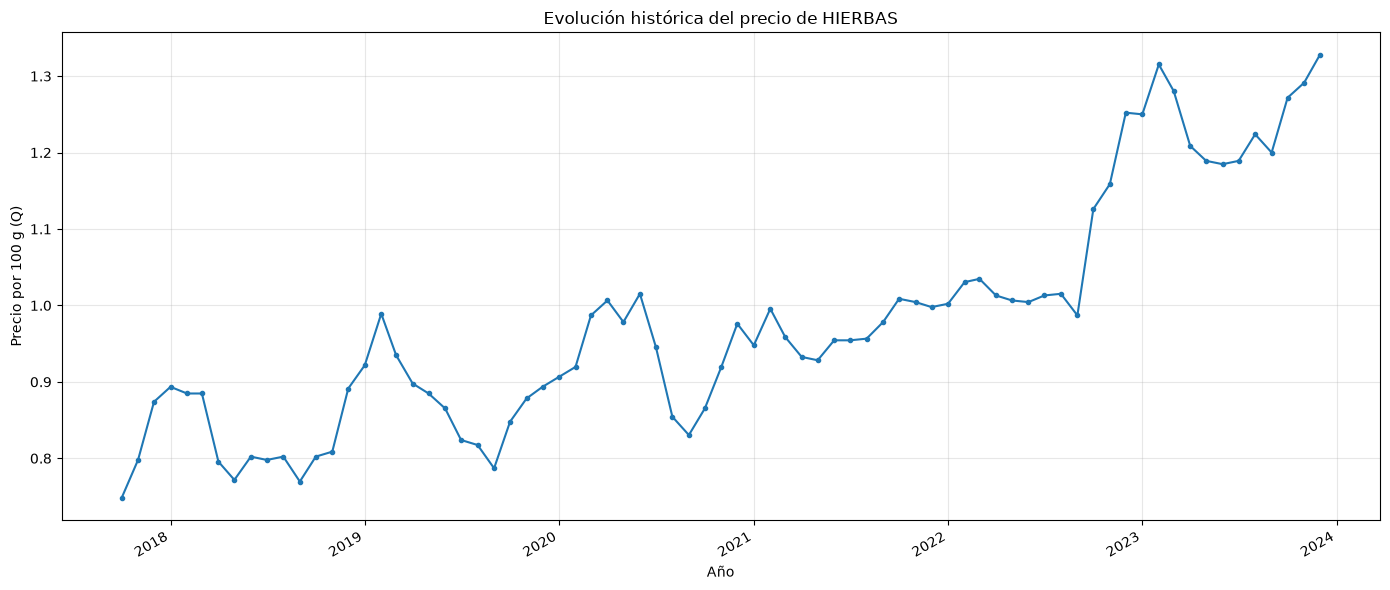

In [98]:
food = catalog.get('hierbas')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [99]:
candidates = [_food for _food in catalog if 'hierba' in _food.name.lower() ]
#candidates.pop(0)
candidates

[Food(id='hierbas', name='HIERBAS', category='VERDURAS/HORTALIZAS', aliases={'HIERBAS', 'Hierbas'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026F9B660C50>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=()),
 Food(id='cilantro_perejil_y_hierbabuena', name='Cilantro, perejil y hierbabuena', category=None, aliases={'Cilantro, perejil y hierbabuena'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC5B170>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBCCAAB0>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBD10110>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=()),
 Food(id='macuy_hierba_mora_quilete', name='Macuy/Hierba mora/Quilete', category=None, aliases={'Macuy/Hierba mora/Quilete'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0

{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


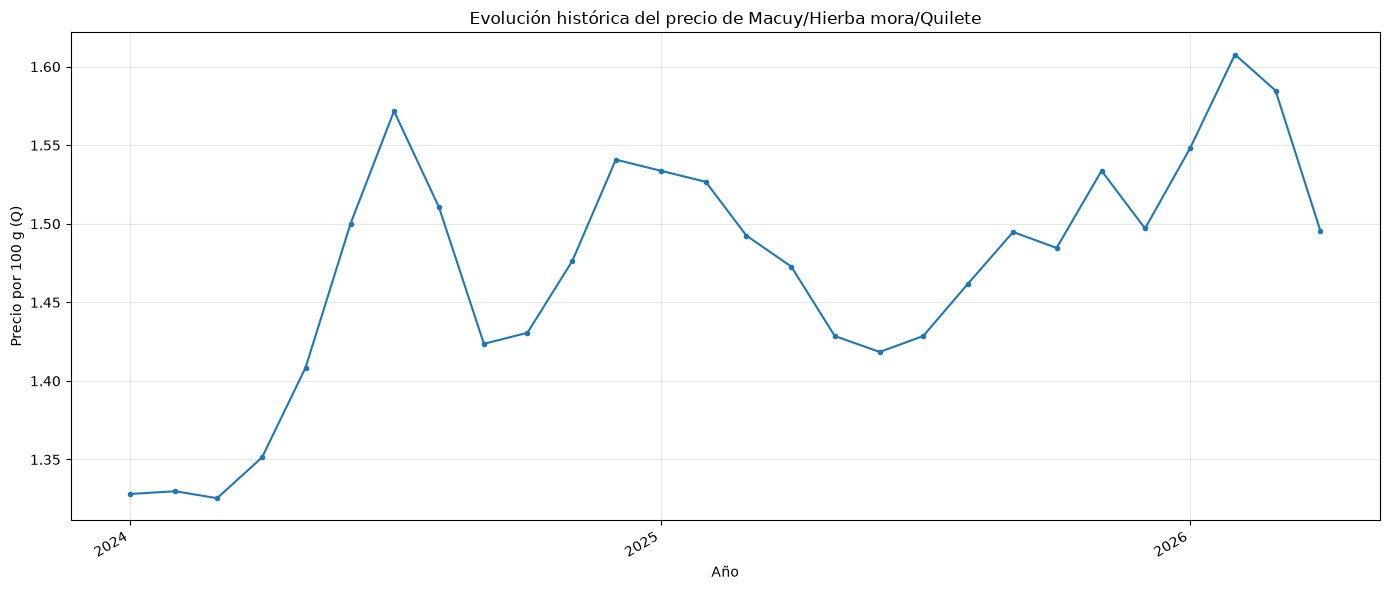

In [100]:
_candidate_1 = catalog.get('macuy_hierba_mora_quilete')
print(_candidate_1.years_by_region())
fig, ax = _candidate_1.plot_timeline('general')

Los informes de CBA 2017 a 2023 explicitamente indican que por hierbas en cuanto a precio al precio cotizado para el macuy (Hierbamora). Ademas que la continuidad del precio concuerda. Se mergea `macuy_hierba_mora_quilete` a `hierbas`.

## Frijol

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


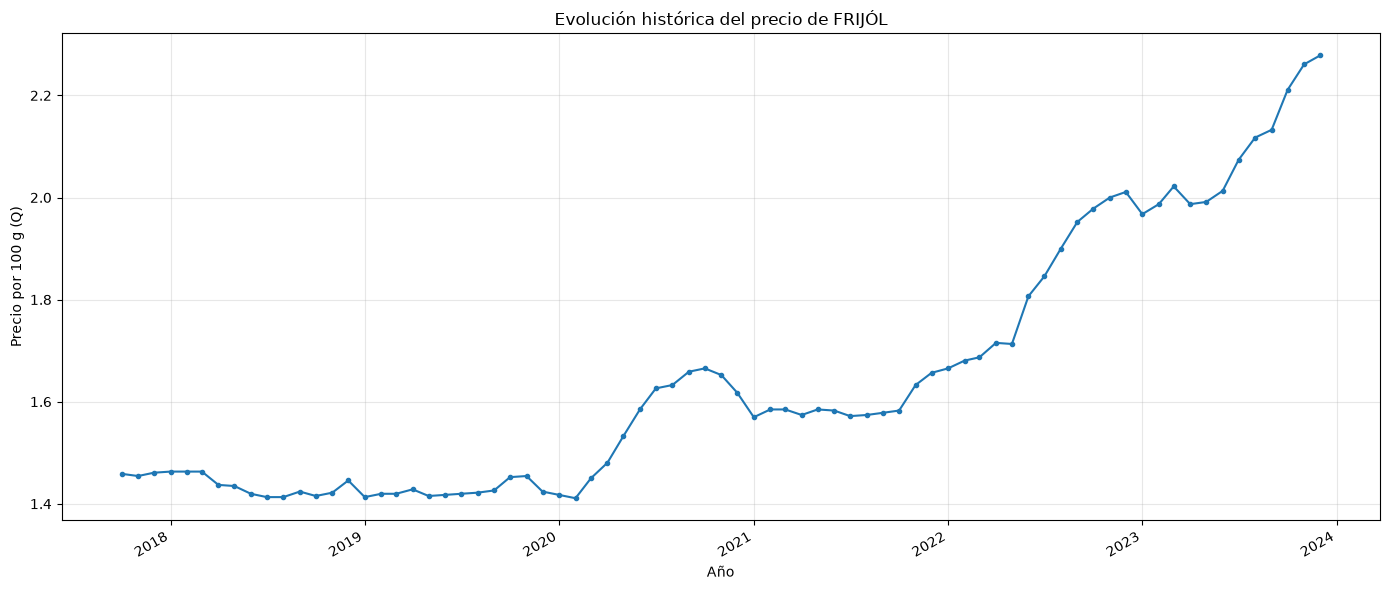

In [101]:
food = catalog.get('frijol')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [102]:
candidates = [_food for _food in catalog if 'frijol' in _food.name.lower() ]
#candidates.pop(0)
candidates

[Food(id='frijoles_negros_secos', name='Frijoles negros, secos', category=None, aliases={'Frijoles negros, secos'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC5AA50>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBCCACF0>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBB6F7D0>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=()),
 Food(id='frijoles_preparados_procesados_y_condimentados_enlatados_o_empaquetados', name='Frijoles preparados, procesados y condimentados (enlatados o empaquetados)', category=None, aliases={'Frijoles preparados, procesados y condimentados (enlatados o empaquetados)'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC5A450>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBCCAC30>, 'general': <canasta_inteligente.domain.prices.PriceTimeli

{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


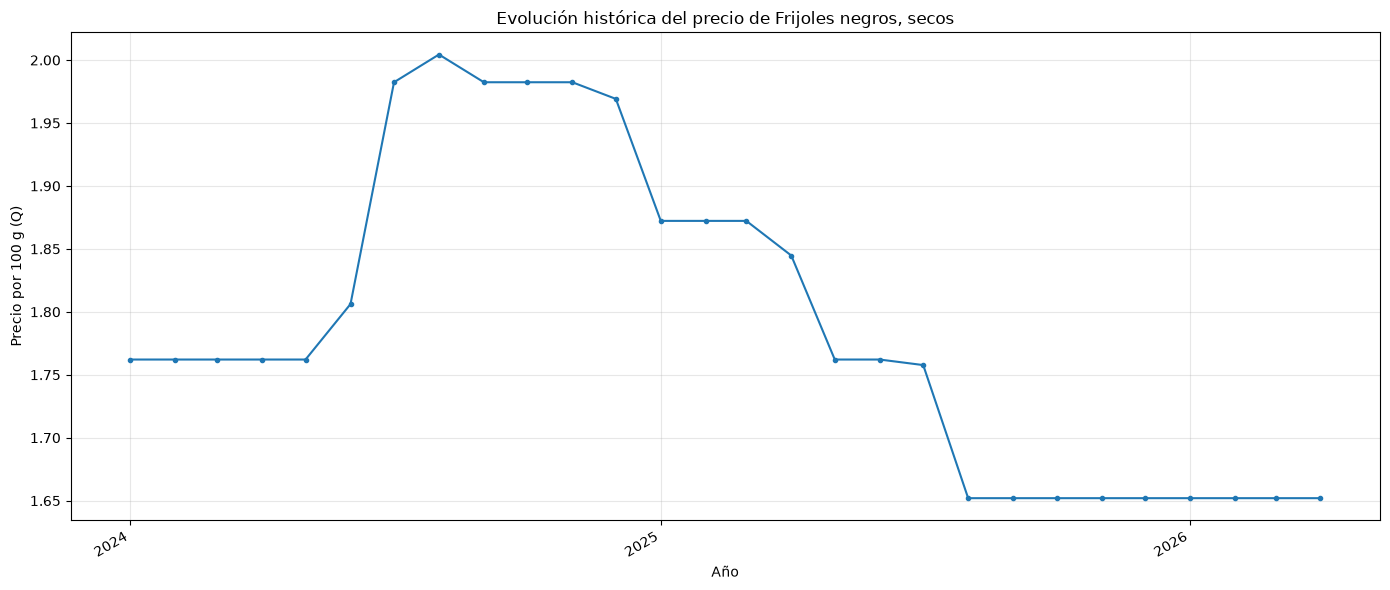

In [103]:
_candidate_1 = catalog.get('frijoles_negros_secos')
print(_candidate_1.years_by_region())
fig, ax = _candidate_1.plot_timeline('general')

{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


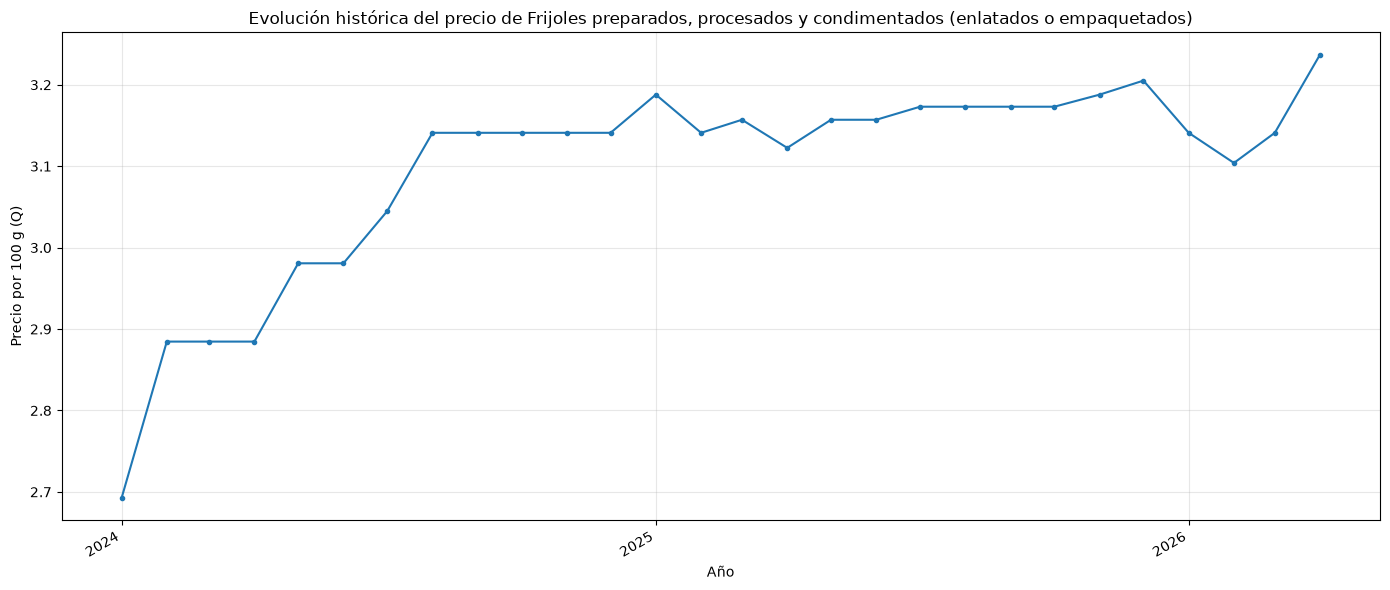

In [104]:
_candidate_1 = catalog.get('frijoles_preparados_procesados_y_condimentados_enlatados_o_empaquetados')
print(_candidate_1.years_by_region())
fig, ax = _candidate_1.plot_timeline('general')

Conceptualmente, el frijol genérico de 2017–2023 parece corresponder al frijol seco utilizado como alimento básico. Aunque es importante destacar que el  precio: Q2.28/100 g en diciembre de 2023 a Q1.76 en enero de 2024, una caída aproximada del 23%, posiblemente derivado de un cambio de metodología. 

## Azucar

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


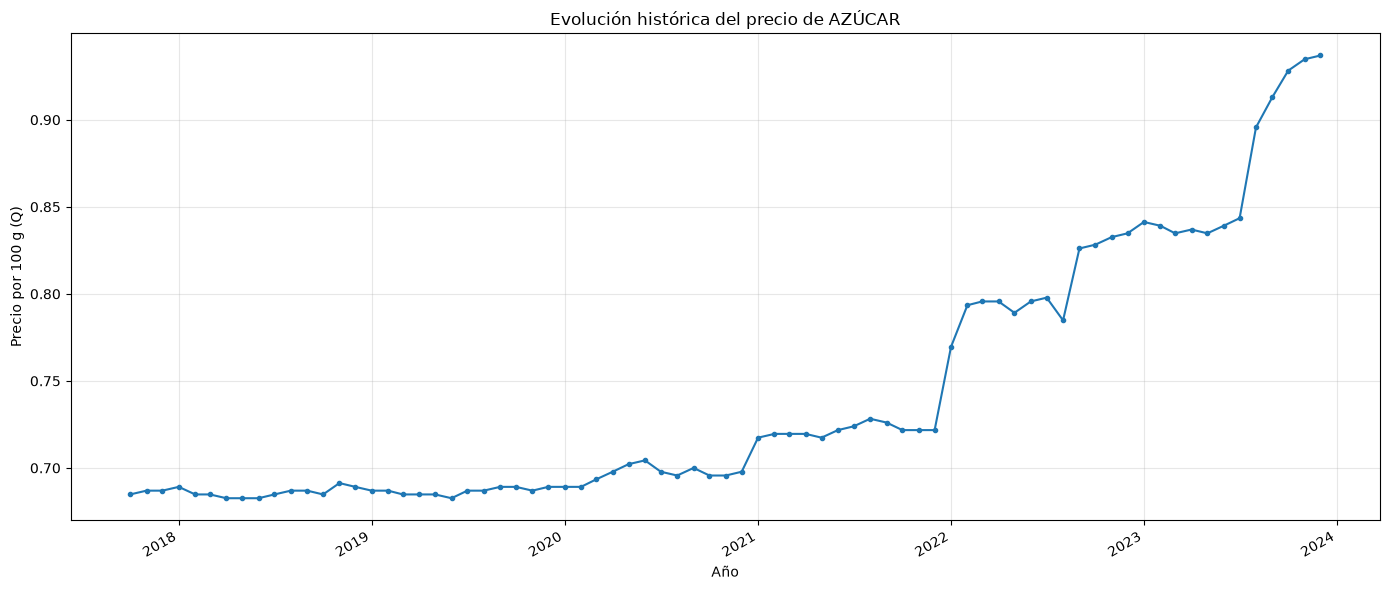

In [105]:
food = catalog.get('azucar')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [106]:
candidates = [_food for _food in catalog if 'azucar' in _food.id.lower() ]
#candidates.pop(0)
candidates

[Food(id='azucar', name='AZÚCAR', category='AZÚCAR', aliases={'AZÚCAR', 'Azúcar'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026F9B660B30>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=()),
 Food(id='azucar_de_cana_blanca', name='Azúcar de caña blanca', category=None, aliases={'Azúcar de caña blanca'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC5B5F0>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBCCADB0>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBB6E990>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=()),
 Food(id='azucar_de_cana_morena', name='Azúcar de caña morena', category=None, aliases={'Azúcar de caña morena'}, price_timelines={'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBCCAF30>}, nutrition=None, nutrition_match_score=

{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


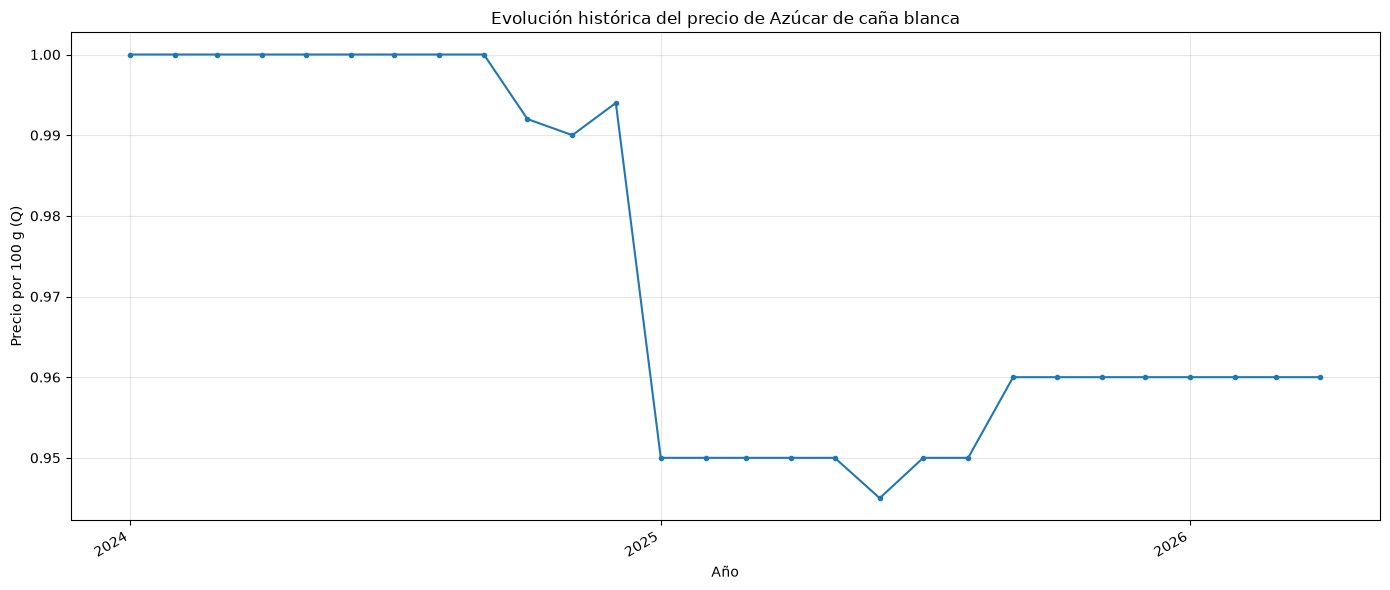

In [107]:
_candidate_1 = catalog.get('azucar_de_cana_blanca')
print(_candidate_1.years_by_region())
fig, ax = _candidate_1.plot_timeline('general')

{'general': [], 'rural': [], 'urbana': [2024, 2025, 2026]}


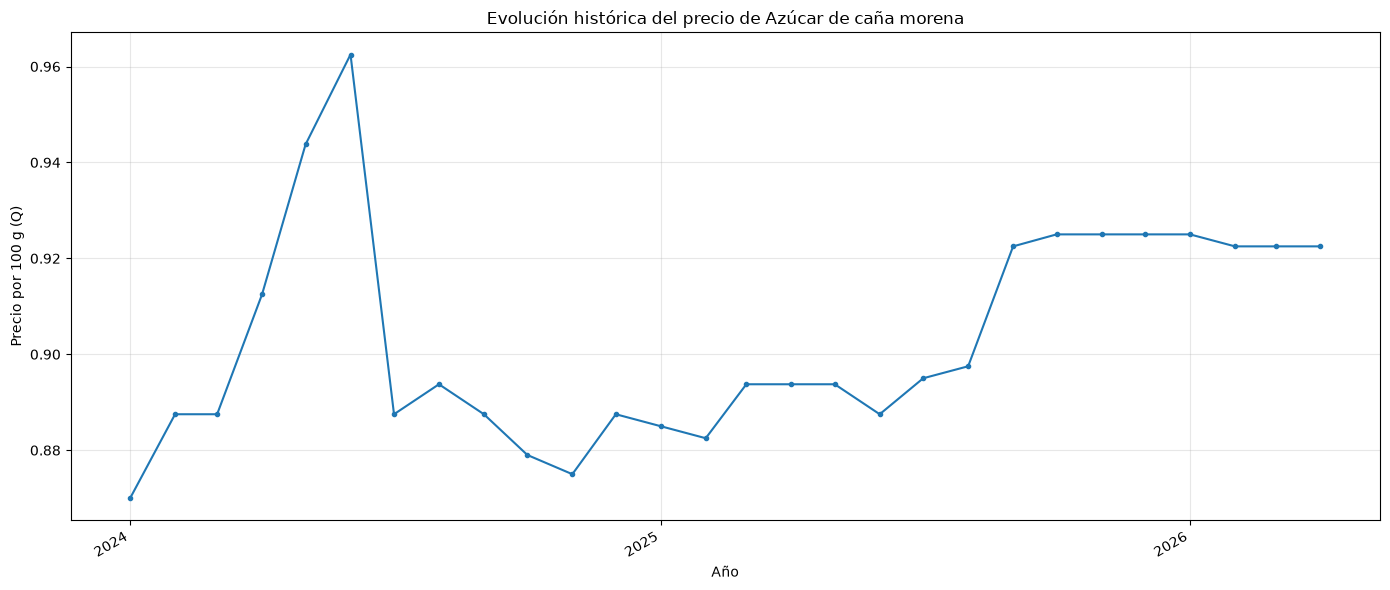

In [108]:
_candidate_1 = catalog.get('azucar_de_cana_morena')
print(_candidate_1.years_by_region())
fig, ax = _candidate_1.plot_timeline('urbana')

Por continuidad de precio y rango  de precios lo correcto parece ser mergear `azucar_de_cana_blanca` a `azucar`

## Incaparina

{'general': [2017, 2018, 2019, 2020], 'rural': [], 'urbana': []}


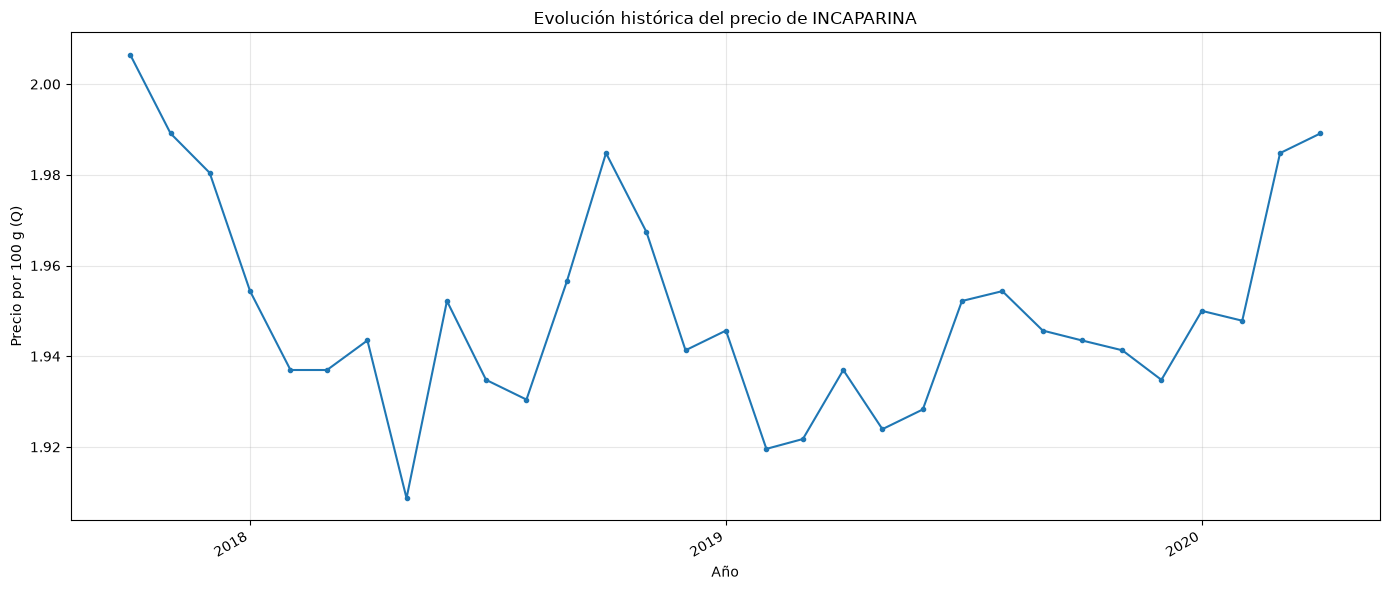

In [109]:
food = catalog.get('incaparina')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [110]:
candidates = [_food for _food in catalog if 'nutri' in _food.id.lower() ]
#candidates.pop(0)
candidates

[Food(id='preparacion_nutricional_a_base_de_maiz_y_soya', name='PREPARACION NUTRICIONAL A BASE DE MAÍZ Y SOYA', category='MISCELÁNEA', aliases={'PREPARACION NUTRICIONAL A BASE DE MAÍZ Y SOYA', 'Preparación nutricional a base de maíz y soya'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026F9B663050>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())]

{'general': [2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


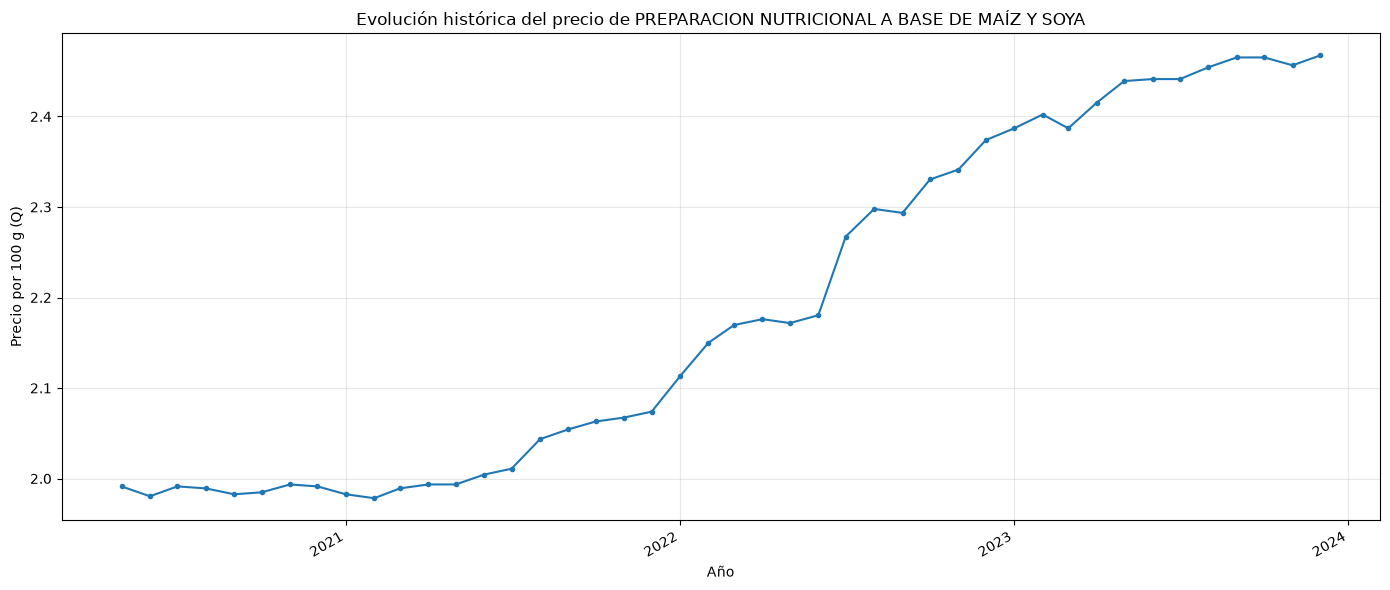

In [111]:
_candidate_1 = catalog.get('preparacion_nutricional_a_base_de_maiz_y_soya')
print(_candidate_1.years_by_region())
fig, ax = _candidate_1.plot_timeline('general')

Continuidad coherente y precio acorde, no existen registros de dicho elemento para 2024 a 2026. Por lo demas se procede a mergear `preparacion_nutricional_a_base_de_maiz_y_soya` a `incaparina`. 

## Sal

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


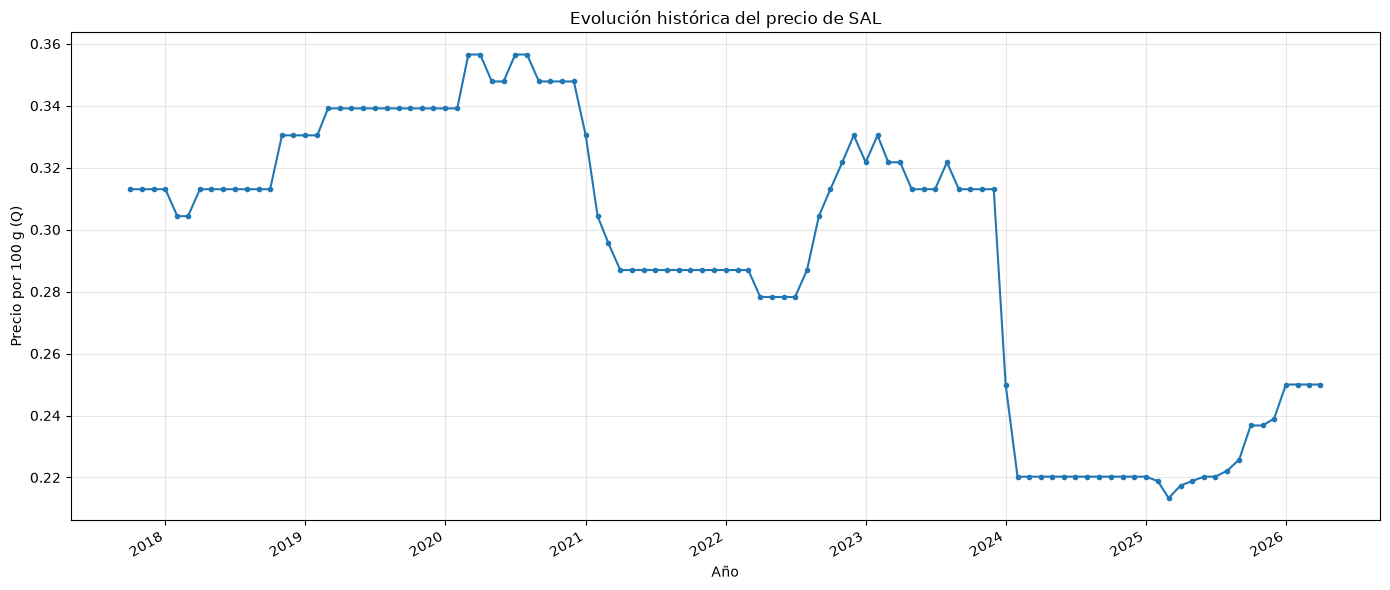

In [112]:
food = catalog.get('sal')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

Periodo commpleto, no requierie cambios. Destaca una gran caida en el precio, probablemente por el cambio de metodología en la CBA. 

## Sopas instantaneas en vaso

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


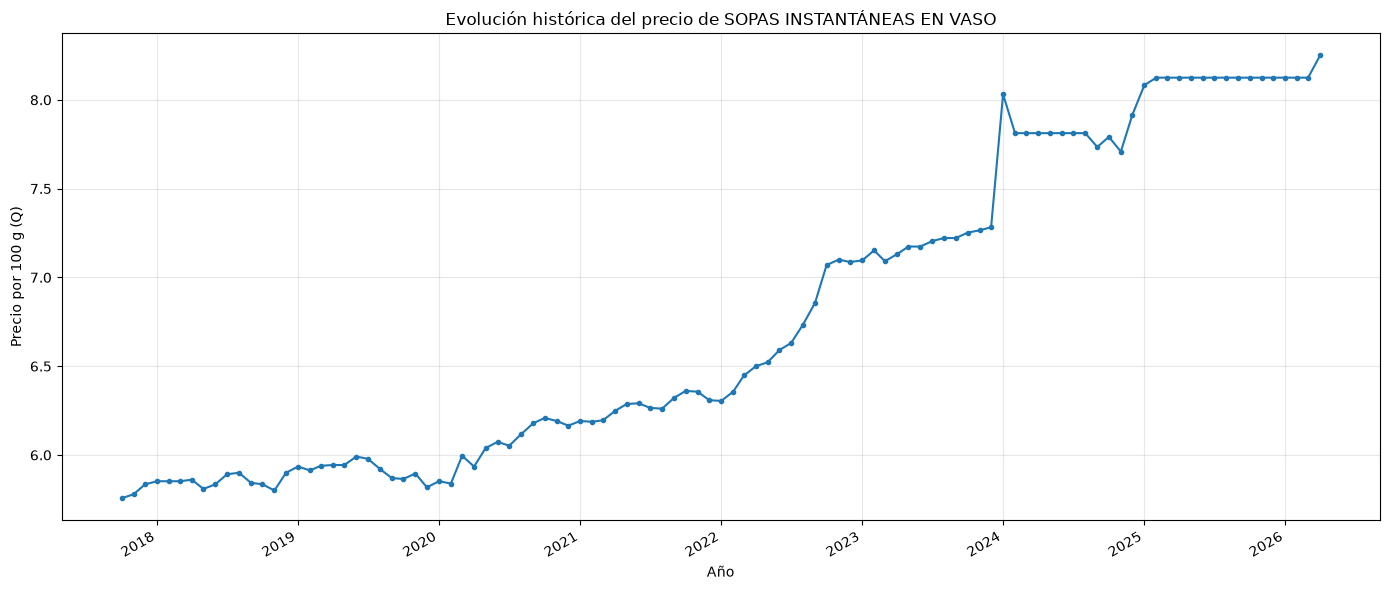

In [113]:
food = catalog.get('sopas_instantaneas_en_vaso')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

Periodo completo sin cambios adicionales requeridos. 

## Cafe en grano molido instantaneo

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023], 'rural': [], 'urbana': []}


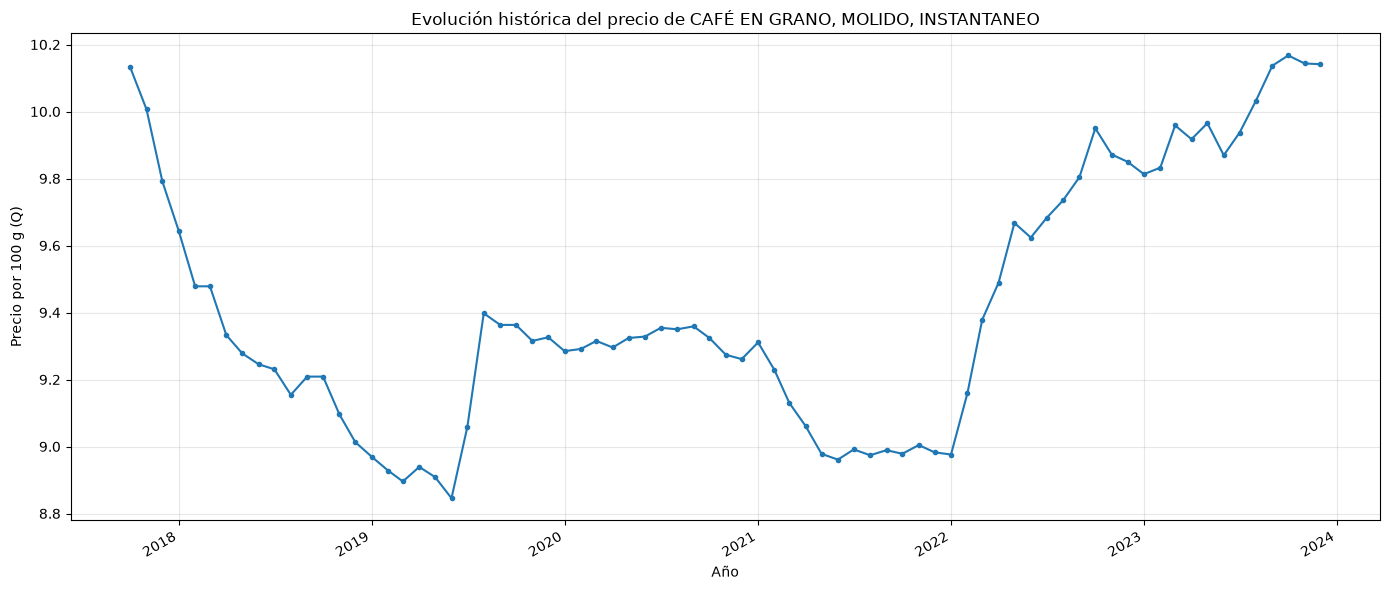

In [114]:
food = catalog.get('cafe_en_grano_molido_instantaneo')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

In [115]:
candidates = [_food for _food in catalog if 'cafe' in _food.id.lower() ]
#candidates.pop(0)
candidates

[Food(id='cafe_en_grano_molido_instantaneo', name='CAFÉ EN GRANO, MOLIDO, INSTANTANEO', category='MISCELÁNEA', aliases={'Café en grano, molido, instantáneo', 'CAFÉ EN GRANO, MOLIDO, INSTANTANEO', 'CAFÉ EN GRANO, MOLIDO, INSTANTÁNEO'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026F9B661F10>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=()),
 Food(id='cafe_molido', name='Café molido', category=None, aliases={'Café molido'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC5BBF0>, 'urbana': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBCCB470>, 'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC47B90>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=()),
 Food(id='cafe_instantaneo', name='Café instantáneo', category=None, aliases={'Café instantáneo'}, price_timelines={'rural': <canasta_inte

{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


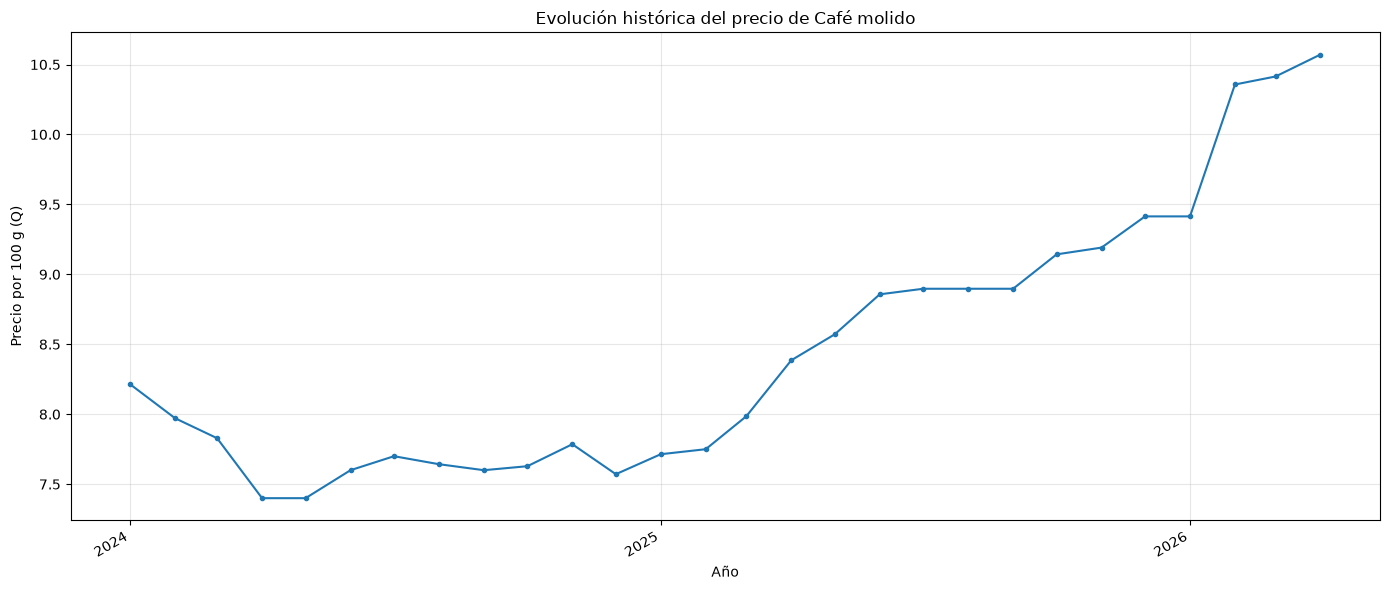

In [116]:
_candidate_1 = catalog.get('cafe_molido')
print(_candidate_1.years_by_region())
fig, ax = _candidate_1.plot_timeline('general')

{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


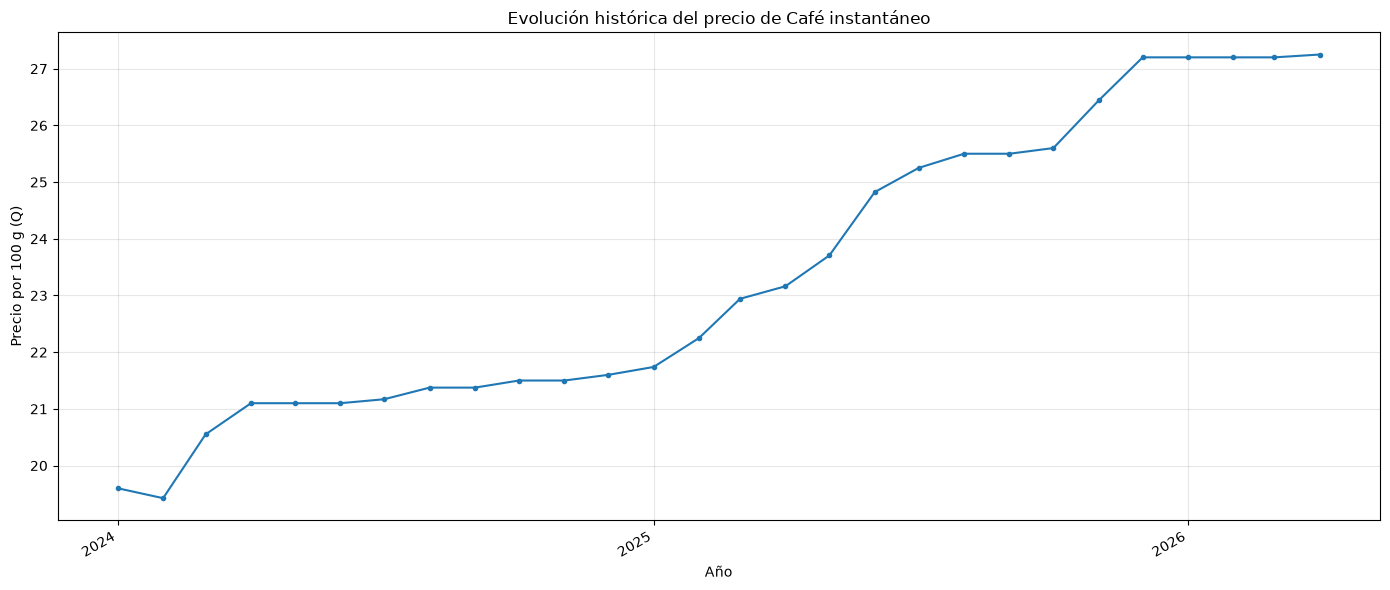

In [117]:
_candidate_1 = catalog.get('cafe_instantaneo')
print(_candidate_1.years_by_region())
fig, ax = _candidate_1.plot_timeline('general')

En los informes de CBA 2017 a 2023 se indica que se cotizaron sobre el molido e instantaneo. Aunque el molido coincide mejor en cuanto a la continuidad de precio, permaneceran separados por la forma en que se calculo en el cba 2017 a 2023 en comparacion da 2024 a 2026. No se mergea nada. 

{'general': [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


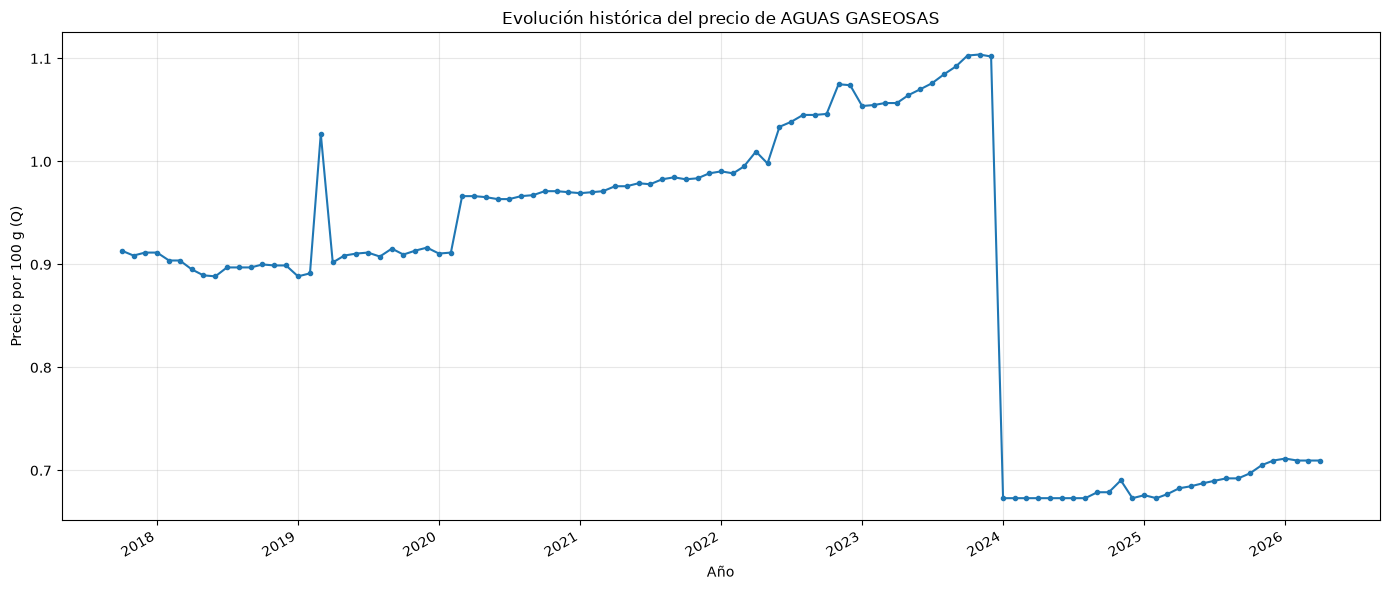

In [118]:
food = catalog.get('aguas_gaseosas')
print(food.years_by_region())
fig, ax = food.plot_timeline('general')

Periodo commpleto, no requierie cambios. Destaca una gran caida en el precio, probablemente por el cambio de metodología en la CBA. 

## Maiz Blanco

{'general': [], 'rural': [2024, 2025, 2026], 'urbana': []}


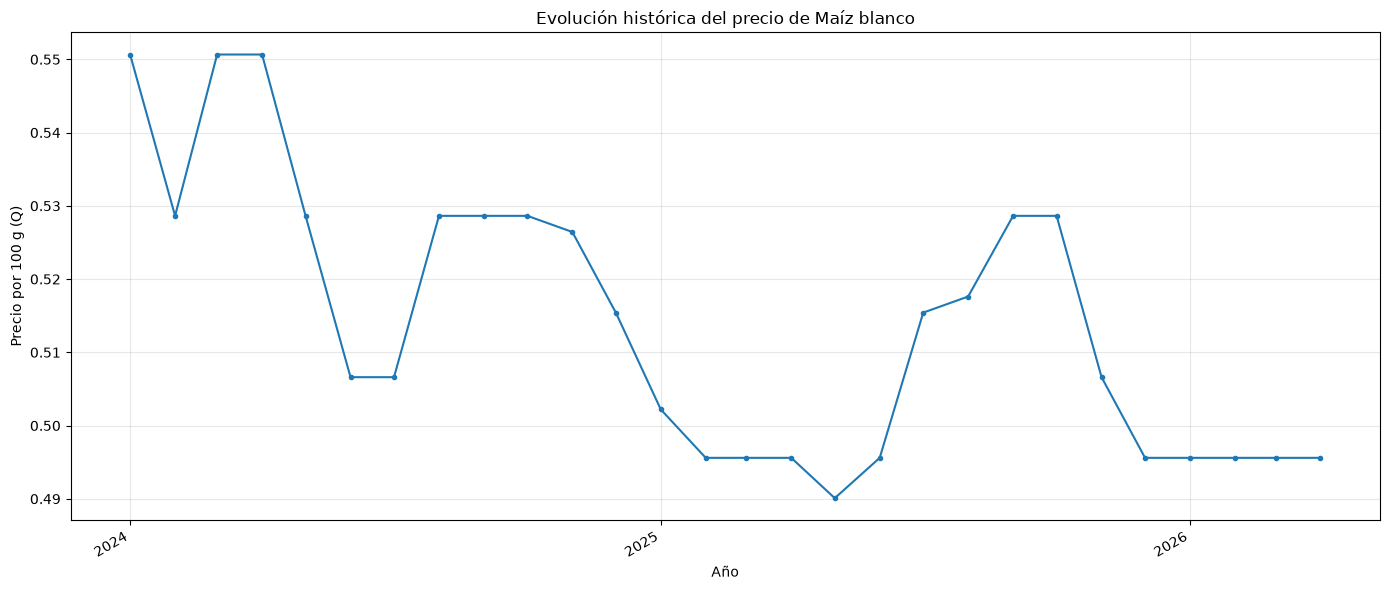

In [119]:
food = catalog.get('maiz_blanco')
print(food.years_by_region())
fig, ax = food.plot_timeline('rural')

In [120]:
candidates = [_food for _food in catalog if 'maiz' in _food.id.lower() ]
#candidates.pop(0)
candidates

[Food(id='tortillas_de_maiz', name='TORTILLAS DE MAÍZ', category='CEREALES', aliases={'Tortillas de maíz', 'TORTILLAS DE MAÍZ'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026F9B62F890>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=()),
 Food(id='preparacion_nutricional_a_base_de_maiz_y_soya', name='PREPARACION NUTRICIONAL A BASE DE MAÍZ Y SOYA', category='MISCELÁNEA', aliases={'PREPARACION NUTRICIONAL A BASE DE MAÍZ Y SOYA', 'Preparación nutricional a base de maíz y soya'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026F9B663050>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=()),
 Food(id='maiz_blanco', name='Maíz blanco', category=None, aliases={'Maíz blanco'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC474D0>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=()),


Sin alimentos correspondientes en periodo antes de 2024. Aplica para solo area rural 

## Harina de maiz

{'general': [], 'rural': [2024, 2025, 2026], 'urbana': []}


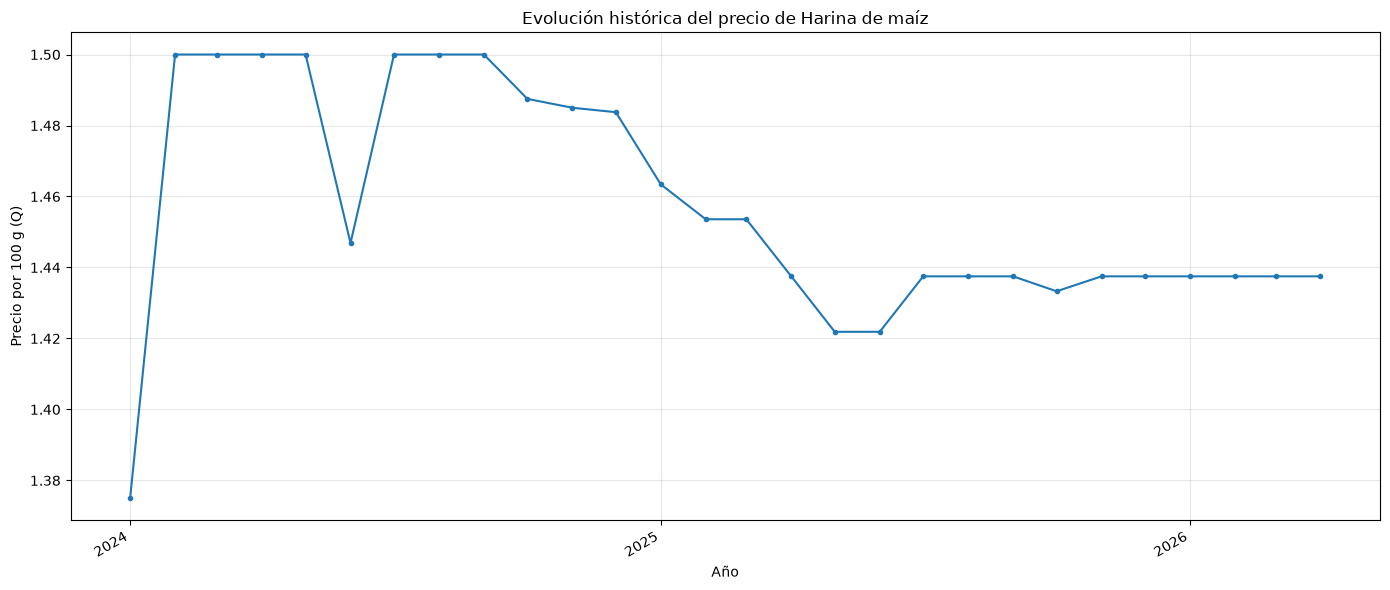

In [121]:
food = catalog.get('harina_de_maiz')
print(food.years_by_region())
fig, ax = food.plot_timeline('rural')

In [122]:
candidates = [_food for _food in catalog if 'harina' in _food.id.lower() ]
#candidates.pop(0)
candidates

[Food(id='harina_de_maiz', name='Harina de maíz', category=None, aliases={'Harina de maíz'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC5A210>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=()),
 Food(id='harina_para_atoles', name='Harina para atoles', category=None, aliases={'Harina para atoles'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC47530>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())]

No hay alimento que correspondan a este en otros periodos

## Harina para atoles

{'general': [], 'rural': [2024, 2025, 2026], 'urbana': []}


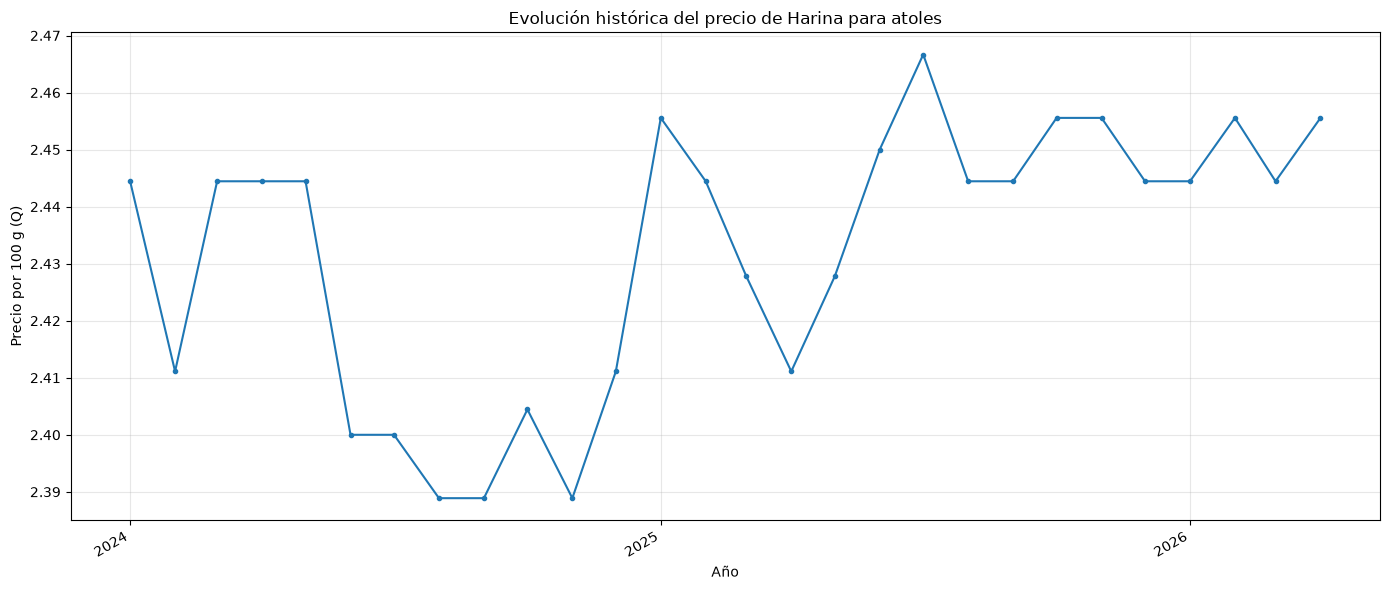

In [123]:
food = catalog.get('harina_para_atoles')
print(food.years_by_region())
fig, ax = food.plot_timeline('rural')

In [124]:
candidates = [_food for _food in catalog if 'harina' in _food.id.lower() ]
#candidates.pop(0)
candidates

[Food(id='harina_de_maiz', name='Harina de maíz', category=None, aliases={'Harina de maíz'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC5A210>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=()),
 Food(id='harina_para_atoles', name='Harina para atoles', category=None, aliases={'Harina para atoles'}, price_timelines={'rural': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026FDBC47530>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())]

No hay alimento que correspondan a este en otros periodos

## Galletas dulces

{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}


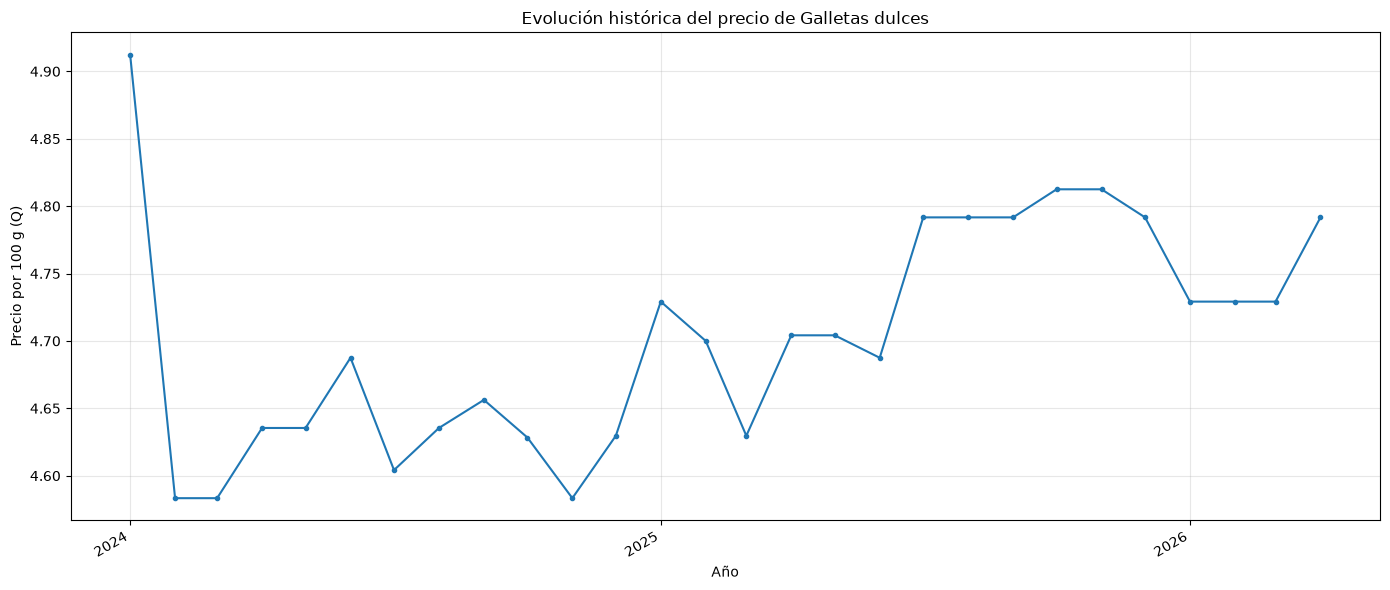

In [125]:
food = catalog.get('galletas_dulces')
print(food.years_by_region())
fig, ax = food.plot_timeline('rural')

In [126]:
food = next(catalog_iterable)
print(food.id)

fideos


`Galletas dulces` aparece como un alimento nuevo desde 2024 en ambas regiones. No existe un alimento histórico equivalente en el catálogo, por lo que se conserva independiente y no se realiza ningún merge.

## Alimentos restantes de 2024 a 2026

Los siguientes alimentos no tienen un equivalente directo en la CBA de 2017 a 2023. Se revisan por cobertura regional y se mantienen como alimentos independientes. Se omiten los alimentos para los que las secciones anteriores ya establecieron un merge, así como los candidatos que ya fueron evaluados explícitamente.

In [127]:
def review_remaining_foods(food_ids):
    for food_id in food_ids:
        reviewed_food = catalog.get(food_id)
        years = reviewed_food.years_by_region()
        print(f'{reviewed_food.name} ({reviewed_food.id})')
        print(years)
        region = next(
            (candidate_region for candidate_region in ('general', 'rural', 'urbana')
             if candidate_region in reviewed_food.price_timelines),
            None,
        )
        timeline = reviewed_food.price_timelines.get(region) if region else None
        has_normalized_prices = timeline and any(
            point.price_per_100g is not None for point in timeline
        )
        if has_normalized_prices:
            reviewed_food.plot_timeline(region)
        else:
            print('Sin precio por 100 g: falta una densidad o unidad convertible.')
        print('=' * 70)

### Alimentos exclusivos de la canasta rural

`Naranjas frescas`, `Repollo fresco o refrigerado` y `Dulces en general` solo tienen observaciones rurales desde 2024. No poseen un antecedente equivalente en la serie histórica y se conservan independientes.

Naranjas frescas (naranjas_frescas)
{'general': [], 'rural': [2024, 2025, 2026], 'urbana': []}
Repollo, fresco o refrigerado (repollo_fresco_o_refrigerado)
{'general': [], 'rural': [2024, 2025, 2026], 'urbana': []}
Dulces en general (incluye paletas, bombones, gomitas) (dulces_en_general_incluye_paletas_bombones_gomitas)
{'general': [], 'rural': [2024, 2025, 2026], 'urbana': []}


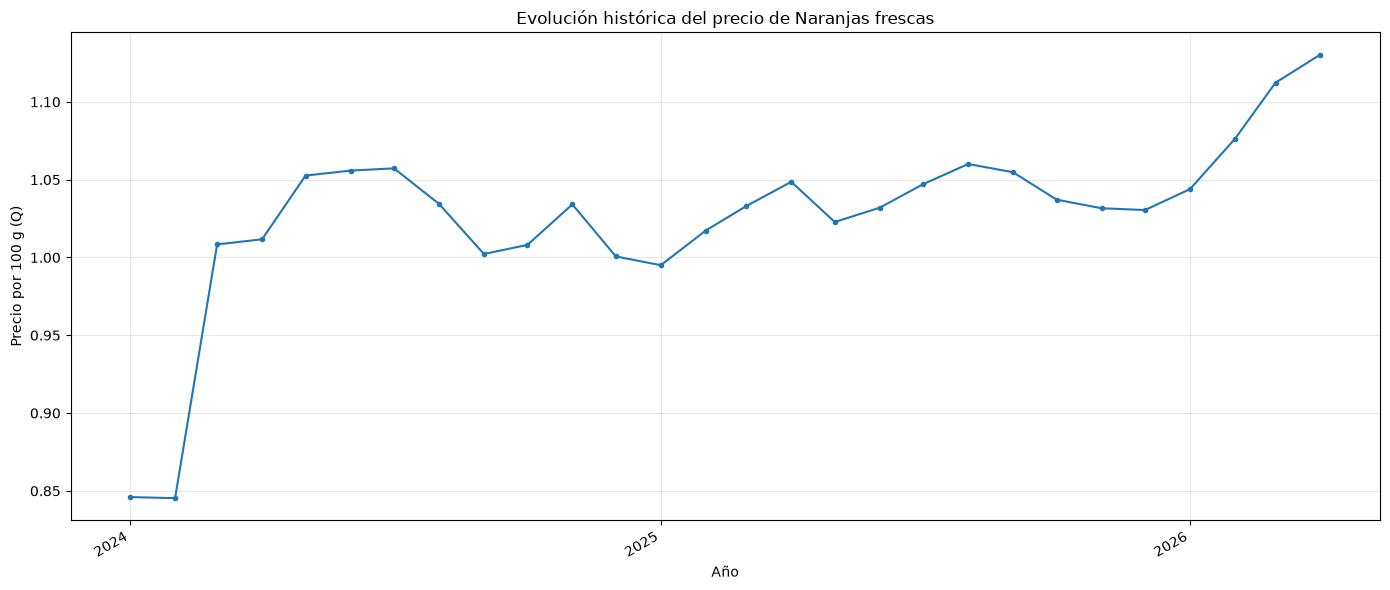

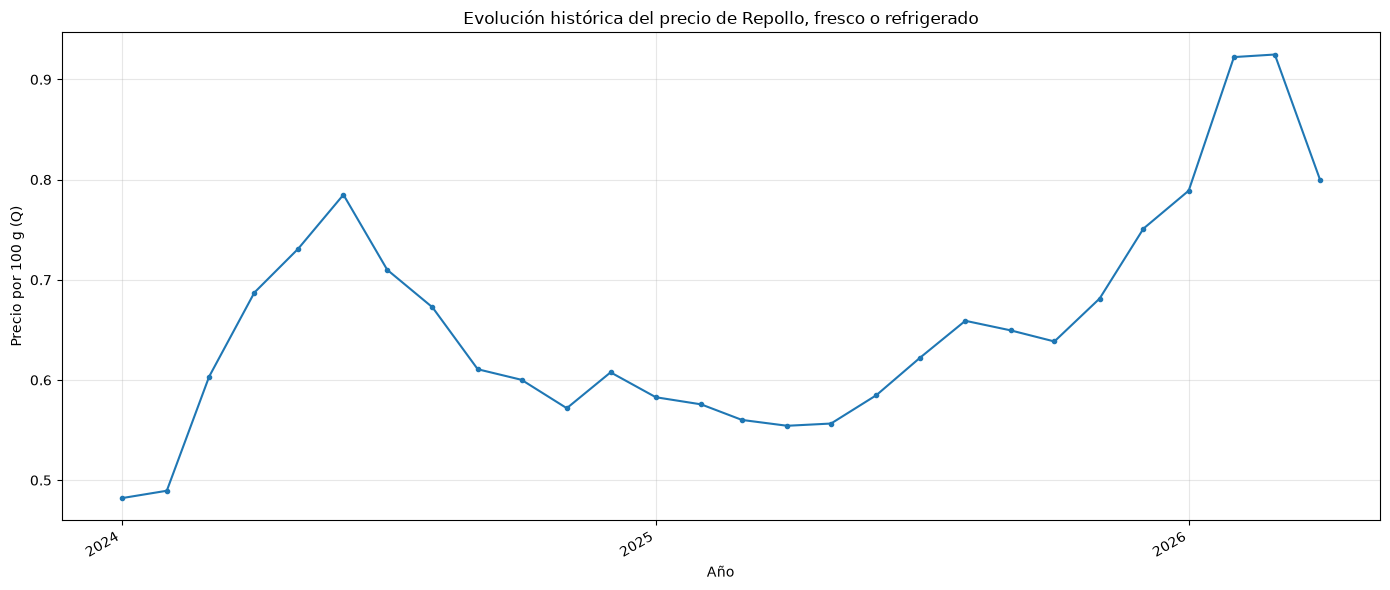

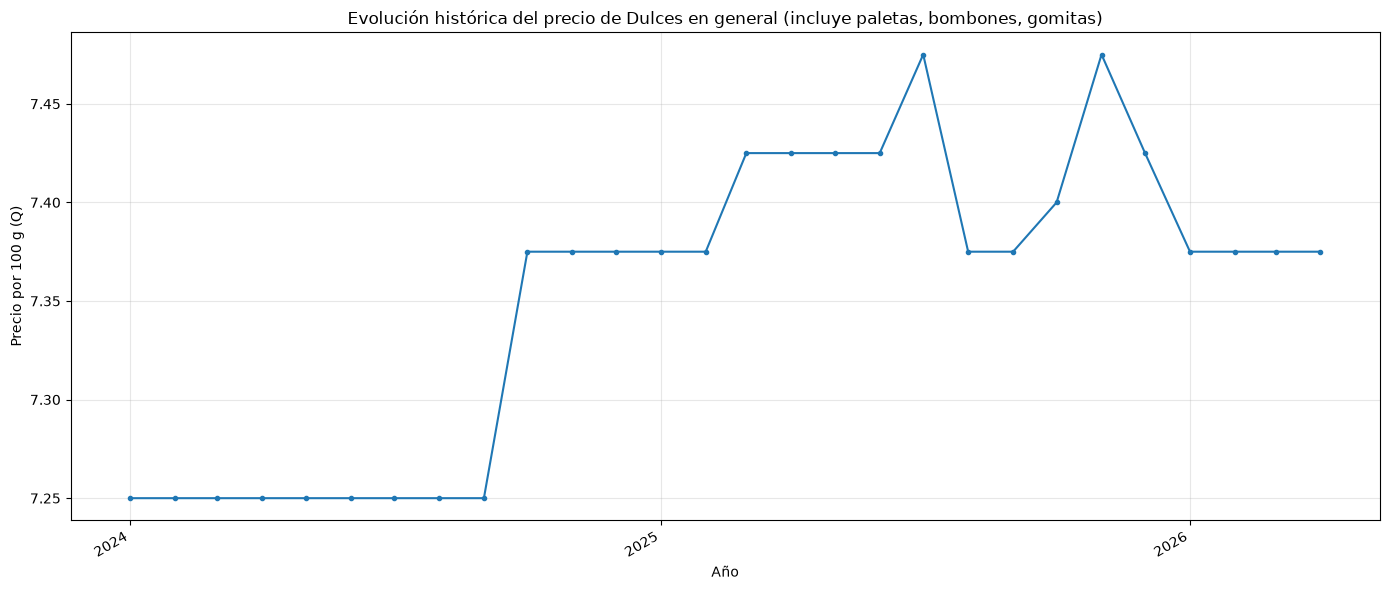

In [128]:
rural_only_foods = [
    'naranjas_frescas',
    'repollo_fresco_o_refrigerado',
    'dulces_en_general_incluye_paletas_bombones_gomitas',
]
review_remaining_foods(rural_only_foods)

### Alimentos presentes en ambas regiones

Estos productos aparecen desde 2024 en las canastas rural y urbana, pero no tienen una contraparte histórica suficientemente equivalente. En particular:

- `Cilantro, perejil y hierbabuena` no se une con `hierbas`, porque los informes históricos indican que esa cotización correspondía a macuy/hierba mora.
- Los frijoles preparados se mantienen separados del frijol negro seco por su procesamiento y porque ambos coexisten mensualmente.
- Consomé y bases para sopas no equivalen a sopas instantáneas en vaso.
- Las piezas de pollo preparadas, los tamales y los tiempos de comida son productos elaborados; no deben unirse con sus ingredientes crudos.
- Los jugos líquidos y el agua permanecen independientes. Si no existe una densidad configurada, el precio por 100 g queda sin calcular.

Manzanas frescas (manzanas_frescas)
{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}
Cilantro, perejil y hierbabuena (cilantro_perejil_y_hierbabuena)
{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}
Chile pimiento fresco (chile_pimiento_fresco)
{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}
Pepinos y pepinillos, frescos o refrigerados (pepinos_y_pepinillos_frescos_o_refrigerados)
{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}
Zanahorias (zanahorias)
{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}
Frijoles preparados, procesados y condimentados (enlatados o empaquetados) (frijoles_preparados_procesados_y_condimentados_enlatados_o_empaquetados)
{'general': [2024, 2025, 2026], 'rural': [2024, 2025, 2026], 'urbana': [2024, 2025, 2026]}
Consomé (consome)
{'general': [2024, 2025, 

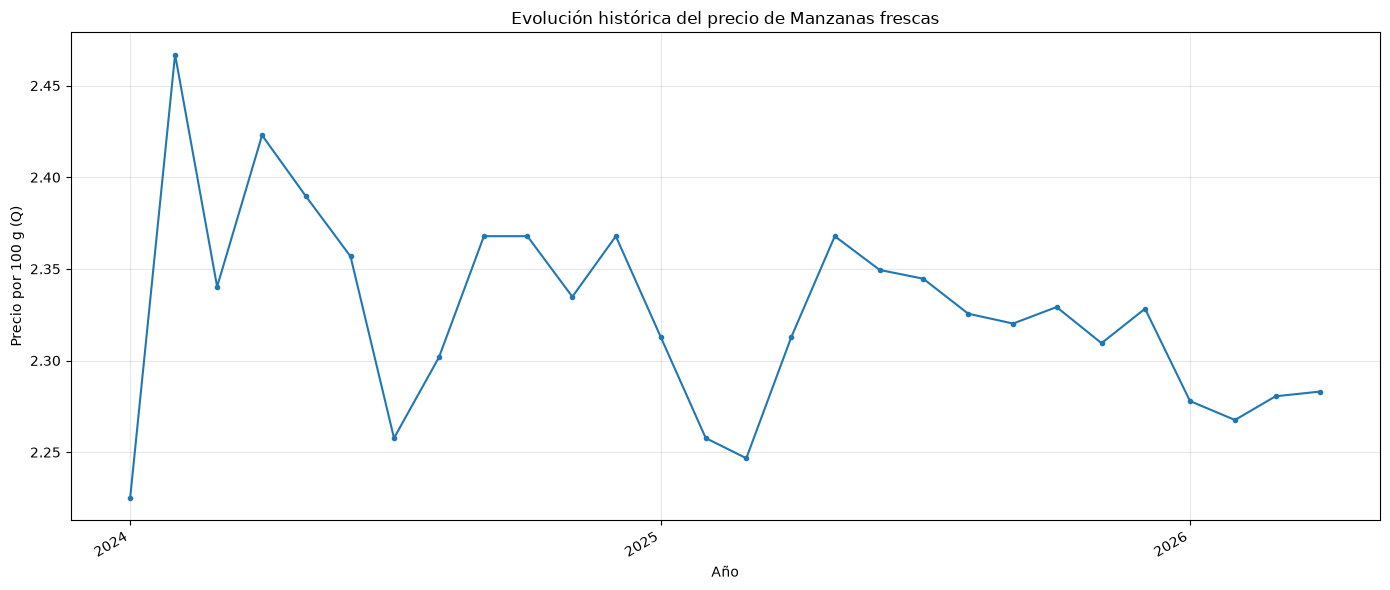

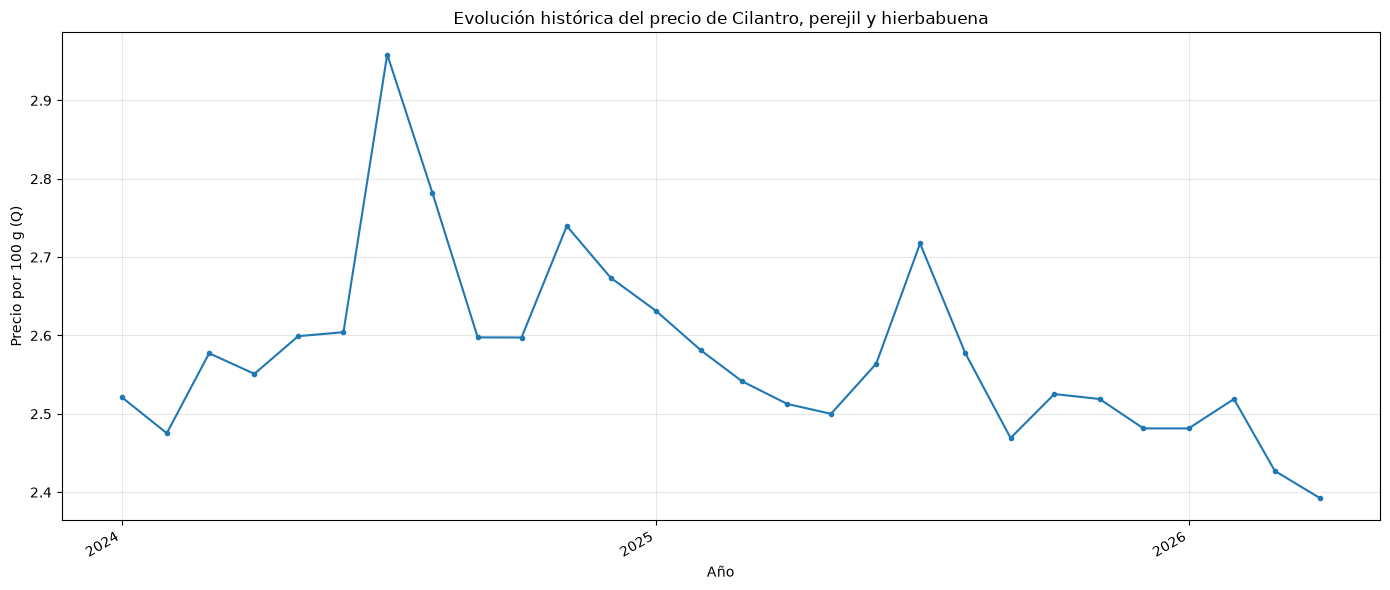

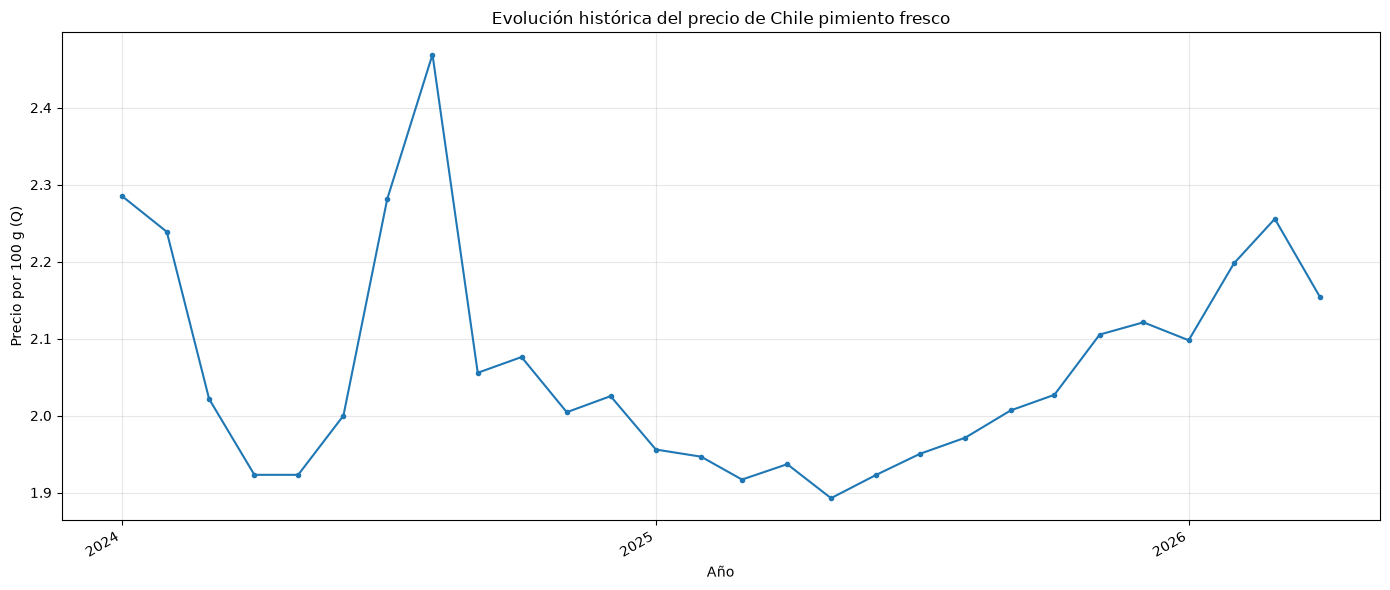

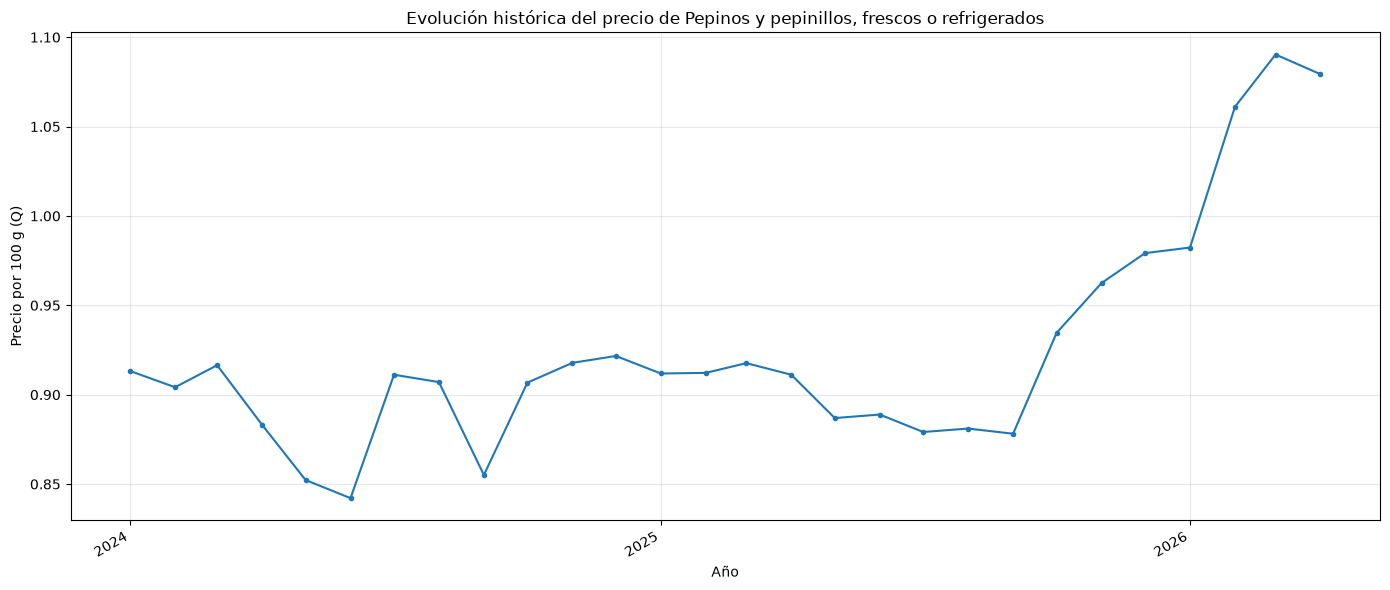

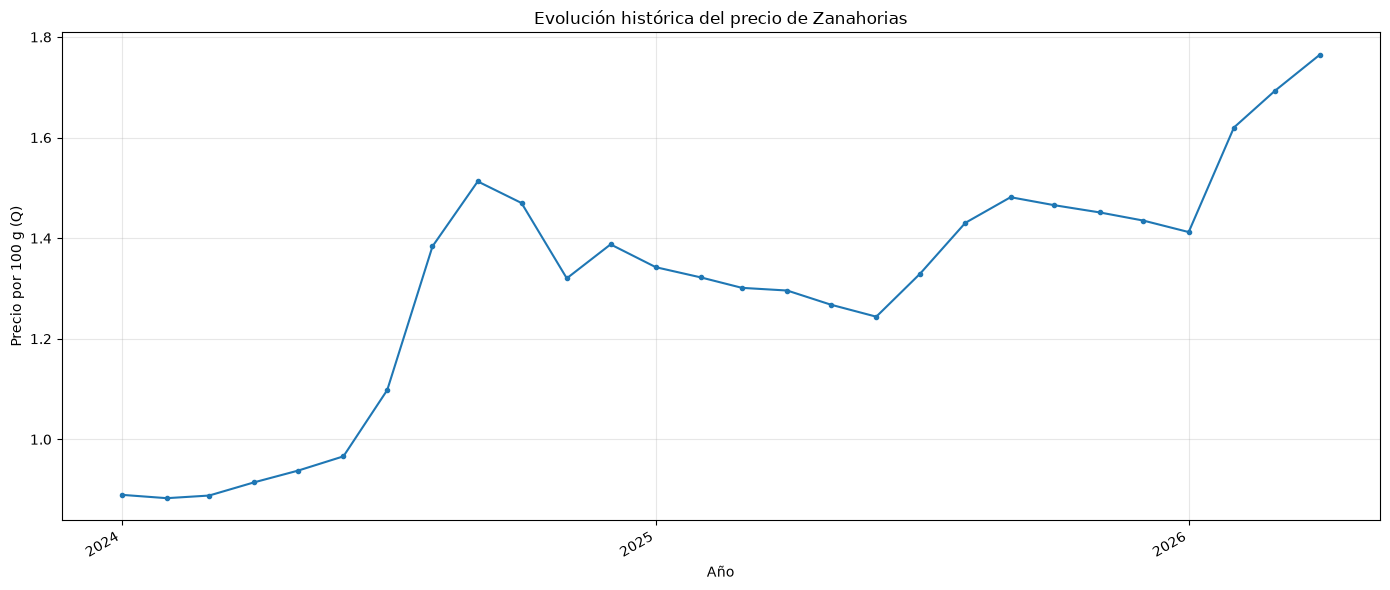

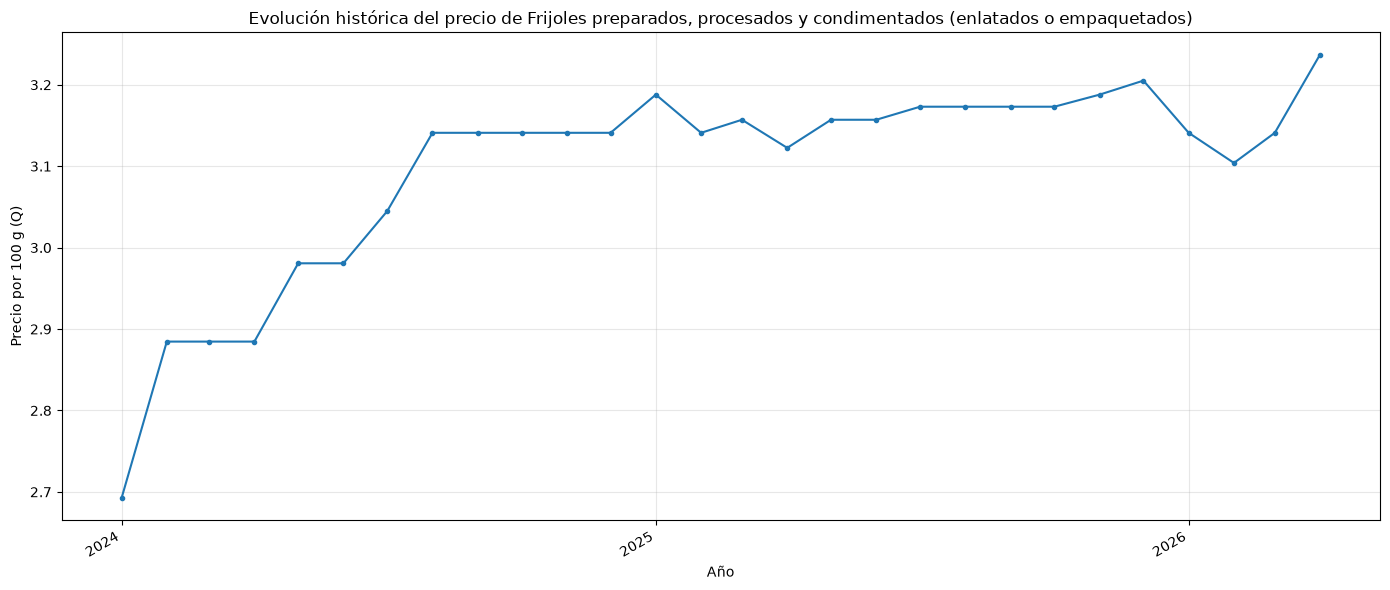

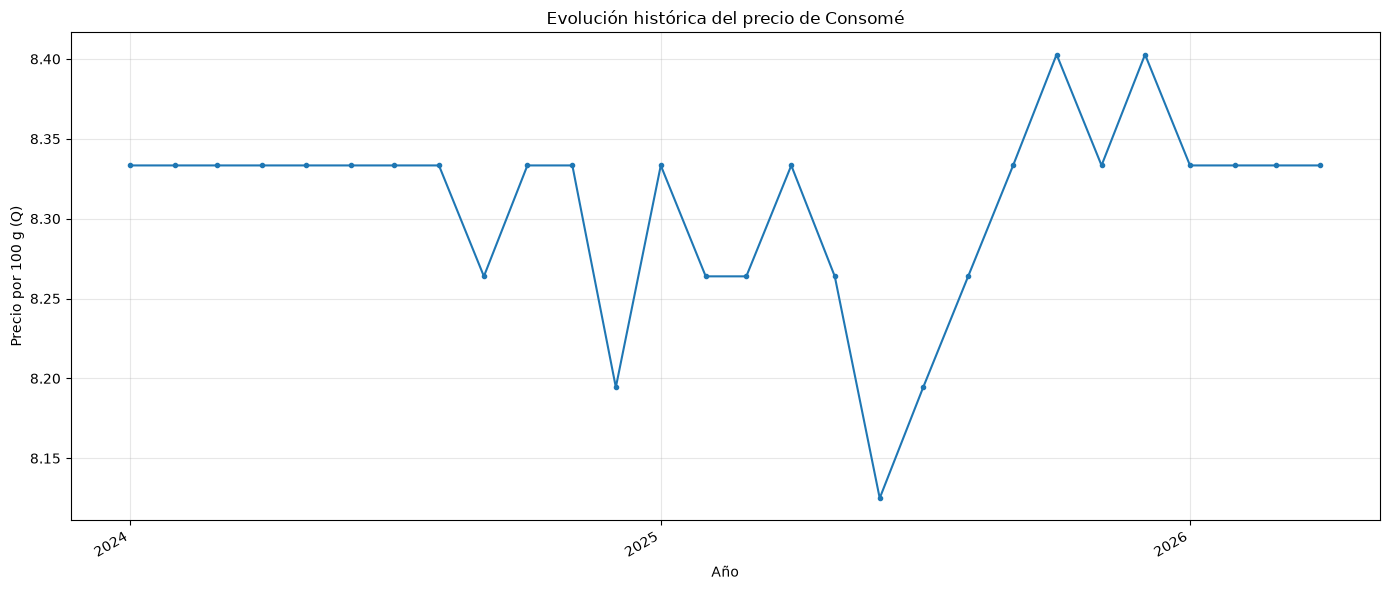

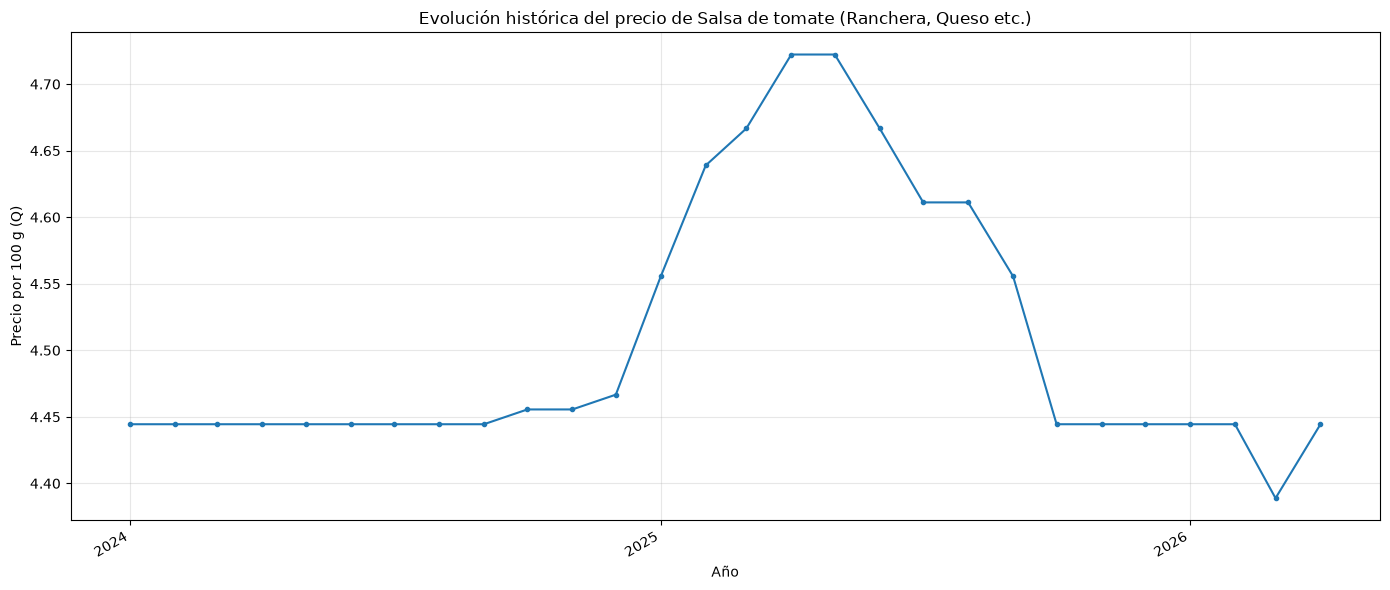

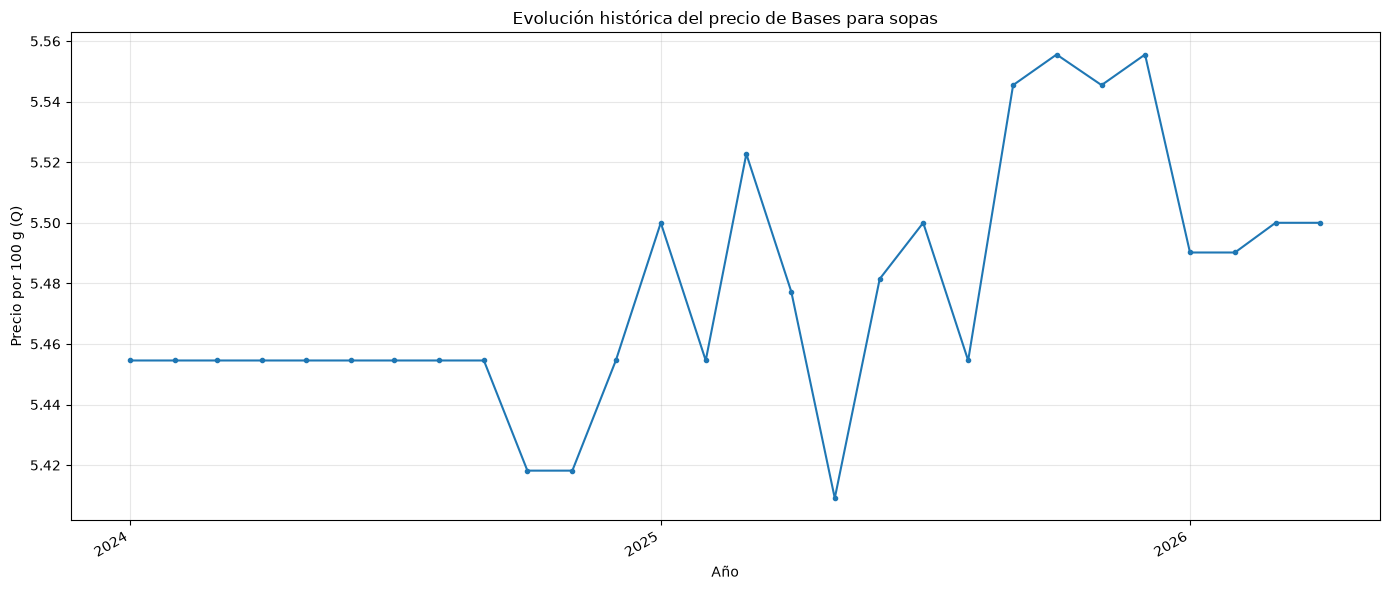

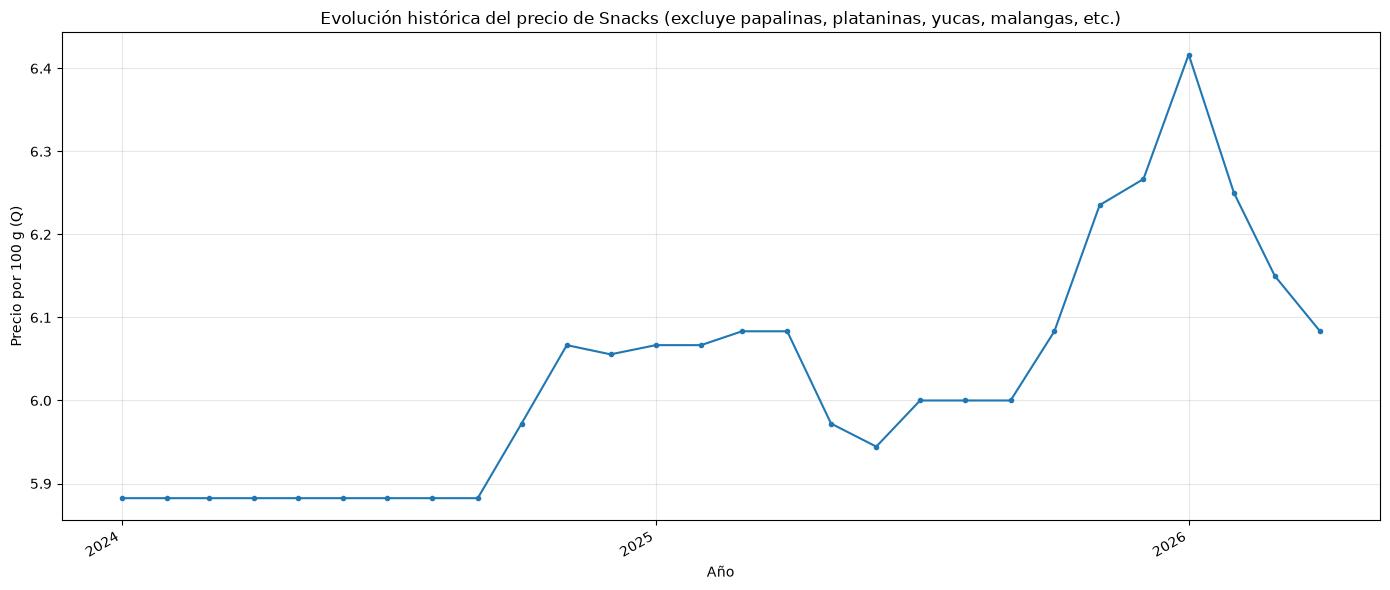

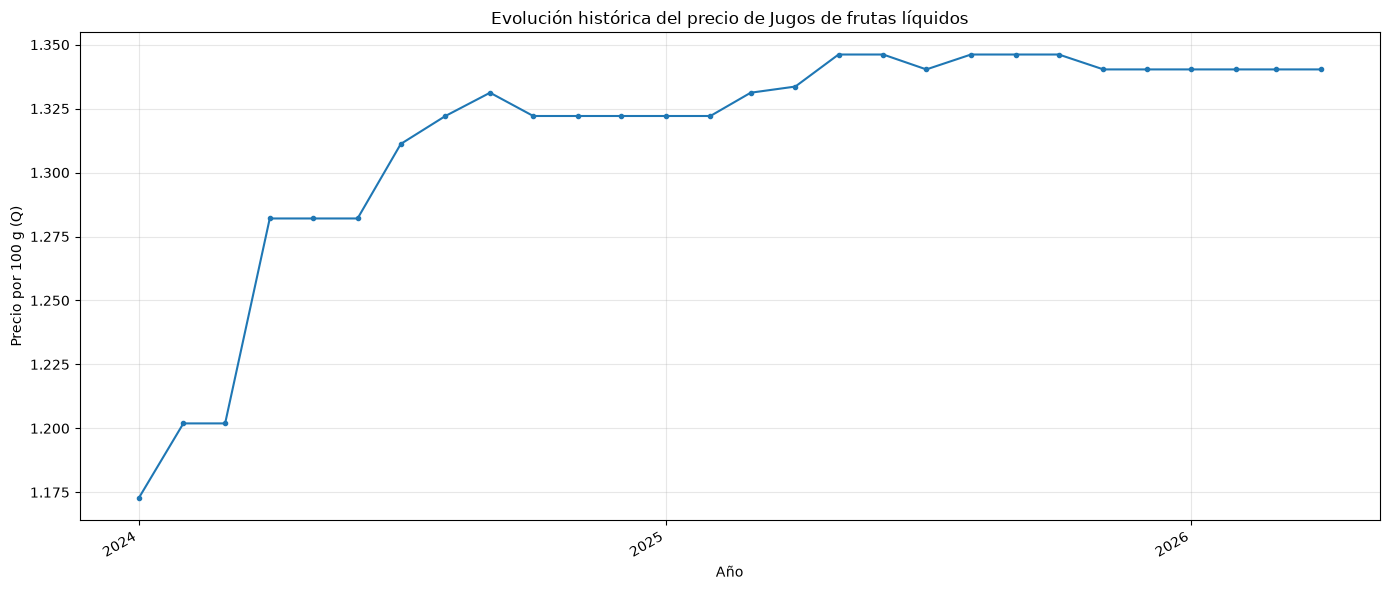

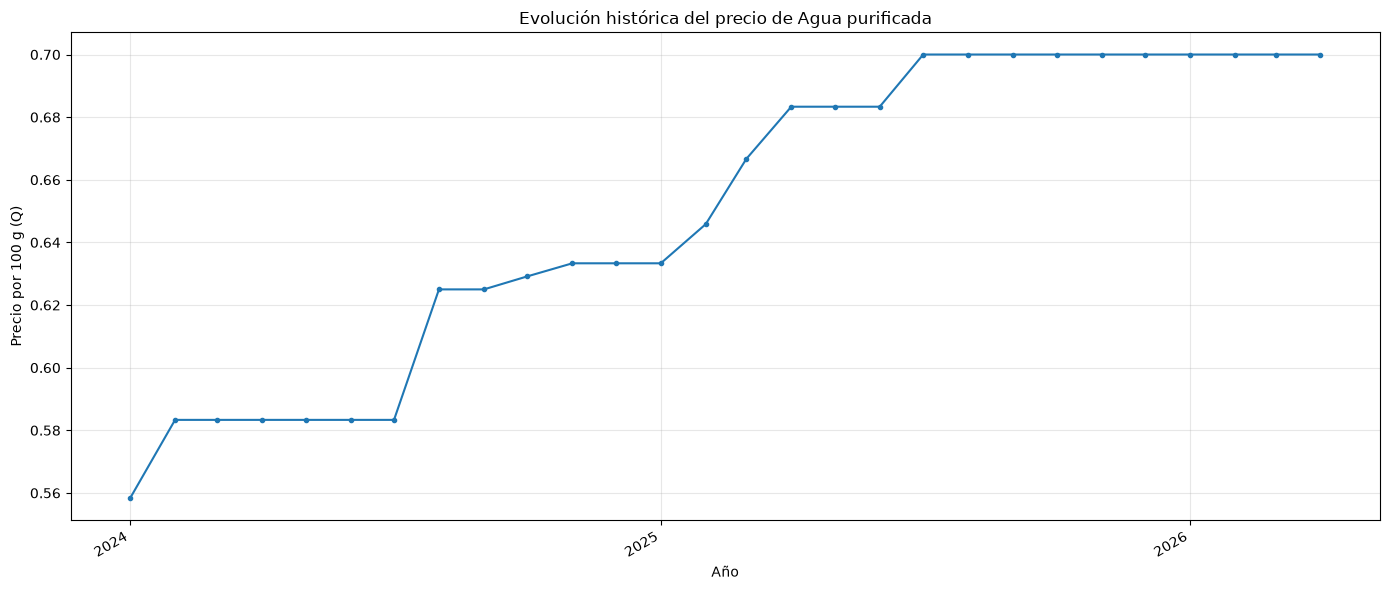

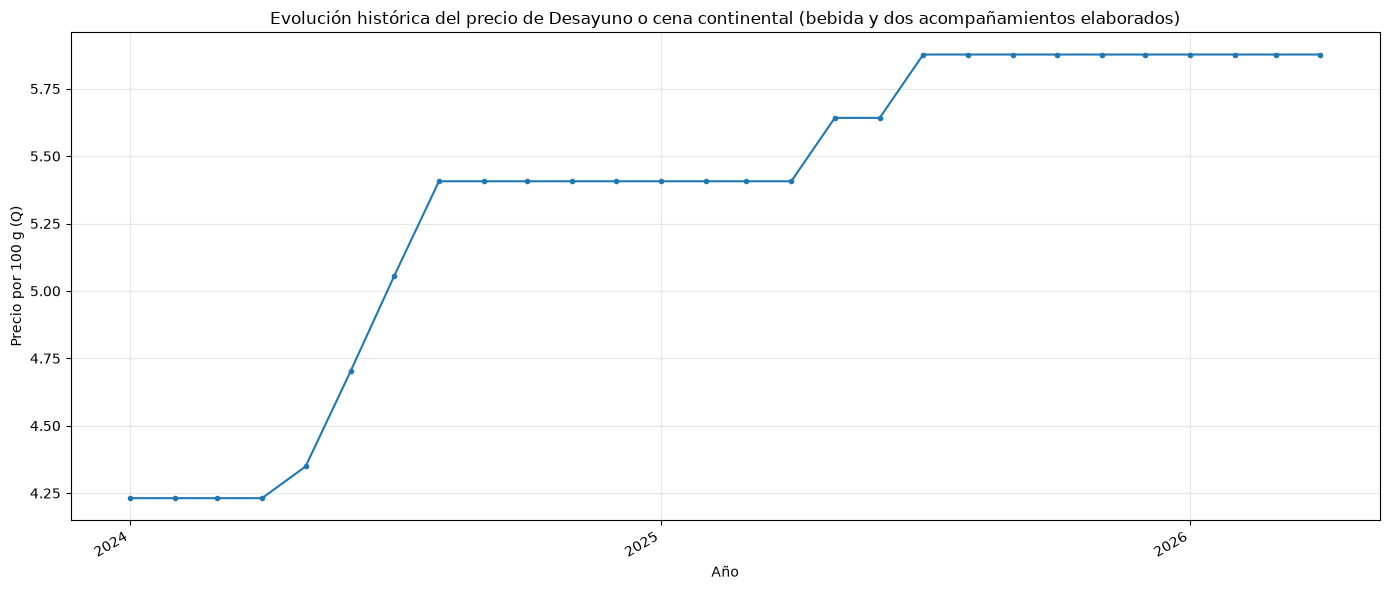

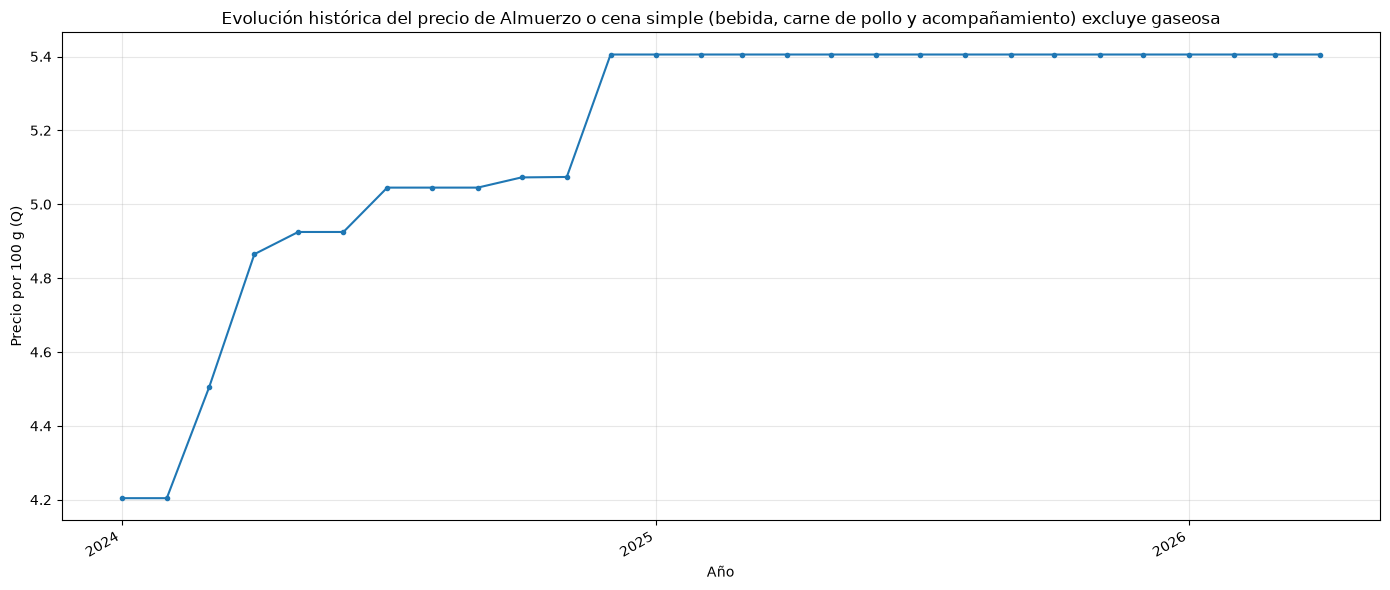

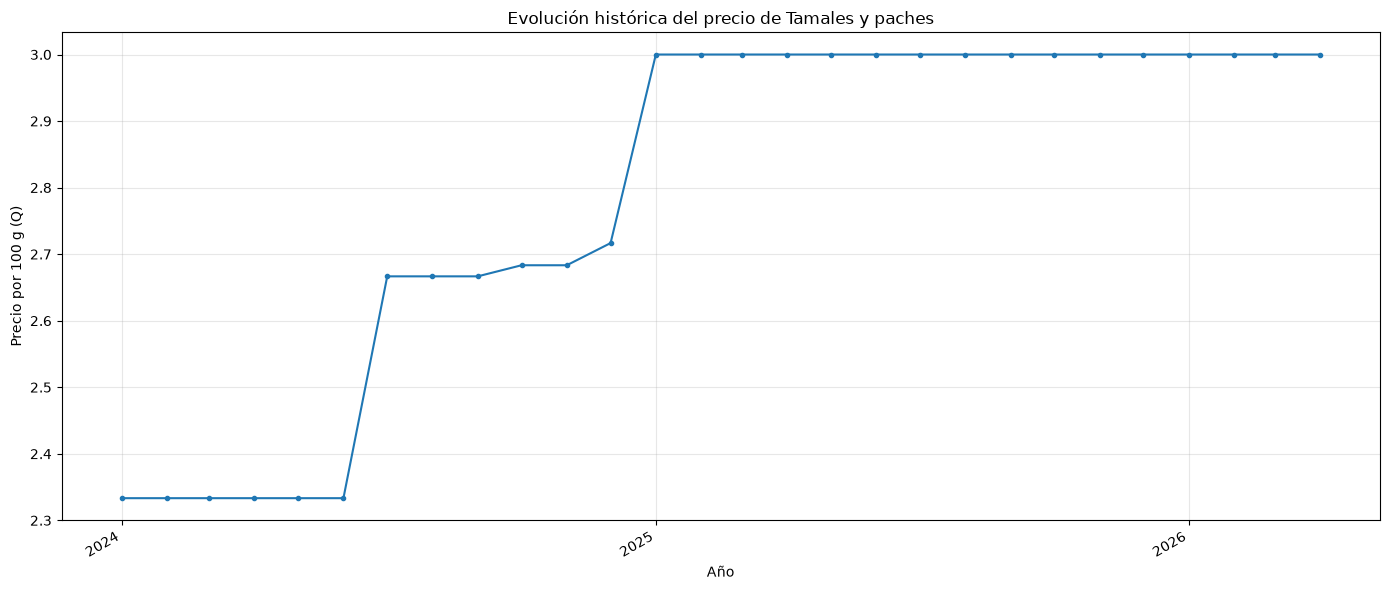

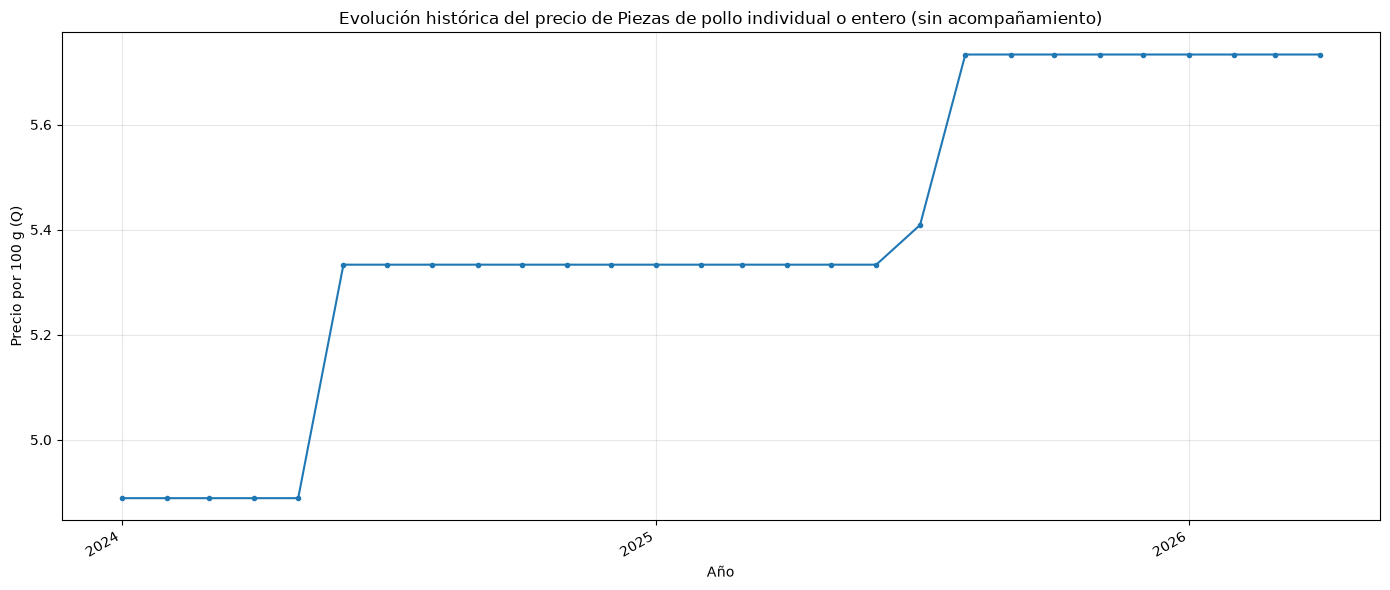

In [129]:
both_regions_foods = [
    'manzanas_frescas',
    'cilantro_perejil_y_hierbabuena',
    'chile_pimiento_fresco',
    'pepinos_y_pepinillos_frescos_o_refrigerados',
    'zanahorias',
    'frijoles_preparados_procesados_y_condimentados_enlatados_o_empaquetados',
    'consome',
    'salsa_de_tomate_ranchera_queso_etc',
    'bases_para_sopas',
    'snacks_excluye_papalinas_plataninas_yucas_malangas_etc',
    'jugos_de_frutas_liquidos',
    'agua_purificada',
    'desayuno_o_cena_continental_bebida_y_dos_acompanamientos_elaborados',
    'almuerzo_o_cena_simple_bebida_carne_de_pollo_y_acompanamiento_excluye_gaseosa',
    'tamales_y_paches',
    'piezas_de_pollo_individual_o_entero_sin_acompanamiento',
]
review_remaining_foods(both_regions_foods)

### Alimentos exclusivos de la canasta urbana

Estos alimentos solo tienen observaciones urbanas desde 2024 y se conservan separados. `Carne de res molida` es una presentación específica, no equivalente a toda la carne sin hueso. El jamón no se une con `embutidos`, porque la nota de la CBA histórica identifica esa serie con salchicha. El azúcar morena coexiste con el azúcar blanca y no debe reemplazarla. Los atoles son una bebida preparada y no equivalen a la harina para atoles.

Cereales de bolsa o caja (cereales_de_bolsa_o_caja)
{'general': [], 'rural': [], 'urbana': [2024, 2025, 2026]}
Carne de res molida (carne_de_res_molida)
{'general': [], 'rural': [], 'urbana': [2024, 2025, 2026]}
Jamón (pollo, res, cerdo, mixto, etc.) (jamon_pollo_res_cerdo_mixto_etc)
{'general': [], 'rural': [], 'urbana': [2024, 2025, 2026]}
Papayas frescas (papayas_frescas)
{'general': [], 'rural': [], 'urbana': [2024, 2025, 2026]}
Lechuga, achicoria y rúgula, fresca o refrigerada (lechuga_achicoria_y_rugula_fresca_o_refrigerada)
{'general': [], 'rural': [], 'urbana': [2024, 2025, 2026]}
Apio (apio)
{'general': [], 'rural': [], 'urbana': [2024, 2025, 2026]}
Verduras frescas o refrigeradas limpias y cortadas (excluye las ensaladas) (verduras_frescas_o_refrigeradas_limpias_y_cortadas_excluye_las_ensaladas)
{'general': [], 'rural': [], 'urbana': [2024, 2025, 2026]}
Azúcar de caña morena (azucar_de_cana_morena)
{'general': [], 'rural': [], 'urbana': [2024, 2025, 2026]}
Mayonesa (mayonesa)

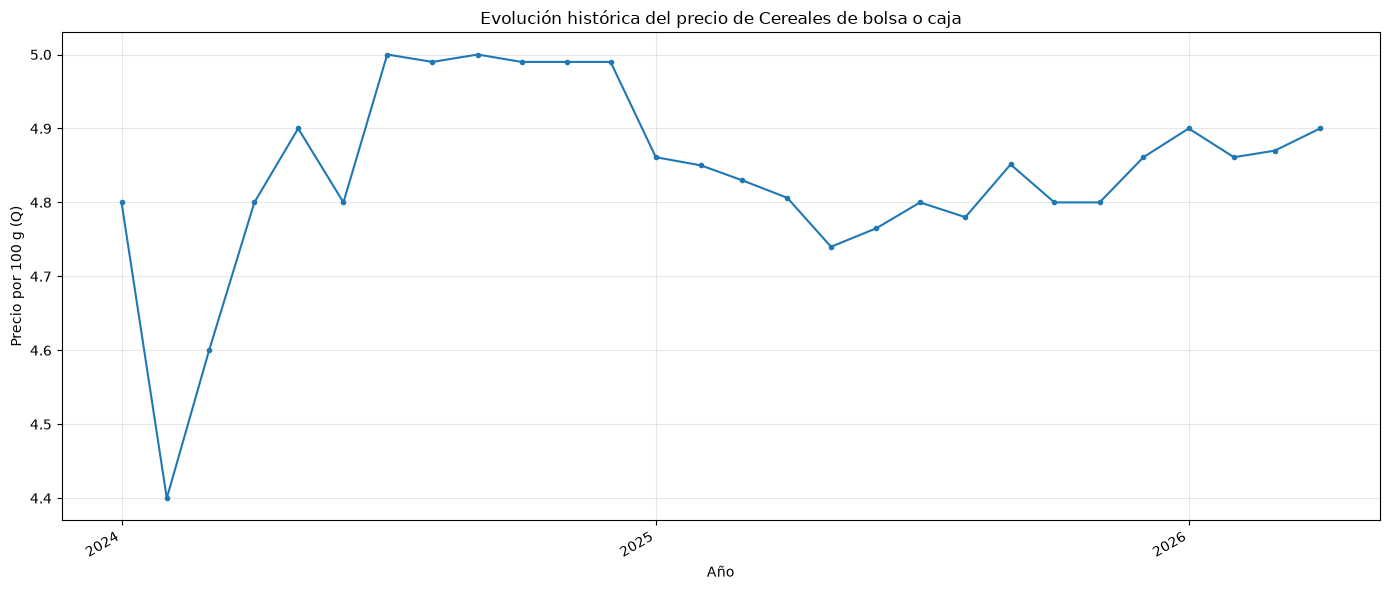

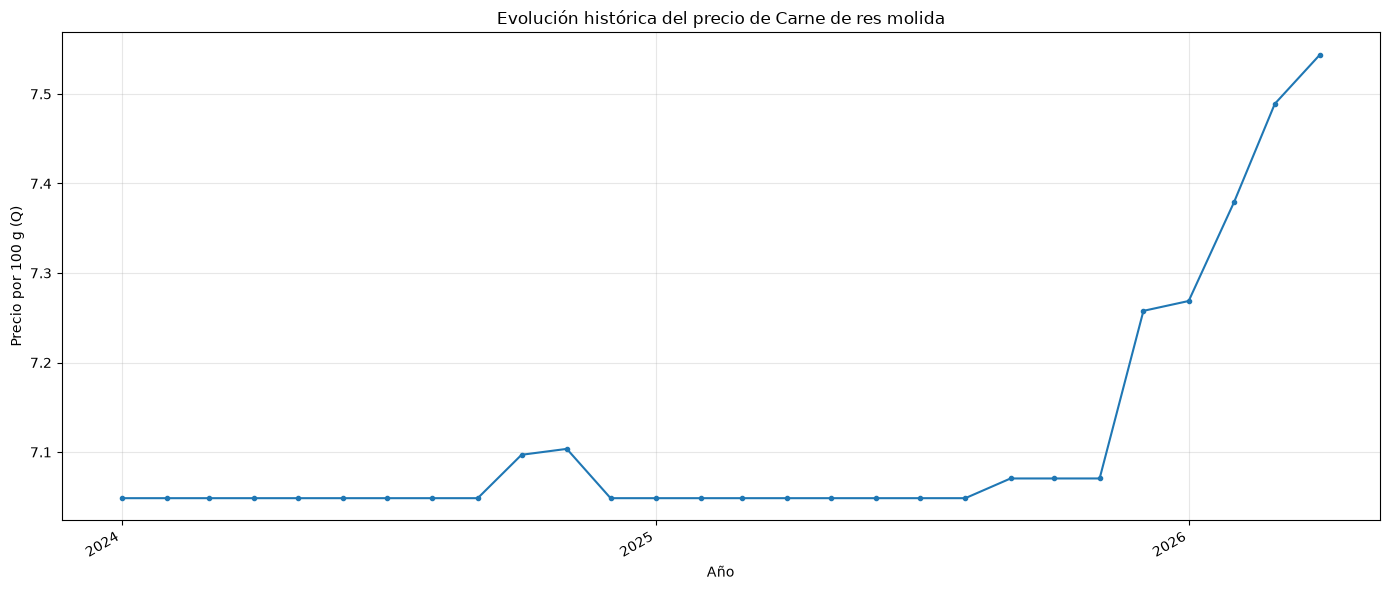

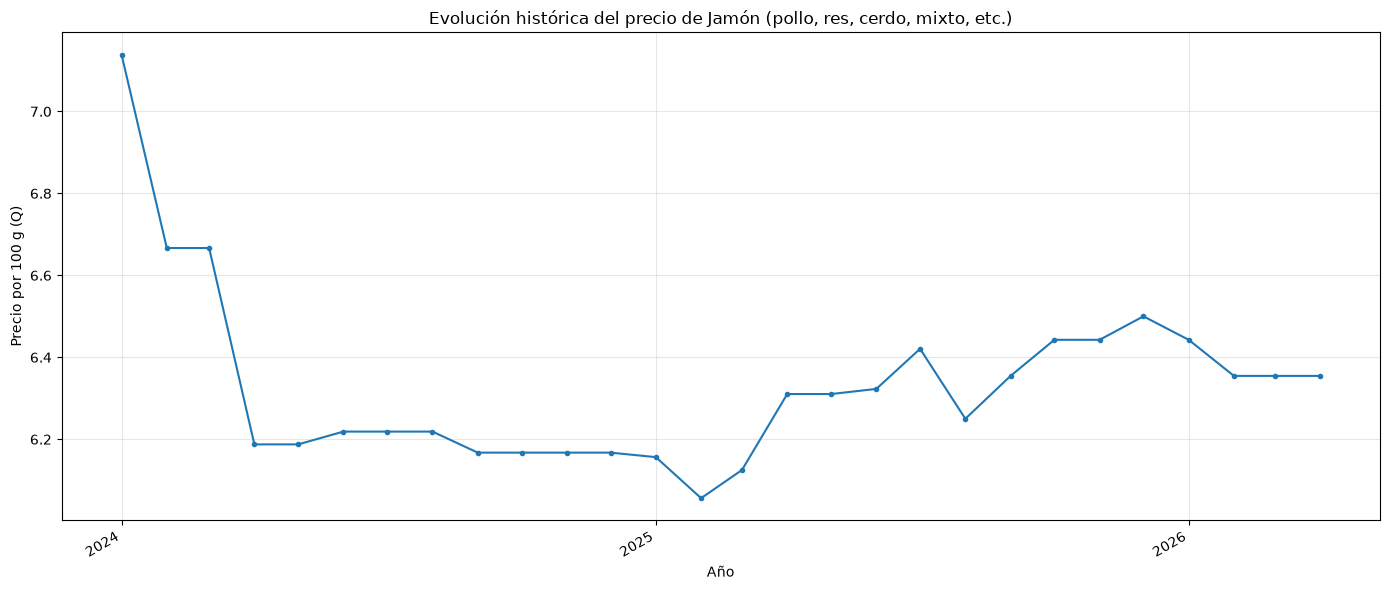

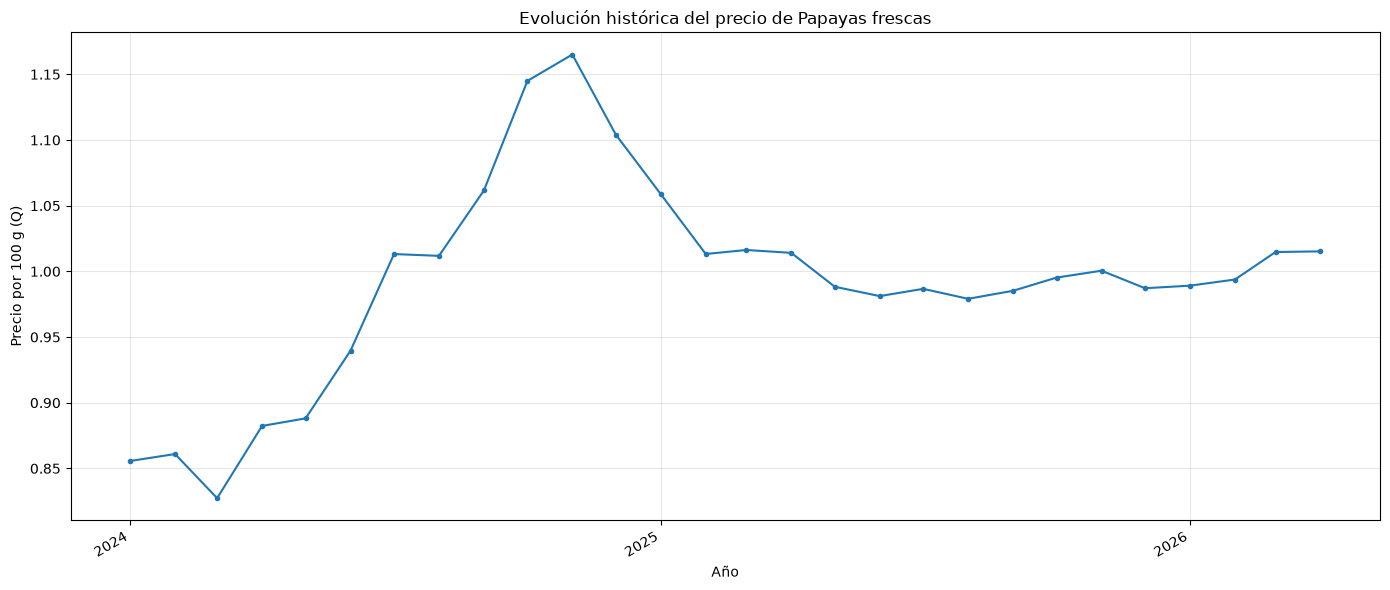

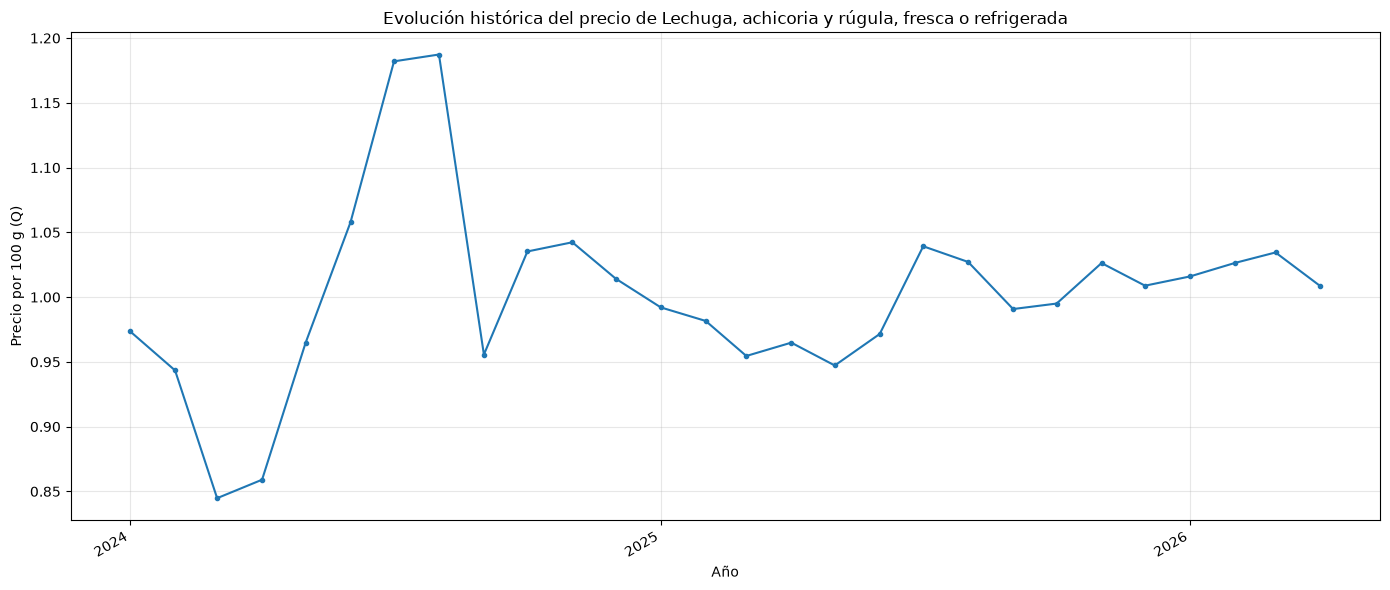

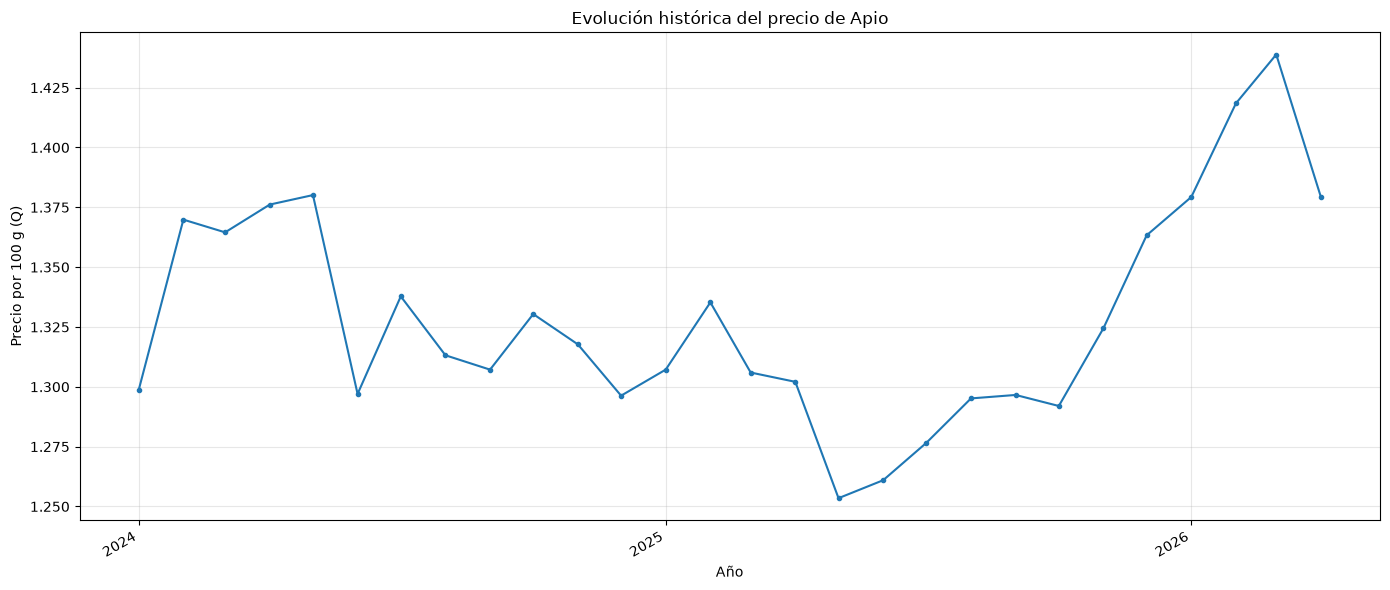

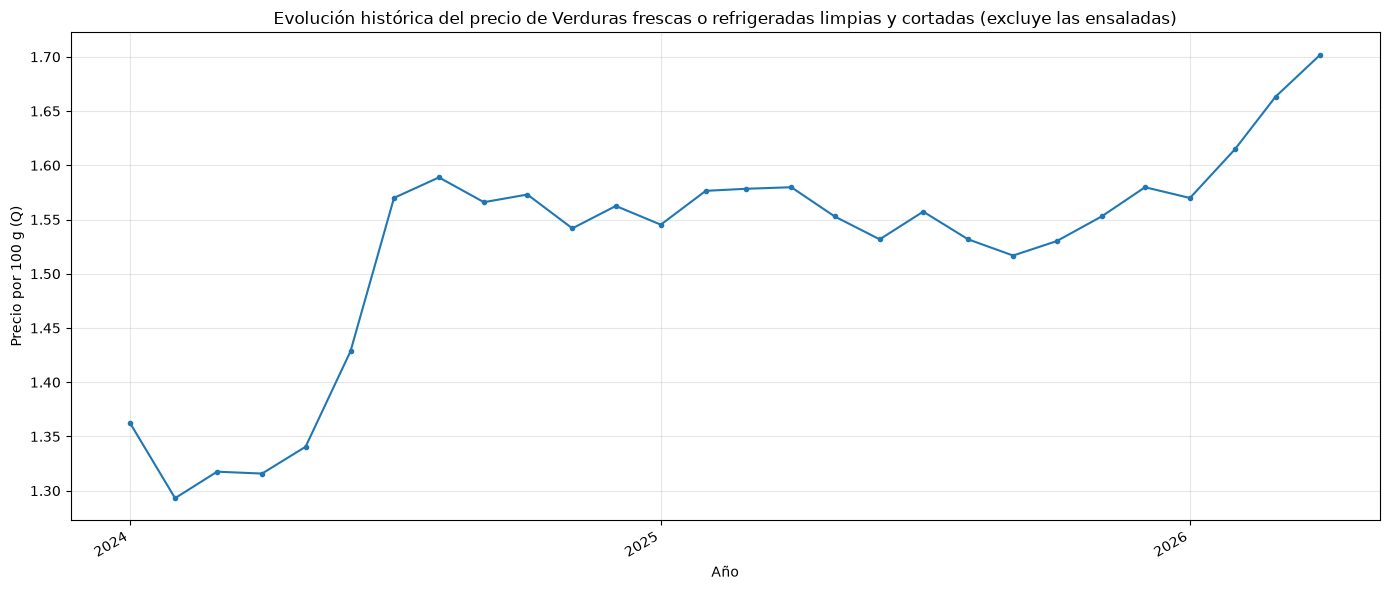

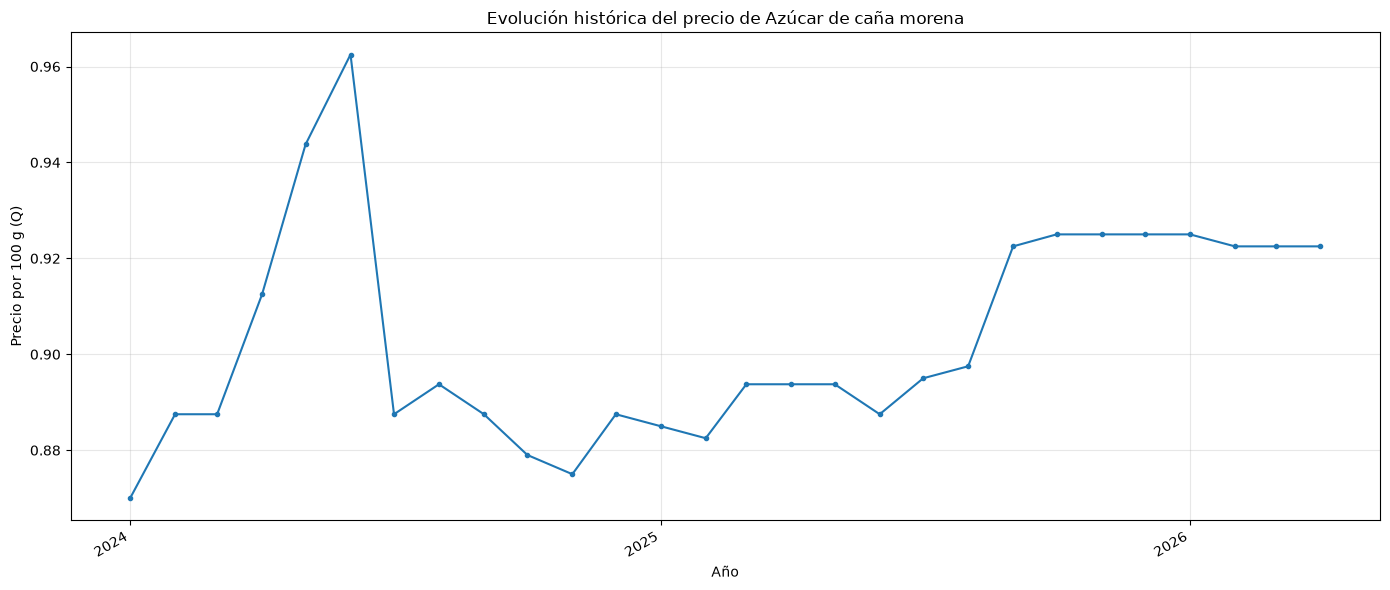

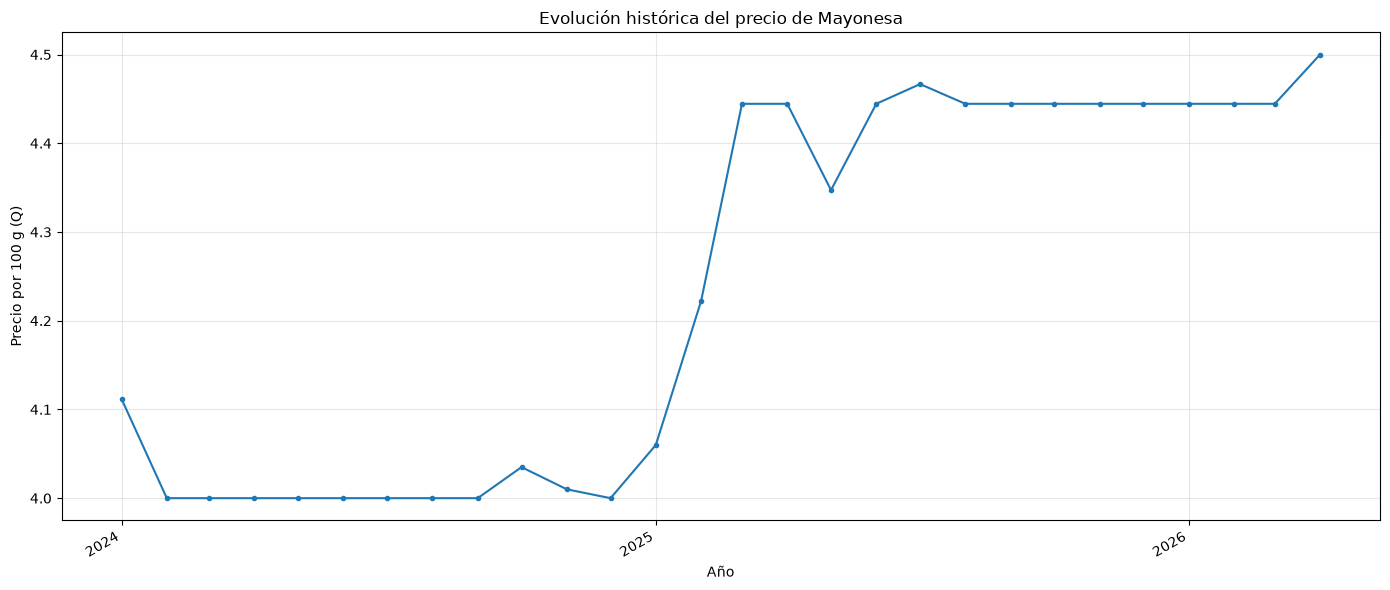

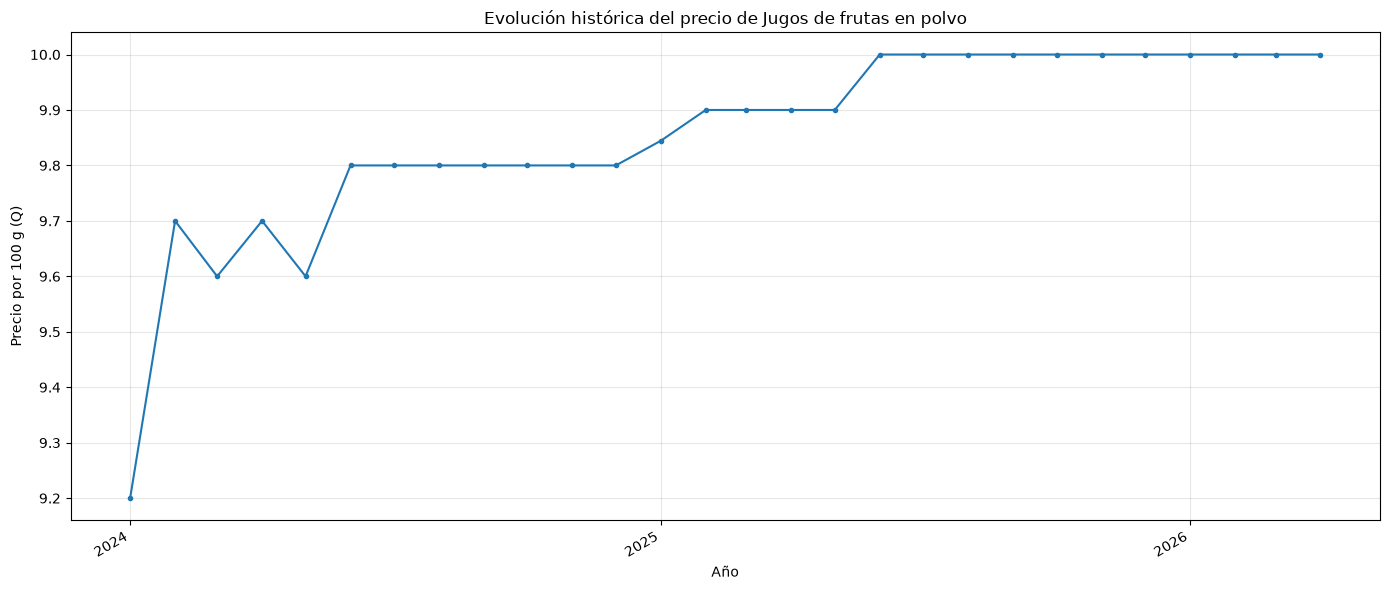

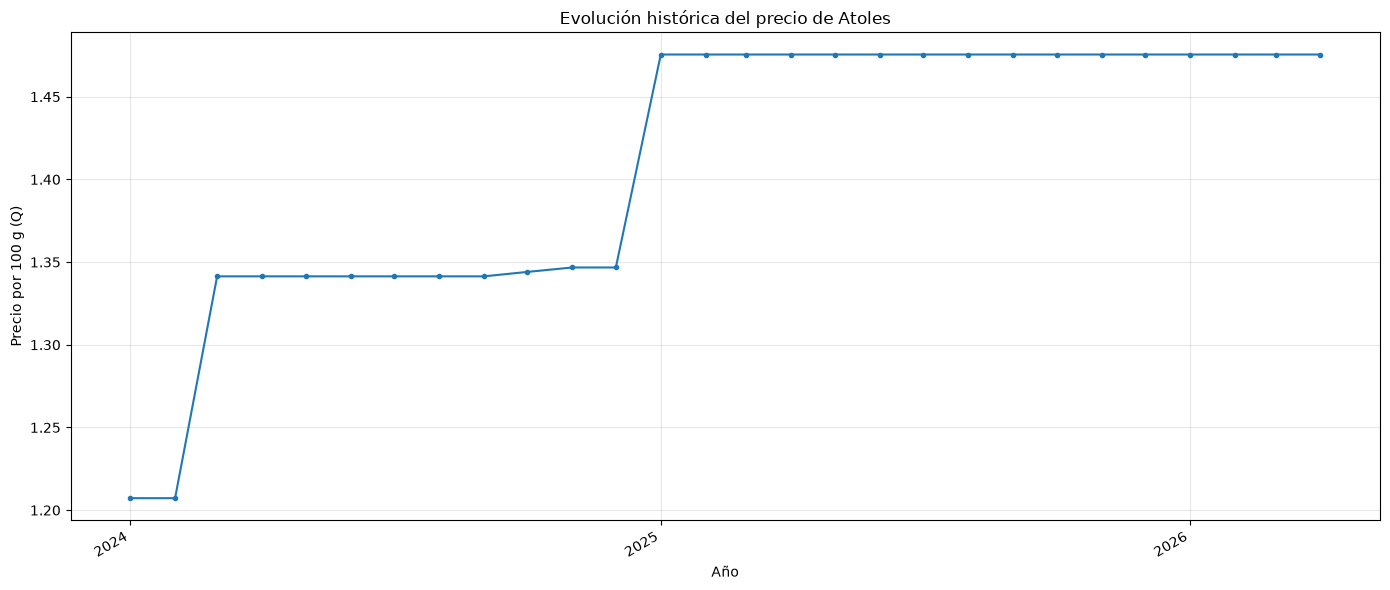

In [130]:
urban_only_foods = [
    'cereales_de_bolsa_o_caja',
    'carne_de_res_molida',
    'jamon_pollo_res_cerdo_mixto_etc',
    'papayas_frescas',
    'lechuga_achicoria_y_rugula_fresca_o_refrigerada',
    'apio',
    'verduras_frescas_o_refrigeradas_limpias_y_cortadas_excluye_las_ensaladas',
    'azucar_de_cana_morena',
    'mayonesa',
    'jugos_de_frutas_en_polvo',
    'atoles',
]
review_remaining_foods(urban_only_foods)

#### Conclusión

No se propone ningún merge adicional para estos alimentos. Las similitudes parciales de nombre no compensan las diferencias de presentación, procesamiento, cobertura regional o coexistencia dentro del mismo periodo.

In [134]:
catalog.merge_foods('arroz', 'arroz_corriente')
catalog.merge_foods('avena_de_toda_clase', 'avena_mosh')
catalog.merge_foods('fideos', 'pastas_alimenticias')
catalog.merge_foods('fideos', 'pastas_de_todos_los_tipos')
catalog.merge_foods('fideos', 'fideos_en_todas_sus_formas_excepto_macarrones_y_espagueti')
catalog.merge_foods('tortillas_de_maiz', 'tortillas_frescas')
catalog.merge_foods('carne_de_res_con_hueso', 'carne_de_res_con_hueso_para_cocido')
catalog.merge_foods('carne_de_cerdo_sin_hueso', 'posta_de_cerdo_sin_hueso')
catalog.merge_foods('carne_de_pollo_o_gallina', 'carne_de_pollo_blanco')
catalog.merge_foods('leche_liquida', 'leche_entera_liquida_industrializada')
catalog.merge_foods('embutidos', 'salchichas_y_productos_similares_de_carne')
catalog.merge_foods('queso_fresco_o_duro', 'queso_fresco_incluye_el_queso_supercremoso')
catalog.merge_foods('crema_fresca', 'crema_artesanal')
catalog.merge_foods('aceites_comestibles', 'aceite_vegetal_mixtos')
catalog.merge_foods('aguacates', 'aguacates_frescos')
catalog.merge_foods('bananos_guineos', 'bananos_frescos')
catalog.merge_foods('platanos', 'platanos_frescos')
catalog.merge_foods('tomate', 'tomate_fresco')
catalog.merge_foods('cebolla_blanca_sin_tallo', 'cebollas')
catalog.merge_foods('hierbas', 'macuy_hierba_mora_quilete')
catalog.merge_foods('frijol', 'frijoles_negros_secos')
catalog.merge_foods('azucar', 'azucar_de_cana_blanca')
catalog.merge_foods('incaparina', 'preparacion_nutricional_a_base_de_maiz_y_soya')

Food(id='incaparina', name='INCAPARINA', category='MISCELÁNEA', aliases={'Preparación nutricional a base de maíz y soya', 'INCAPARINA', 'PREPARACION NUTRICIONAL A BASE DE MAÍZ Y SOYA'}, price_timelines={'general': <canasta_inteligente.domain.prices.PriceTimeline object at 0x0000026F9B662270>}, nutrition=None, nutrition_match_score=None, nutrition_match_methods=())

In [135]:
len(catalog)

79

# 3. Merge con INCAP

In [132]:
""" incap_report = enrich_catalog_with_incap(
    catalog,
    PROJECT_ROOT / 'data' / 'raw' / 'incap' / 'tabladecomposiciondealimentos.pdf',
)
incap_report """

" incap_report = enrich_catalog_with_incap(\n    catalog,\n    PROJECT_ROOT / 'data' / 'raw' / 'incap' / 'tabladecomposiciondealimentos.pdf',\n)\nincap_report "

In [133]:
"""matched_foods = [food for food in catalog if food.nutrition is not None]
[(food.name, food.nutrition.incap_name, food.nutrition_match_score) for food in matched_foods[:10]]"""

'matched_foods = [food for food in catalog if food.nutrition is not None]\n[(food.name, food.nutrition.incap_name, food.nutrition_match_score) for food in matched_foods[:10]]'